In [3]:
import pandas as pd
import numpy as np
import time
# import shap
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

## loading data

In [4]:
CONS_PATH = "/uss/hdsi-prismdata/q2-ucsd-consDF.pqt"
ACCT_PATH = "/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt"
TRXN_PATH = "/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt"
CATMAP_PATH = "/uss/hdsi-prismdata/q2-ucsd-cat-map.csv"

In [5]:
# Load data
consdf = pd.read_parquet(CONS_PATH)
consdf_full = pd.read_parquet(CONS_PATH)
acctdf = pd.read_parquet(ACCT_PATH)
trxndf = pd.read_parquet(TRXN_PATH)
cat_map = pd.read_csv(CATMAP_PATH)

print("consdf:", consdf.shape)
print("acctdf:", acctdf.shape)
print("trxndf:", trxndf.shape)
print("cat_map:", cat_map.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/uss/hdsi-prismdata/q2-ucsd-consDF.pqt'

In [6]:
consdf

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14995,14995,2022-03-08,655.0,NaN
14996,14996,2022-01-15,625.0,NaN
14997,14997,2022-01-31,688.0,NaN
14998,14998,2022-03-08,722.0,NaN


In [7]:
acctdf

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90
...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24464,12210,24464,CHECKING,2022-03-28,2701.51


In [8]:
trxndf

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,3023,0,4,0.05,CREDIT,2021-04-16
1,3023,1,12,481.56,CREDIT,2021-04-30
2,3023,2,4,0.05,CREDIT,2021-05-16
3,3023,3,4,0.07,CREDIT,2021-06-16
4,3023,4,4,0.06,CREDIT,2021-07-16
...,...,...,...,...,...,...
6407316,10533,6405304,31,4.96,DEBIT,2022-03-11
6407317,10533,6405305,12,63.48,DEBIT,2022-03-30
6407318,10533,6405306,12,53.99,DEBIT,2022-03-30
6407319,10533,6405307,12,175.98,DEBIT,2022-03-31


## data cleaning/prepping

In [9]:
consdf = consdf.copy()
consdf["evaluation_date"] = pd.to_datetime(consdf["evaluation_date"], errors="coerce")

# # drop missing DQ_TARGET
# consdf = consdf[consdf["DQ_TARGET"].notna()].copy()
# consdf["DQ_TARGET"] = consdf["DQ_TARGET"].astype(int)

acctdf = acctdf.copy()
acctdf["balance_date"] = pd.to_datetime(acctdf["balance_date"], errors="coerce")

trxndf = trxndf.copy()
trxndf["posted_date"] = pd.to_datetime(trxndf["posted_date"], errors="coerce")

# Deduplicate transactions (use this whenever you build transaction features)
trxndf = (
    trxndf.sort_values(["posted_date"])
      .drop_duplicates(subset=["prism_transaction_id"], keep="first")
)


## scoring exclusions

In [10]:
# Accounts: how many accounts + how many balance snapshots
acct_stats = (
    acctdf.groupby("prism_consumer_id")
    .agg(
        n_accounts=("prism_account_id", "nunique"),
        n_balance_days=("balance_date", "nunique"),
        first_balance=("balance_date", "min"),
        last_balance=("balance_date", "max"),
    )
    .reset_index()
)

# Transactions: count + span + credits
tx_stats = (
    trxndf.groupby("prism_consumer_id")
    .agg(
        n_txn=("prism_transaction_id", "count"),
        first_txn=("posted_date", "min"),
        last_txn=("posted_date", "max"),
    )
    .reset_index()
)
tx_stats["txn_span_days"] = (tx_stats["last_txn"] - tx_stats["first_txn"]).dt.days

credit_stats = (
    trxndf.assign(is_credit=(trxndf["credit_or_debit"] == "CREDIT").astype(int))
    .groupby("prism_consumer_id")
    .agg(n_credit=("is_credit", "sum"))
    .reset_index()
)
credit_debit_counts = (
    trxndf.groupby(["prism_consumer_id", "credit_or_debit"])
          .size()
          .unstack(fill_value=0)   # creates CREDIT and DEBIT columns
          .reset_index()
)

# rename to match your naming convention
credit_debit_counts = credit_debit_counts.rename(columns={
    "CREDIT": "n_credit_txn",
    "DEBIT": "n_debit_txn"
})

# Combine into one scoring table (one row per consumer)
scoring = (
    consdf[["prism_consumer_id", "evaluation_date", "DQ_TARGET", "credit_score"]]
    .merge(acct_stats, on="prism_consumer_id", how="left")
    .merge(tx_stats, on="prism_consumer_id", how="left")
    .merge(credit_stats, on="prism_consumer_id", how="left")
    .merge(credit_debit_counts,on="prism_consumer_id",how="left")
)

# Fill missing stats with 0 where appropriate
for col in ["n_accounts", "n_balance_days", "n_txn", "txn_span_days", "n_credit"]:
    if col in scoring.columns:
        scoring[col] = scoring[col].fillna(0)


In [11]:
# consumers with no accounts
consumers_with_accounts = set(acctdf["prism_consumer_id"].unique())
all_consumers = set(consdf["prism_consumer_id"].unique())

no_account_ids = list(all_consumers - consumers_with_accounts)

print("Total consumers:", len(all_consumers))
print("Consumers with NO accounts:", len(no_account_ids))

Total consumers: 15000
Consumers with NO accounts: 1991


In [12]:
# checking to see how many "no accounts" have transactions
trx_no_account = trxndf[trxndf["prism_consumer_id"].isin(no_account_ids)]

consumers_no_account_with_txn = trx_no_account["prism_consumer_id"].nunique()

print("\nConsumers with NO accounts but WITH transactions:", consumers_no_account_with_txn)


# 3️⃣ Total transaction rows for these consumers
print("Total transaction rows for these consumers:", trx_no_account.shape[0])


# 4️⃣ Show example consumer IDs
print("\nExample consumer IDs (no account but with transactions):")
print(list(trx_no_account["prism_consumer_id"].unique())[:5])


# 5️⃣ Show sample transaction rows
print("\nSample transaction rows:")
display(trx_no_account.head(10))


Consumers with NO accounts but WITH transactions: 1845
Total transaction rows for these consumers: 1204382

Example consumer IDs (no account but with transactions):
['1706', '3327', '2042', '1970', '114']

Sample transaction rows:


,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
858236,1706,857660,0,2000.00,DEBIT,2020-11-01
895947,3327,895260,0,300.00,CREDIT,2020-11-01
895953,3327,895266,0,200.00,DEBIT,2020-11-02
895954,3327,895267,0,100.00,DEBIT,2020-11-06
728042,2042,727489,2,500.00,CREDIT,2020-11-12
858237,1706,857661,1,5000.00,DEBIT,2020-11-12
728043,2042,727490,4,25.00,CREDIT,2020-11-18
728044,2042,727491,2,500.00,CREDIT,2020-11-18
728045,2042,727492,4,475.00,CREDIT,2020-11-19
88530,1970,88466,4,0.05,CREDIT,2020-11-20


In [16]:
scoring["n_txn"].describe()


count    15000.000000
mean       427.020600
std        397.534424
min          0.000000
25%        154.000000
50%        337.000000
75%        589.000000
max       8478.000000
Name: n_txn, dtype: float64

In [17]:
scoring["txn_span_days"].describe()


count    15000.000000
mean       152.998600
std         78.290821
min          0.000000
25%         88.000000
50%        178.000000
75%        242.000000
max        801.000000
Name: txn_span_days, dtype: float64

even the low activity consumers have 88 days (2-3 months) of transaction history

In [18]:
scoring["n_credit"].describe()


count    15000.000000
mean        73.636733
std         80.685765
min          0.000000
25%         28.000000
50%         52.000000
75%         93.000000
max       1553.000000
Name: n_credit, dtype: float64

bottom 25% has 28 credit transactions

In [19]:
RULES = {

    # No financial footprint at all
    "no_accounts": scoring["n_accounts"] < 1,

    # No transaction history
    "no_transactions": scoring["n_txn"] < 1,

    # Must have at least 1 credit and 1 debit
    "no_credit_txn": scoring["n_credit_txn"] < 1,
    "no_debit_txn": scoring["n_debit_txn"] < 1,

    # Too short of observable history
    "short_txn_history": scoring["txn_span_days"] < 30,
}

# Apply rules
for name, mask in RULES.items():
    scoring[name] = mask

# Exclusion flag
scoring["excluded"] = scoring[list(RULES.keys())].any(axis=1)

# Summary
print("Total consumers:", scoring.shape[0])
print("Excluded:", scoring["excluded"].sum())
print("Eligible:", (~scoring["excluded"]).sum())
print("Exclusion rate:", scoring["excluded"].mean())


Total consumers: 15000
Excluded: 3004
Eligible: 11996
Exclusion rate: 0.20026666666666668


In [20]:
eligible_ids = scoring.loc[~scoring["excluded"], "prism_consumer_id"]

print("Eligible consumers:", len(eligible_ids))


Eligible consumers: 11996


In [21]:
consdf_eligible = consdf[
    consdf["prism_consumer_id"].isin(eligible_ids)
].copy()

acctdf_eligible = acctdf[
    acctdf["prism_consumer_id"].isin(eligible_ids)
].copy()

trxndf_eligible = trxndf[
    trxndf["prism_consumer_id"].isin(eligible_ids)
].copy()


In [22]:
print("Consumers in consdf_eligible:", consdf_eligible["prism_consumer_id"].nunique())
print("Consumers in acctdf_eligible:", acctdf_eligible["prism_consumer_id"].nunique())
print("Consumers in trxndf_eligible:", trxndf_eligible["prism_consumer_id"].nunique())


Consumers in consdf_eligible: 11996
Consumers in acctdf_eligible: 11996
Consumers in trxndf_eligible: 11996


In [23]:
holdout_ids = consdf_full.loc[
    consdf_full["DQ_TARGET"].isna(),
    "prism_consumer_id"
]

In [24]:
scoring_holdout = scoring[
    scoring["prism_consumer_id"].isin(holdout_ids)
].copy()

In [25]:
print("Holdout consumers:", scoring_holdout.shape[0])
print("Excluded in holdout:", scoring_holdout["excluded"].sum())
print("Eligible in holdout:", (~scoring_holdout["excluded"]).sum())
print("Holdout exclusion rate:",
      round(scoring_holdout["excluded"].mean(), 4))

Holdout consumers: 3000
Excluded in holdout: 626
Eligible in holdout: 2374
Holdout exclusion rate: 0.2087


## feature engineering

In [26]:
initial_df = (
    acctdf
    .merge(consdf, on='prism_consumer_id', how='inner')
    .groupby(['prism_consumer_id'])
    .agg(
        balance=('balance', 'sum'),
        balance_date=('balance_date', 'max')
    )
    .reset_index()
).merge(trxndf,on='prism_consumer_id')

In [27]:
mapping = dict(zip(cat_map["category_id"], cat_map["category"]))
initial_df["category"] = initial_df["category"].replace(mapping)
monthly_summary=initial_df.copy()
monthly_summary['amount'] = np.where(initial_df['credit_or_debit'] == 'DEBIT', -initial_df['amount'],initial_df['amount'])
monthly_summary['posted_date'] = pd.to_datetime(monthly_summary['posted_date'])
monthly_summary = (
    monthly_summary
    .groupby(['prism_consumer_id', monthly_summary['posted_date'].dt.to_period('M')])
    .agg(
        starting_balance=('balance', 'first'),
        monthly_total=('balance', 'sum'),
        trxndf_count = ('balance', 'count')
    )
    .reset_index()
)
monthly_summary['posted_date'] = monthly_summary['posted_date'].dt.to_timestamp()

In [28]:
monthly_summary = monthly_summary.merge(consdf[['prism_consumer_id','DQ_TARGET']],on='prism_consumer_id').dropna()


In [29]:
# ensure date type
monthly_summary["posted_date"] = pd.to_datetime(monthly_summary["posted_date"])

# sort properly
monthly_summary = monthly_summary.sort_values(["prism_consumer_id", "posted_date"])

# calculate running balance
monthly_summary["monthly_balance"] = (
    monthly_summary["starting_balance"]
    + monthly_summary.groupby("prism_consumer_id")["monthly_total"].cumsum()
)

In [30]:
del_df = monthly_summary[monthly_summary['DQ_TARGET'] == 1]
nondel_df = monthly_summary[monthly_summary['DQ_TARGET'] == 0]
ids_1 = del_df["prism_consumer_id"].dropna().unique()
ids_0 = del_df["prism_consumer_id"].dropna().unique()

In [31]:
mtotal_df = monthly_summary.groupby('prism_consumer_id').agg(
        DQ_TARGET = ('DQ_TARGET', 'first'),
        monthly_mean=('monthly_total', 'mean'),
        monthly_max=('monthly_total', 'max'),
        monthly_min=('monthly_total', 'min'),
        trxndf_count = ('trxndf_count','first'),
        month_count=('monthly_total', 'count')
    )

In [32]:
cd_df = initial_df[['prism_consumer_id','amount','credit_or_debit']].groupby(['prism_consumer_id','credit_or_debit']).sum().reset_index()


In [33]:
cd_df = (
    cd_df
    .pivot_table(
        index='prism_consumer_id',
        columns='credit_or_debit',
        values='amount',
        aggfunc='sum',
        fill_value=0
    )
    .assign(
        credit_debit_ratio=lambda x: x['CREDIT'] / (x['DEBIT'] + 1),
        net_flow=lambda x: x['CREDIT'] - x['DEBIT']
    )
)

In [34]:
cd_df = cd_df.reset_index().merge(consdf[['prism_consumer_id','DQ_TARGET']],on='prism_consumer_id').dropna()


In [35]:
net_df = initial_df[['prism_consumer_id','posted_date','category','credit_or_debit','amount']].copy()
net_df['amount'] = np.where(net_df['credit_or_debit'] == 'DEBIT', -net_df['amount'],net_df['amount'])
net_df['posted_date'] = pd.to_datetime(net_df['posted_date'])
net_df['month'] = net_df['posted_date'].dt.to_period('M')
mn_df = net_df.groupby(['prism_consumer_id','month']).agg(
        monthly_total=('amount', 'sum'),
        monthly_std =('amount','std')
    ).reset_index()


monthly features

In [36]:
monthly_features = mn_df.groupby(['prism_consumer_id']).agg(
    monthly_net_total=('monthly_total', 'sum'),
    monthly_net_avg=('monthly_total', 'mean'),
    monthly_net_max=('monthly_total', 'max'),
    monthly_net_min=('monthly_total', 'min'),
    monthly_std_avg=('monthly_std', 'mean')
).reset_index().merge(consdf[['prism_consumer_id','DQ_TARGET']],on='prism_consumer_id').dropna()
monthly_features['prism_consumer_id'] = monthly_features['prism_consumer_id'].astype(int)
mtotal_df = mtotal_df.reset_index()
mtotal_df['prism_consumer_id'] = mtotal_df['prism_consumer_id'].astype(int)
cd_df['prism_consumer_id'] = cd_df['prism_consumer_id'].astype(int)
monthly_features['net_range'] = monthly_features['monthly_net_max'] - monthly_features['monthly_net_min']

In [37]:
initial_df['amount'] = np.where(initial_df['credit_or_debit'] == 'DEBIT', -initial_df['amount'],initial_df['amount'])
cat_df = initial_df.groupby(['prism_consumer_id','category'])['amount'].sum().reset_index()

In [38]:
cat_pivot = (
    cat_df
    .pivot(
        index='prism_consumer_id',
        columns='category',
        values='amount'
    )
    .fillna(0)
)

In [39]:
outflows = cat_pivot.clip(upper=0).abs()
inflows  = cat_pivot.clip(lower=0)

cat_features = pd.DataFrame(index=cat_pivot.index)

cat_features['total_outflows'] = outflows.sum(axis=1)
cat_features['total_inflows']  = inflows.sum(axis=1)
cat_features['net_flow']       = cat_pivot.sum(axis=1)

In [40]:
for col in outflows.columns:
    cat_features[f'{col}_outflow_ratio'] = (
        outflows[col] / (cat_features['total_outflows'] + 1))

In [41]:
# Income reliance
cat_features['paycheck_ratio'] = (
    inflows.get('PAYCHECK', 0) / (cat_features['total_inflows'] + 1)
)

# Cash usage
cat_features['atm_cash_ratio'] = (
    outflows.get('ATM_CASH', 0) / (cat_features['total_outflows'] + 1)
)

# Entertainment vs essentials proxy
cat_features['entertainment_ratio'] = (
    outflows.get('ENTERTAINMENT', 0) / (cat_features['total_outflows'] + 1)
)

# Refund dependence
cat_features['refund_ratio'] = (
    inflows.get('REFUND', 0) / (cat_features['total_inflows'] + 1)
)

In [42]:
outflows = outflows.reset_index().merge(consdf[['prism_consumer_id','DQ_TARGET']],on='prism_consumer_id').dropna()


In [43]:
cat_features = cat_features.reset_index().merge(consdf[['prism_consumer_id','DQ_TARGET']],on='prism_consumer_id').dropna()


In [44]:
add_df = cat_features[['prism_consumer_id','refund_ratio','paycheck_ratio']].copy()
add_df['prism_consumer_id'] = add_df['prism_consumer_id'].astype(int)
outflows['prism_consumer_id'] = outflows['prism_consumer_id'].astype(int)
out_df = outflows.copy()

In [45]:
initial_df['amount'] = np.where(initial_df['credit_or_debit'] == 'DEBIT', -initial_df['amount'],initial_df['amount'])
cat_df = initial_df.groupby(['prism_consumer_id','category'])['amount'].mean().reset_index()

In [46]:
cat_pivot = (
    cat_df
    .pivot(
        index='prism_consumer_id',
        columns='category',
        values='amount'
    )
    .fillna(0)
)
cat_pivot.columns = cat_pivot.columns + "_trxnavg"
cat_pivot = cat_pivot.reset_index().merge(consdf[['prism_consumer_id','DQ_TARGET']],on='prism_consumer_id').dropna()
cat_pivot['prism_consumer_id'] = cat_pivot['prism_consumer_id'].astype(int)

income

In [47]:
mapping = dict(zip(cat_map["category_id"], cat_map["category"]))
trxndf["category"] = trxndf["category"].replace(mapping)

income_categories = [
    'PAYCHECK',
    'DEPOSIT',
    'UNEMPLOYMENT_BENEFITS',
    'OTHER_BENEFITS',
    'PENSION',
    'INVESTMENT_INCOME'
]

income_df = trxndf[
    trxndf['category'].isin(income_categories)
].copy()
income_df['prism_transaction_id'].duplicated().sum()
income_df['posted_date'] = pd.to_datetime(income_df['posted_date'])

In [48]:
income_time = (
    income_df
    .groupby('prism_consumer_id')
    .agg(
        first_income_date=('posted_date', 'min'),
        last_income_date=('posted_date', 'max')
    )
    .reset_index()
)

income_time['income_span_days'] = (
    income_time['last_income_date'] - income_time['first_income_date']
).dt.days

In [49]:
income_df = income_time[['prism_consumer_id','income_span_days']]
income_df['prism_consumer_id'] = income_time['prism_consumer_id'].astype(int)

/tmp/ipykernel_3038/1562562249.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  income_df['prism_consumer_id'] = income_time['prism_consumer_id'].astype(int)


preliminary testing

In [50]:
cat_pivot= cat_pivot.drop(columns='DQ_TARGET')


In [51]:
main_df= monthly_features.merge(mtotal_df,on='prism_consumer_id')
main_df['DQ_TARGET'] = main_df['DQ_TARGET_x']
main_df = main_df.drop(columns=['DQ_TARGET_x','DQ_TARGET_y'])
cd_df = cd_df.drop(columns=['net_flow','DQ_TARGET'])
main_df= main_df.merge(cd_df,on='prism_consumer_id')
main_df= main_df.merge(add_df,on='prism_consumer_id')
main_df= main_df.merge(out_df,on='prism_consumer_id')
main_df= main_df.merge(income_df,on='prism_consumer_id')
main_df= main_df.merge(cat_pivot,on='prism_consumer_id')
main_df

,prism_consumer_id,monthly_net_total,monthly_net_avg,monthly_net_max,monthly_net_min,monthly_std_avg,net_range,monthly_mean,monthly_max,monthly_min,...,REFUND_trxnavg,RENT_trxnavg,RISK_CATCH_ALL_trxnavg,RTO_LTO_trxnavg,SELF_TRANSFER_trxnavg,TAX_trxnavg,TIME_OR_STUFF_trxnavg,TRANSPORATION_trxnavg,TRAVEL_trxnavg,UNEMPLOYMENT_BENEFITS_trxnavg
0,0,-521.59,-74.512857,830.73,-2584.24,213.544425,3414.97,1.867299e+04,27231.45,8970.36,...,19.960000,0.000000,0.0,0.0,116.685652,867.840,0.000000,2.480000,54.375000,0.0
1,1,1805.43,257.918571,1109.02,-940.73,292.763392,2049.75,1.481371e+05,208052.46,102375.02,...,2.420000,0.000000,0.0,0.0,233.410256,1162.700,0.000000,25.900000,0.000000,0.0
2,10,-1190.04,-170.005714,431.40,-971.45,260.603079,1402.85,4.015226e+04,60169.52,19781.76,...,18.466000,103.000000,0.0,0.0,237.568750,0.000,0.000000,17.520000,0.000000,0.0
3,100,-4505.77,-750.961667,1276.72,-3332.81,832.186871,4609.53,5.399456e+04,63731.28,45142.99,...,1.468750,0.000000,0.0,0.0,547.296667,0.000,0.000000,0.000000,0.000000,0.0
4,1000,438.08,62.582857,2982.67,-2884.56,1223.790895,5867.23,2.871107e+03,3524.25,476.25,...,1.370000,0.000000,0.0,0.0,828.920370,0.000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9589,995,21842.68,3120.382857,10212.74,-3244.20,1016.422674,13456.94,2.053630e+06,3162590.31,670852.49,...,1.463333,1134.158000,0.0,0.0,1250.937000,626.432,0.000000,0.000000,0.000000,0.0
9590,996,26713.18,3816.168571,41464.50,-16811.41,2623.765971,58275.91,0.000000e+00,0.00,0.00,...,2.944444,0.000000,0.0,0.0,3532.145542,0.000,0.000000,12.000000,493.909091,0.0
9591,997,-14899.66,-2128.522857,206.99,-3741.45,745.079512,3948.44,4.787867e+06,6756531.35,1404823.35,...,14.420000,0.000000,0.0,0.0,940.464154,2516.000,20.149683,0.000000,0.000000,0.0
9592,998,5507.73,786.818571,3359.83,-1022.35,537.836676,4382.18,7.987620e+05,1116887.94,275774.80,...,9.546429,231.316667,0.0,0.0,759.527885,2991.340,0.000000,12.700000,248.140000,0.0


In [52]:
# columns I will need: credit/debit, amount, posted date, evaluation date, prism consumer id, DQ_TARGET
merged = pd.merge(consdf.dropna(), trxndf, on='prism_consumer_id', how='left')

In [53]:
merged = merged[merged['posted_date'] <= merged['evaluation_date']]
credit_only = merged[merged['credit_or_debit'] == 'CREDIT'].copy()
credit_only['posted_date'] = pd.to_datetime(credit_only['posted_date'])
credit_only['Year-Month'] = credit_only['posted_date'].dt.to_period('M')
debt_only = trxndf[trxndf['credit_or_debit']=='DEBIT']
monthly_inflow = credit_only.groupby(['prism_consumer_id', 'Year-Month'])['amount'].sum().reset_index(name='monthly_inflow')
consdf['Evaluation Month'] = consdf['evaluation_date'].dt.to_period('M')
with_eval_month = pd.merge(consdf, monthly_inflow, on='prism_consumer_id', how='left')

In [54]:
with_eval_month['months_diff'] = (
    (with_eval_month['Evaluation Month'].dt.year - with_eval_month['Year-Month'].dt.year) * 12 +
    (with_eval_month['Evaluation Month'].dt.month - with_eval_month['Year-Month'].dt.month)
)
last_year = with_eval_month[(with_eval_month['months_diff'] >= 1) & (with_eval_month['months_diff'] <= 12)]
sum_yearly_inflow = last_year.groupby('prism_consumer_id')['monthly_inflow'].sum().reset_index(name='avg_yearly_inflow')
year_std = last_year.groupby('prism_consumer_id')['monthly_inflow'].std().reset_index()
year_std.columns = ['prism_consumer_id', 'std_inflow']

In [55]:
# Trend: Is income increasing or decreasing?
def calculate_trend(group):
    if len(group) < 2:
        return 0
    months = group['months_diff'].values
    inflows = group['monthly_inflow'].values
    return np.polyfit(months, inflows, 1)[0]  # slope

trend = last_year.groupby('prism_consumer_id').apply(calculate_trend, include_groups=False).reset_index()
trend.columns = ['prism_consumer_id', 'trend']
num_transactions = last_year.groupby('prism_consumer_id').size().reset_index()
num_transactions.columns = ['prism_consumer_id', 'num_transactions']

In [56]:
debt_only = trxndf[trxndf['credit_or_debit'] == 'DEBIT'].copy()
debt_only['posted_date'] = pd.to_datetime(debt_only['posted_date'])
# debt_only['category'] = debt_only['category'].astype(int)

# debt_with_category = pd.merge(debt_only, cat_map, left_on='category', right_on='category_id', how='left')[['prism_consumer_id',\
#     'prism_transaction_id', 'amount', 'credit_or_debit', 'posted_date', 'category_id', 'category_y']]
debt_with_category = debt_only.rename(columns={'category_y':'category'})
groceries_only = debt_with_category[debt_with_category['category']=='GROCERIES']

debt_with_eval = pd.merge(groceries_only, consdf[['prism_consumer_id', 'evaluation_date']], on='prism_consumer_id', how='left')

# Filter for transactions in the 3 months before evaluation_date
debt_with_eval['months_before_eval'] = (
    (debt_with_eval['evaluation_date'].dt.year - debt_with_eval['posted_date'].dt.year) * 12 +
    (debt_with_eval['evaluation_date'].dt.month - debt_with_eval['posted_date'].dt.month)
)

debt_9m = debt_with_eval[(debt_with_eval['months_before_eval'] >= 0) & 
                          (debt_with_eval['months_before_eval'] < 9)]

# total spend of groceries per consumer over a 9 month window (last 9 months before eval date)
total_spend_groceries_9m = debt_9m.groupby('prism_consumer_id')['amount'].sum().reset_index()
total_spend_groceries_9m.columns = ['prism_consumer_id', 'sum_groceries_9m']

In [57]:
# total spend of dining per consumer over a month window (last month before eval date)
dining_only = debt_with_category[debt_with_category['category']=='FOOD_AND_BEVERAGES']

debt_with_eval_dining = pd.merge(dining_only, consdf[['prism_consumer_id', 'evaluation_date']], on='prism_consumer_id', how='left')

# Filter for transactions in the 6 months before evaluation_date
debt_with_eval_dining['months_before_eval'] = (
    (debt_with_eval_dining['evaluation_date'].dt.year - debt_with_eval_dining['posted_date'].dt.year) * 12 +
    (debt_with_eval_dining['evaluation_date'].dt.month - debt_with_eval_dining['posted_date'].dt.month)
)

debt_6m = debt_with_eval_dining[(debt_with_eval_dining['months_before_eval'] >= 0) & 
                          (debt_with_eval_dining['months_before_eval'] < 6)]

# total spend of groceries per consumer over a 6 month window (last 6 months before eval date)
total_spend_dining_6m = debt_6m.groupby('prism_consumer_id')['amount'].sum().reset_index()
total_spend_dining_6m.columns = ['prism_consumer_id', 'sum_dining_6m']

In [58]:
# merge evaluation date ONCE
tx = debt_with_category.merge(
    consdf[['prism_consumer_id', 'evaluation_date']],
    on='prism_consumer_id',
    how='left'
)

tx = tx[tx['credit_or_debit'] == 'DEBIT']
tx['amount'] = tx['amount'].abs()

# numerator
total_spend_gambling = tx[tx['category'] == 'GAMBLING'].groupby('prism_consumer_id')['amount'].sum()

# denominator
total_spend_all = tx.groupby('prism_consumer_id')['amount'].sum()

pct_spend_gambling = (total_spend_gambling / total_spend_all).fillna(0).reset_index(name='pct_spend_gambling')

In [59]:
essentials = ['RENT', 'MORTGAGE', 'BILLS_UTILITIES', 'ESSENTIAL_SERVICES', 'GROCERIES', 'AUTOMOTIVE', 'TRANSPORTATION', \
'HEALTHCARE_MEDICAL', 'INSURANCE', 'CHILD_DEPENDENTS', 'PETS', 'TAX', 'LOAN', 'AUTO_LOAN', 'DEBT', 'CREDIT_CARD_PAYMENT', \
'EDUCATION', 'LEGAL', 'GOVERNMENT_SERVICES']

total_spend_essentials = tx[tx['category'].isin(essentials)].groupby('prism_consumer_id')['amount'].sum()

pct_spend_essentials = (total_spend_essentials / total_spend_all).reset_index()

pct_spend_essentials = pct_spend_essentials.rename(columns={'amount':'pct_spend_essentials'})

In [60]:
# # change in groceries per consumer from the 3 most recent months to the prior 3-6 months before evaluation date
# lowers AUC from 0.721 to 0.71

# recent 3 months (0–2)
recent_3m = debt_with_eval[(debt_with_eval['months_before_eval'] >= 0) & (debt_with_eval['months_before_eval'] < 3)]

recent_spend = recent_3m.groupby('prism_consumer_id')['amount'].sum().reset_index(name='groceries_0_3m')

# prior 3 months (3–5)
prior_3m = debt_with_eval[(debt_with_eval['months_before_eval'] >= 3) & (debt_with_eval['months_before_eval'] < 6)]

prior_spend = prior_3m.groupby('prism_consumer_id')['amount'].sum().reset_index(name='groceries_3_6m')

# merge and compute delta
delta_groceries_3m = recent_spend.merge(
    prior_spend,
    on='prism_consumer_id',
    how='outer'
).fillna(0)

delta_groceries_3m['delta_groceries_3m'] = delta_groceries_3m['groceries_0_3m'] - delta_groceries_3m['groceries_3_6m']

delta_groceries_3m = delta_groceries_3m[['prism_consumer_id', 'delta_groceries_3m']]

utilities = ['BILLS_UTILITIES', 'ESSENTIAL_SERVICES']

total_spend_utilities = tx[tx['category'].isin(utilities)].groupby('prism_consumer_id')['amount'].sum()

pct_spend_utilities = (total_spend_utilities / total_spend_all).reset_index()

pct_spend_utilities = pct_spend_utilities.rename(columns={'amount':'pct_spend_utilities'})

In [61]:
# has overdraft - 6 months
# Merge evaluation dates with ALL debt transactions
debt_with_eval = pd.merge(
    debt_with_category, 
    consdf[['prism_consumer_id', 'evaluation_date']], 
    on='prism_consumer_id', 
    how='left'
)

# Calculate days before evaluation
debt_with_eval['days_before_eval'] = (
    debt_with_eval['evaluation_date'] - debt_with_eval['posted_date']
).dt.days

# Filter for OVERDRAFT category AND within 6 months
overdraft_6m = debt_with_eval[
    (debt_with_eval['category'] == 'OVERDRAFT') &
    (debt_with_eval['days_before_eval'] >= 0) & 
    (debt_with_eval['days_before_eval'] <= 180)
]

# Group to get consumers with overdrafts
has_overdraft_6m = overdraft_6m.groupby('prism_consumer_id').size().reset_index(name='overdraft_count')
has_overdraft_6m['has_overdraft_6m'] = 1

has_overdraft_6m = has_overdraft_6m[['prism_consumer_id', 'has_overdraft_6m']]

In [62]:
# has account fees - 6 months
# Merge evaluation dates with ALL debt transactions
debt_with_eval = pd.merge(
    debt_with_category, 
    consdf[['prism_consumer_id', 'evaluation_date']], 
    on='prism_consumer_id', 
    how='left'
)

# Calculate days before evaluation
debt_with_eval['days_before_eval'] = (
    debt_with_eval['evaluation_date'] - debt_with_eval['posted_date']
).dt.days

# Filter for ACCOUNT FEES category AND within 6 months
acct_fees_6m = debt_with_eval[
    (debt_with_eval['category'] == 'ACCOUNT_FEES') &
    (debt_with_eval['days_before_eval'] >= 0) & 
    (debt_with_eval['days_before_eval'] <= 180)
]

# Group to get consumers with acct fee
has_acct_fee_6m = acct_fees_6m.groupby('prism_consumer_id').size().reset_index(name='acct_fees_count')
has_acct_fee_6m['has_acct_fee_6m'] = 1

has_acct_fee_6m = has_acct_fee_6m[['prism_consumer_id', 'has_acct_fee_6m']]

In [63]:
#atm cash ratio per consumer

debt_with_eval = pd.merge(
    debt_with_category,
    consdf[['prism_consumer_id', 'evaluation_date']],
    on='prism_consumer_id',
    how='left'
)

debt_with_eval['posted_date'] = pd.to_datetime(debt_with_eval['posted_date'])
debt_with_eval['evaluation_date'] = pd.to_datetime(debt_with_eval['evaluation_date'])

debt_with_eval = debt_with_eval[
    debt_with_eval['posted_date'] <= debt_with_eval['evaluation_date']
]

total_debt_spend = debt_with_eval.groupby('prism_consumer_id')['amount'].sum().reset_index(name='total_debit_spend')

In [64]:
atm_cash_spend = (
    debt_with_eval[debt_with_eval['category'] == 'ATM_CASH']
    .groupby('prism_consumer_id')['amount']
    .sum()
    .reset_index(name='atm_cash_spend')
)

atm_cash_ratio = total_debt_spend.merge(atm_cash_spend, on='prism_consumer_id',how='left').fillna(0)
atm_cash_ratio['atm_cash_ratio'] = atm_cash_ratio['atm_cash_spend'] / atm_cash_ratio['total_debit_spend']
atm_cash_ratio['atm_cash_ratio'] = (
    atm_cash_ratio['atm_cash_ratio']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)


In [65]:
# Merge evaluation dates with ALL debt transactions
debt_with_eval = pd.merge(
    debt_with_category, 
    consdf[['prism_consumer_id', 'evaluation_date']], 
    on='prism_consumer_id', 
    how='left'
)

# Calculate days before evaluation
debt_with_eval['days_before_eval'] = (
    debt_with_eval['evaluation_date'] - debt_with_eval['posted_date']
).dt.days

atm_cash_freq_6m = acct_fees_6m.groupby('prism_consumer_id').size().reset_index(name='atm_cash_freq_6m')

In [66]:
# refund ratio
credit_only = trxndf[trxndf['credit_or_debit']=='CREDIT']
# merged_credit = pd.merge(credit_only, cat_map, left_on='category', right_on='category_id', how='left')[['prism_consumer_id', 'prism_transaction_id', 'amount', \
# 'credit_or_debit', 'posted_date', 'category_id', 'category_y']]
merged_credit = credit_only.rename(columns={'category_y': 'category'})

credit_with_eval = pd.merge(
    merged_credit,
    consdf[['prism_consumer_id', 'evaluation_date']],
    on='prism_consumer_id',
    how='left'
)

credit_with_eval['posted_date'] = pd.to_datetime(credit_with_eval['posted_date'])
credit_with_eval['evaluation_date'] = pd.to_datetime(credit_with_eval['evaluation_date'])

credit_with_eval['days_before_eval'] = (credit_with_eval['evaluation_date'] - credit_with_eval['posted_date']).dt.days
window = credit_with_eval[(credit_with_eval['days_before_eval'] >= 0) & (credit_with_eval['days_before_eval'] <= 180)]

refund = window[window['category']=='REFUND'].groupby('prism_consumer_id')['amount'].sum().reset_index(name='refund_amount')

In [67]:
debit_only = trxndf[trxndf['credit_or_debit'] == 'DEBIT']
# merged_debit = pd.merge(
#     debit_only,
#     cat_map,
#     left_on='category',
#     right_on='category_id',
#     how='left'
# )[[
#     'prism_consumer_id',
#     'prism_transaction_id',
#     'amount',
#     'credit_or_debit',
#     'posted_date',
#     'category_id',
#     'category_y'
# ]]

merged_debit = debit_only.rename(columns={'category_y': 'category'})
debit_with_eval = pd.merge(
    merged_debit,
    consdf[['prism_consumer_id', 'evaluation_date']],
    on='prism_consumer_id',
    how='left'
)

debit_with_eval['posted_date'] = pd.to_datetime(debit_with_eval['posted_date'])
debit_with_eval['evaluation_date'] = pd.to_datetime(debit_with_eval['evaluation_date'])

debit_with_eval['days_before_eval'] = (
    debit_with_eval['evaluation_date'] - debit_with_eval['posted_date']
).dt.days

debit_window = debit_with_eval[
    (debit_with_eval['days_before_eval'] >= 0) &
    (debit_with_eval['days_before_eval'] <= 180)
]

debit_spend = debit_window[
    debit_window['category'] != 'REFUND'
]
denominator = (
    debit_spend
    .groupby('prism_consumer_id')['amount']
    .sum()
    .reset_index(name='total_debit_spend')
)


In [68]:
refund_ratio = denominator.merge(
    refund,
    on='prism_consumer_id',
    how='left'
).fillna(0)

refund_ratio['refund_ratio'] = (
    refund_ratio['refund_amount'] /
    refund_ratio['total_debit_spend']
)

refund_ratio['refund_ratio'] = (
    refund_ratio['refund_ratio']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)
refund_ratio = refund_ratio[['prism_consumer_id', 'refund_ratio']]

In [69]:
# debt_payment_ratio
# (LOAN + CREDIT_CARD_PAYMENT + AUTO_LOAN + BNPL) / total_debit_spend
categories_of_interest = ['LOAN', 'CREDIT_CARD_PAYMENT', 'AUTO_LOAN', 'BNPL']

summary = (
    debit_with_eval
    .groupby('prism_consumer_id')
    .agg(
        total_debit_spend=('amount', 'sum'),
        debt_spend=('amount', lambda x: x[
            debit_with_eval.loc[x.index, 'category'].isin(categories_of_interest)
        ].sum())
    )
    .reset_index()
)

summary['debt_spend_ratio'] = summary['debt_spend'] / summary['total_debit_spend']

In [70]:
# bnpl usage flag
# Filter for BNPL category AND within 6 months
bnpl_usage_6m = debt_with_eval[
    (debt_with_eval['category'] == 'BNPL') &
    (debt_with_eval['days_before_eval'] >= 0) & 
    (debt_with_eval['days_before_eval'] <= 180)
]

# Group to get consumers with acct fee
has_bnpl_usage_6m = bnpl_usage_6m.groupby('prism_consumer_id').size().reset_index(name='bnpl_usage_flag')
has_bnpl_usage_6m['bnpl_usage_flag'] = 1

has_bnpl_usage_6m = has_bnpl_usage_6m[['prism_consumer_id', 'bnpl_usage_flag']]

In [71]:
debt_categories = ['LOAN', 'CREDIT_CARD_PAYMENT', 'AUTO_LOAN', 'BNPL']

debt_category_count = (
    debit_with_eval[debit_with_eval['category'].isin(debt_categories)]
    .groupby(['prism_consumer_id', 'category'])['amount']
    .sum()
    .reset_index()
)

# keep only categories with non-zero spend
debt_category_count = debt_category_count[debt_category_count['amount'] != 0]

debt_category_count = (
    debt_category_count
    .groupby('prism_consumer_id')
    .size()
    .reset_index(name='debt_category_count')
)

In [72]:
# discretionary drop flag
discretionary_cat_map = ['ENTERTAINMENT', 'TRAVEL', 'FITNESS']
df = debit_with_eval.copy()
df['month'] = df['posted_date'].dt.to_period('M')
monthly_disc = df[df['category'].isin(discretionary_cat_map)].groupby(['prism_consumer_id', 'month'])['amount'].sum().reset_index()

In [73]:

monthly_disc = monthly_disc.sort_values(['prism_consumer_id', 'month'])
monthly_disc['disc_3m_spend'] = monthly_disc.groupby('prism_consumer_id')['amount'].rolling(3, min_periods=3).sum().reset_index(drop=True)
monthly_disc['prev_disc_3m_spend'] = (
    monthly_disc
    .groupby('prism_consumer_id')['disc_3m_spend']
    .shift(3)
)

In [74]:

DROP_THRESHOLD = 0.30

monthly_disc['discretionary_drop_flag_3m'] = (
    (monthly_disc['prev_disc_3m_spend'] > 0) &
    ((monthly_disc['prev_disc_3m_spend'] - monthly_disc['disc_3m_spend'])
     / monthly_disc['prev_disc_3m_spend'] >= DROP_THRESHOLD)
).astype(int)

discretionary_drop_flag_3m = (
    monthly_disc
    .dropna(subset=['discretionary_drop_flag_3m'])
    .groupby('prism_consumer_id')
    .tail(1)
    [['prism_consumer_id', 'discretionary_drop_flag_3m']]
)

In [75]:
# essential spend volatility in 6 months
# Filter for essentials AND within 6 months
essential_spend_volatility_6m = debt_with_eval[
    (debt_with_eval['category'].isin(essentials)) &
    (debt_with_eval['days_before_eval'] >= 0) & 
    (debt_with_eval['days_before_eval'] <= 180)
]

# Group to get consumers with acct fee
essential_spend_volatility_6m = essential_spend_volatility_6m.groupby('prism_consumer_id')['amount'].std().reset_index(name='essential_spend_volatility_6m')

essential_spend_volatility_6m = essential_spend_volatility_6m[['prism_consumer_id', 'essential_spend_volatility_6m']]

In [76]:
# child dependents spend sum in 6 months
# Filter for child dependents AND within 6 months
child_dependents_6m = debt_with_eval[
    (debt_with_eval['category']=='CHILD_DEPENDENTS')&
    (debt_with_eval['days_before_eval'] >= 0) & 
    (debt_with_eval['days_before_eval'] <= 180)
]

# Group to get consumers with child dependents
has_child_deps_6m = bnpl_usage_6m.groupby('prism_consumer_id').size().reset_index(name='child_dependents_6m')
has_child_deps_6m['child_dependents_6m'] = 1

In [77]:

# child dependents spend sum in 6 months
# Filter for essentials AND within 6 months
pets_6m = debt_with_eval[
    (debt_with_eval['category']=='PETS')&
    (debt_with_eval['days_before_eval'] >= 0) & 
    (debt_with_eval['days_before_eval'] <= 180)
]

# Group to get consumers with child dependents
has_pets_6m = pets_6m.groupby('prism_consumer_id').size().reset_index(name='pets_6m')
has_pets_6m['pets_6m'] = 1


In [78]:
def add_eval_window(tx, consdf, days=180):
    tx = tx.merge(consdf[["prism_consumer_id", "evaluation_date"]], on="prism_consumer_id", how="left")
    tx["posted_date"] = pd.to_datetime(tx["posted_date"], errors="coerce")
    tx["evaluation_date"] = pd.to_datetime(tx["evaluation_date"], errors="coerce")
    tx["days_before_eval"] = (tx["evaluation_date"] - tx["posted_date"]).dt.days
    return tx[(tx["days_before_eval"] >= 0) & (tx["days_before_eval"] <= days)].copy()

# 180-day window for all transactions
tx_180 = add_eval_window(trxndf, consdf, days=180)


In [79]:
fees = tx_180[tx_180["category"] == "ACCOUNT_FEES"].copy()

account_fees_feats = (
    fees.groupby("prism_consumer_id")
        .agg(
            account_fees_count=("amount", "size"),
            account_fees_median=("amount", "median"),
        )
        .reset_index()
)

In [80]:
ods = tx_180[tx_180["category"] == "OVERDRAFT"].copy()

overdraft_feats = (
    ods.groupby("prism_consumer_id")
       .agg(
           overdraft_count=("amount", "size"),
           overdraft_median=("amount", "median"),
       )
       .reset_index()
)

In [81]:
bnpl = tx_180[tx_180["category"] == "BNPL"].copy()

BNPL_std = (
    bnpl.groupby("prism_consumer_id")
        .agg(BNPL_std=("amount", "std"))
        .reset_index()
)

In [82]:
inv_inc = tx_180[tx_180["category"] == "INVESTMENT_INCOME"].copy()

investment_income_feats = (
    inv_inc.groupby("prism_consumer_id")
           .agg(
               investment_income_count=("amount", "size"),
               investment_income_median=("amount", "median"),
           )
           .reset_index()
)

In [83]:
bank = tx_180[tx_180["category"] == "BANKING_CATCH_ALL"].copy()

banking_catch_all_std = (
    bank.groupby("prism_consumer_id")
        .agg(banking_catch_all_std=("amount", "std"))
        .reset_index()
)

In [84]:
account_types_savings = (
    acctdf.assign(account_types_savings=(acctdf["account_type"].astype(str).str.upper() == "SAVINGS").astype(int))
         .groupby("prism_consumer_id", as_index=False)["account_types_savings"].max()
)

In [85]:
has_overdraft_6m

,prism_consumer_id,has_overdraft_6m
0,10002,1
1,10005,1
2,10008,1
3,10010,1
4,10013,1
...,...,...
2604,9988,1
2605,9989,1
2606,9991,1
2607,9997,1


In [86]:
objs = {
    "account_types_savings": account_types_savings,
    "account_fees_feats": account_fees_feats,
    "overdraft_feats": overdraft_feats,
    "BNPL_std": BNPL_std,
    "investment_income_feats": investment_income_feats,
    "banking_catch_all_std": banking_catch_all_std,
}

for k,v in objs.items():
    print(k, type(v), getattr(v, "shape", None))

account_types_savings <class 'pandas.core.frame.DataFrame'> (13009, 2)
account_fees_feats <class 'pandas.core.frame.DataFrame'> (6274, 3)
overdraft_feats <class 'pandas.core.frame.DataFrame'> (2609, 3)
BNPL_std <class 'pandas.core.frame.DataFrame'> (3914, 2)
investment_income_feats <class 'pandas.core.frame.DataFrame'> (3723, 3)
banking_catch_all_std <class 'pandas.core.frame.DataFrame'> (4075, 2)


## prepping model

In [87]:
df_eval = pd.merge(consdf, sum_yearly_inflow, on="prism_consumer_id", how="left")
df_eval = pd.merge(df_eval, year_std, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, trend, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, num_transactions, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, total_spend_groceries_9m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, total_spend_dining_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, pct_spend_gambling, on='prism_consumer_id',how='left')
df_eval = pd.merge(df_eval, pct_spend_essentials, on='prism_consumer_id',how='left')
df_eval = pd.merge(df_eval, delta_groceries_3m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, pct_spend_utilities, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, has_overdraft_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, atm_cash_ratio, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, has_acct_fee_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, atm_cash_freq_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, refund_ratio, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, summary, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, has_bnpl_usage_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, debt_category_count, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, discretionary_drop_flag_3m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, essential_spend_volatility_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, has_child_deps_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, has_pets_6m, on='prism_consumer_id', how='left')
df_eval = pd.merge(df_eval, account_types_savings, on="prism_consumer_id", how="left")
df_eval = pd.merge(df_eval, account_fees_feats, on="prism_consumer_id", how="left")
df_eval = pd.merge(df_eval, overdraft_feats, on="prism_consumer_id", how="left")
df_eval = pd.merge(df_eval, BNPL_std, on="prism_consumer_id", how="left")
df_eval = pd.merge(df_eval, investment_income_feats, on="prism_consumer_id", how="left")
df_eval = pd.merge(df_eval, banking_catch_all_std, on="prism_consumer_id", how="left")
df_eval['has_overdraft_6m'] = df_eval['has_overdraft_6m'].fillna(0).astype(int)
df_eval['has_acct_fee_6m'] = df_eval['has_acct_fee_6m'].fillna(0).astype(int)
df_eval['atm_cash_freq_6m'] = df_eval['atm_cash_freq_6m'].fillna(0).astype(int)
df_eval['bnpl_usage_flag'] = df_eval['bnpl_usage_flag'].fillna(0).astype(int)
df_eval['debt_category_count'] = df_eval['debt_category_count'].fillna(0).astype(int)
df_eval['child_dependents_6m'] = df_eval['child_dependents_6m'].fillna(0).astype(int)
df_eval['pets_6m'] = df_eval['pets_6m'].fillna(0).astype(int)

In [88]:
df_eval['prism_consumer_id'] =df_eval['prism_consumer_id'].astype(int)
df_eval = main_df.merge(df_eval, on="prism_consumer_id", how="right")


In [89]:
for col in df_eval:
    print(col)

prism_consumer_id
monthly_net_total
monthly_net_avg
monthly_net_max
monthly_net_min
monthly_std_avg
net_range
monthly_mean
monthly_max
monthly_min
trxndf_count
month_count
DQ_TARGET_x
CREDIT
DEBIT
credit_debit_ratio
refund_ratio_x
paycheck_ratio
ACCOUNT_FEES
ATM_CASH
AUTOMOTIVE
AUTO_LOAN
BANKING_CATCH_ALL
BILLS_UTILITIES
BNPL
CHILD_DEPENDENTS
CORPORATE_PAYMENTS
CREDIT_CARD_PAYMENT
DEBT
DEPOSIT
EDUCATION
ENTERTAINMENT
ESSENTIAL_SERVICES
EXTERNAL_TRANSFER
FITNESS
FOOD_AND_BEVERAGES
GAMBLING
GENERAL_MERCHANDISE
GIFTS_DONATIONS
GOVERNMENT_SERVICES
GROCERIES
HEALTHCARE_MEDICAL
HOME_IMPROVEMENT
INSURANCE
INVESTMENT
INVESTMENT_INCOME
LEGAL
LOAN
MISCELLANEOUS
MORTGAGE
OTHER_BENEFITS
OVERDRAFT
PAYCHECK
PENSION
PETS
REFUND
RENT
RISK_CATCH_ALL
RTO_LTO
SELF_TRANSFER
TAX
TIME_OR_STUFF
TRANSPORATION
TRAVEL
UNEMPLOYMENT_BENEFITS
DQ_TARGET_y
income_span_days
ACCOUNT_FEES_trxnavg
ATM_CASH_trxnavg
AUTOMOTIVE_trxnavg
AUTO_LOAN_trxnavg
BANKING_CATCH_ALL_trxnavg
BILLS_UTILITIES_trxnavg
BNPL_trxnavg
CHILD_D

In [90]:

period_cols = [col for col in df_eval.columns 
               if str(df_eval[col].dtype).startswith('period')]

datetime_cols = df_eval.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns

time_cols = list(datetime_cols) + period_cols
df_eval = df_eval.drop(columns=time_cols)

In [91]:
df_eval = df_eval.drop(columns=['DQ_TARGET_y','DQ_TARGET_x','credit_score'])


In [92]:
# --- dtype alignment for merge key ---
df_eval = df_eval.copy()
scoring_merge = scoring[["prism_consumer_id", "excluded"]].copy()

df_eval["prism_consumer_id"] = df_eval["prism_consumer_id"].astype(str)
scoring_merge["prism_consumer_id"] = scoring_merge["prism_consumer_id"].astype(str)

# --------------------------------------------
# Build master eval table with exclusion flag
# --------------------------------------------
df_eval_master = df_eval.merge(
    scoring[["prism_consumer_id", "excluded"]],
    on="prism_consumer_id",
    how="left"
)

# # If a consumer didn't get a scoring row, treat them as excluded by default (conservative)
# df_eval_master["excluded"] = df_eval_master["excluded"].fillna(True)

print("df_eval_master rows:", df_eval_master.shape[0])
# print("Excluded rows:", df_eval_master["excluded"].sum())
# print("Eligible rows:", (~df_eval_master["excluded"]).sum())

df_eval_master rows: 15000


In [93]:
df_eval_master = df_eval.copy()  # features for all 15k must already be here

df_labeled = df_eval_master[df_eval_master["DQ_TARGET"].notna()].copy()
df_holdout = df_eval_master[df_eval_master["DQ_TARGET"].isna()].copy()

print("Labeled:", df_labeled.shape[0])
print("Holdout:", df_holdout.shape[0])

Labeled: 12000
Holdout: 3000


In [94]:
# scoring exclusions 
labeled_ids = set(df_labeled["prism_consumer_id"].astype(str))
scoring_labeled = scoring[scoring["prism_consumer_id"].astype(str).isin(labeled_ids)].copy()

RULES = {
    "no_accounts": scoring_labeled["n_accounts"] < 1,
    "no_transactions": scoring_labeled["n_txn"] < 1,
    "no_credit_txn": scoring_labeled["n_credit_txn"] < 1,
    "no_debit_txn": scoring_labeled["n_debit_txn"] < 1,
    "short_txn_history": scoring_labeled["txn_span_days"] < 30,
}

for name, mask in RULES.items():
    scoring_labeled[name] = mask

scoring_labeled["excluded"] = scoring_labeled[list(RULES.keys())].any(axis=1)

print("Total labeled scoring rows:", scoring_labeled.shape[0])
print("Excluded (labeled only):", scoring_labeled["excluded"].sum())
print("Eligible labeled:", (~scoring_labeled["excluded"]).sum())

Total labeled scoring rows: 12000
Excluded (labeled only): 2378
Eligible labeled: 9622


In [95]:
df_labeled["prism_consumer_id"] = df_labeled["prism_consumer_id"].astype(str)
scoring_labeled["prism_consumer_id"] = scoring_labeled["prism_consumer_id"].astype(str)

df_labeled = df_labeled.merge(
    scoring_labeled[["prism_consumer_id", "excluded"]],
    on="prism_consumer_id",
    how="left"
)

# Conservative: if someone labeled didn’t get a scoring row, exclude them
df_labeled["excluded"] = df_labeled["excluded"].fillna(True)

df_labeled_eligible = df_labeled[~df_labeled["excluded"]].copy()

print("Labeled eligible:", df_labeled_eligible.shape[0])

Labeled eligible: 9622


In [96]:
# 1) how many NaNs are in the target?
print("DQ_TARGET NaNs in df_labeled:", df_labeled["DQ_TARGET"].isna().sum())

# 2) show a few rows where it is NaN
display(df_labeled.loc[df_labeled["DQ_TARGET"].isna(), ["prism_consumer_id","DQ_TARGET"]].head(10))

# 3) check dtype / weird strings
print("DQ_TARGET dtype:", df_labeled["DQ_TARGET"].dtype)
print("Unique values (sample):", df_labeled["DQ_TARGET"].dropna().unique()[:10])

DQ_TARGET NaNs in df_labeled: 0


,prism_consumer_id,DQ_TARGET


DQ_TARGET dtype: float64
Unique values (sample): [0. 1.]


## model testing

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="auc",
    tree_method="hist",
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.85,
    colsample_bytree=0.85,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

In [98]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

def compare_models(df_model, label_name="DQ_TARGET", dataset_name="Dataset"):
    
    print(f"\n==============================")
    print(f" Running models on: {dataset_name}")
    print(f" Rows: {df_model.shape[0]}")
    print(f"==============================")
    
    # Prepare X and y
    drop_cols = ["DQ_TARGET", "excluded", "prism_consumer_id"]
    X = df_model.drop(columns=drop_cols, errors="ignore")
    y = df_model[label_name]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    results = []


    def evaluate_model(name, model):
    
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])
    
        t0 = time.perf_counter()
        pipe.fit(X_train, y_train)
        t1 = time.perf_counter()
    
        y_train_prob = pipe.predict_proba(X_train)[:, 1]
        y_test_prob  = pipe.predict_proba(X_test)[:, 1]
    
        train_auc = roc_auc_score(y_train, y_train_prob)
        test_auc  = roc_auc_score(y_test, y_test_prob)
    
        print(f"\n{name}")
        print(f"Train AUC: {train_auc:.4f}")
        print(f"Test  AUC: {test_auc:.4f}")
        print("Classification Report (Test @ 0.5 threshold):")
        print(classification_report(
            y_test,
            (y_test_prob >= 0.5).astype(int),
            digits=4
        ))
    
        results.append({
            "model": name,
            "train_auc": train_auc,
            "test_auc": test_auc,
            "train_time": t1 - t0
        })

    # Run models
    evaluate_model("Logistic Regression", logreg)
    evaluate_model("Random Forest", rf)
    evaluate_model("XGBoost", xgb)
    evaluate_model("LightGBM", lgbm)

    return pd.DataFrame(results)

In [99]:
results_baseline = compare_models(
    df_labeled.copy(),
    dataset_name="Baseline (No Exclusions)"
)


 Running models on: Baseline (No Exclusions)
 Rows: 12000


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Train AUC: 0.7089
Test  AUC: 0.7011
Classification Report (Test @ 0.5 threshold):
              precision    recall  f1-score   support

         0.0     0.9535    0.7281    0.8257      2199
         1.0     0.1706    0.6119    0.2668       201

    accuracy                         0.7183      2400
   macro avg     0.5621    0.6700    0.5462      2400
weighted avg     0.8880    0.7183    0.7789      2400


Random Forest
Train AUC: 0.9904
Test  AUC: 0.7554
Classification Report (Test @ 0.5 threshold):
              precision    recall  f1-score   support

         0.0     0.9195    0.9818    0.9496      2199
         1.0     0.2308    0.0597    0.0949       201

    accuracy                         0.9046      2400
   macro avg     0.5751    0.5208    0.5222      2400
weighted avg     0.8618    0.9046    0.8780      2400


XGBoost
Train AUC: 0.9932
Test  AUC: 0.7649
Classification Report (Test @ 0.5 threshold):
              precision    recall  f1-score   support



In [100]:
results_excluded = compare_models(
    df_labeled_eligible.copy(),
    dataset_name="After Scoring Exclusions"
)


 Running models on: After Scoring Exclusions
 Rows: 9622


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Train AUC: 0.7355
Test  AUC: 0.7087
Classification Report (Test @ 0.5 threshold):
              precision    recall  f1-score   support

         0.0     0.9558    0.6885    0.8004      1759
         1.0     0.1672    0.6627    0.2670       166

    accuracy                         0.6862      1925
   macro avg     0.5615    0.6756    0.5337      1925
weighted avg     0.8878    0.6862    0.7544      1925


Random Forest
Train AUC: 1.0000
Test  AUC: 0.8010
Classification Report (Test @ 0.5 threshold):
              precision    recall  f1-score   support

         0.0     0.9161    0.9994    0.9560      1759
         1.0     0.8333    0.0301    0.0581       166

    accuracy                         0.9158      1925
   macro avg     0.8747    0.5148    0.5070      1925
weighted avg     0.9090    0.9158    0.8785      1925


XGBoost
Train AUC: 1.0000
Test  AUC: 0.8065
Classification Report (Test @ 0.5 threshold):
              precision    recall  f1-score   support



In [101]:
comparison = results_baseline.merge(
    results_excluded,
    on="model",
    suffixes=("_baseline", "_excluded")
)

comparison

,model,train_auc_baseline,test_auc_baseline,train_time_baseline,train_auc_excluded,test_auc_excluded,train_time_excluded
0,Logistic Regression,0.708945,0.701142,14.423098,0.735524,0.708679,8.843518
1,Random Forest,0.990424,0.755363,1.937365,1.000000,0.800975,1.626098
2,XGBoost,0.993222,0.764866,2.386434,0.999953,0.806513,2.230351
3,LightGBM,0.991868,0.742486,1.050942,0.999350,0.796859,0.994795


## feature selection

In [102]:
def run_experiment(df_model, use_top50=False, dataset_name="Dataset"):

    print(f"\n==============================")
    print(f" {dataset_name}")
    print(f" Rows: {df_model.shape[0]}")
    print(f"==============================")

    drop_cols = ["DQ_TARGET", "excluded", "prism_consumer_id"]
    X = df_model.drop(columns=drop_cols, errors="ignore")
    y = df_model["DQ_TARGET"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # ------------------------
    # Feature Selection (if on)
    # ------------------------
    if use_top50:
        selector = XGBClassifier(
            eval_metric="auc",
            tree_method="hist",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )

        selector.fit(X_train, y_train)

        importances = pd.Series(
            selector.feature_importances_,
            index=X_train.columns
        ).sort_values(ascending=False)

        selected_50 = importances.head(50).index.tolist()

        X_train = X_train[selected_50]
        X_test  = X_test[selected_50]

        print("Using Top 50 Features")

    else:
        print("Using ALL Features")

    results = []

    for name, model in [

    ("Logistic Regression",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("scaler", StandardScaler()),
         ("clf", LogisticRegression(max_iter=2000))
     ])
    ),

    ("Random Forest",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("clf", RandomForestClassifier(
             n_estimators=300,
             random_state=42,
             n_jobs=-1
         ))
     ])
    ),

    ("XGBoost",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("clf", XGBClassifier(
             eval_metric="auc",
             tree_method="hist",
             n_estimators=400,
             learning_rate=0.05,
             max_depth=4,
             random_state=42
         ))
     ])
    ),

    ("LightGBM",
     Pipeline([
         ("imputer", SimpleImputer(strategy="median")),
         ("clf", LGBMClassifier(
             n_estimators=400,
             learning_rate=0.05,
             random_state=42
         ))
     ])
    )
]:

        model.fit(X_train, y_train)

        y_train_prob = model.predict_proba(X_train)[:,1]
        y_test_prob  = model.predict_proba(X_test)[:,1]

        train_auc = roc_auc_score(y_train, y_train_prob)
        test_auc  = roc_auc_score(y_test, y_test_prob)

        print(f"\n{name}")
        print(f"Train AUC: {train_auc:.4f}")
        print(f"Test  AUC: {test_auc:.4f}")

        results.append({
            "model": name,
            "train_auc": train_auc,
            "test_auc": test_auc
        })

    return pd.DataFrame(results)

In [103]:
# 1️⃣ Baseline - All features
res_baseline_all = run_experiment(
    df_labeled.copy(),
    use_top50=False,
    dataset_name="Baseline | All Features"
)

# 2️⃣ Baseline - Top 50
res_baseline_50 = run_experiment(
    df_labeled.copy(),
    use_top50=True,
    dataset_name="Baseline | Top 50"
)

# 3️⃣ Excluded - All features
res_excluded_all = run_experiment(
    df_labeled_eligible.copy(),
    use_top50=False,
    dataset_name="Excluded | All Features"
)

# 4️⃣ Excluded - Top 50
res_excluded_50 = run_experiment(
    df_labeled_eligible.copy(),
    use_top50=True,
    dataset_name="Excluded | Top 50"
)


 Baseline | All Features
 Rows: 12000
Using ALL Features

Logistic Regression
Train AUC: 0.7783
Test  AUC: 0.7134

Random Forest
Train AUC: 0.9970
Test  AUC: 0.7508

XGBoost
Train AUC: 0.9718
Test  AUC: 0.7548

LightGBM
Train AUC: 0.9984
Test  AUC: 0.7381

 Baseline | Top 50
 Rows: 12000
Using Top 50 Features

Logistic Regression
Train AUC: 0.7511
Test  AUC: 0.6994

Random Forest
Train AUC: 0.9965
Test  AUC: 0.7405

XGBoost
Train AUC: 0.9607
Test  AUC: 0.7450

LightGBM
Train AUC: 0.9972
Test  AUC: 0.7317

 Excluded | All Features
 Rows: 9622
Using ALL Features

Logistic Regression
Train AUC: 0.7987
Test  AUC: 0.7668

Random Forest
Train AUC: 1.0000
Test  AUC: 0.7939

XGBoost
Train AUC: 0.9943
Test  AUC: 0.7941

LightGBM
Train AUC: 1.0000
Test  AUC: 0.7953

 Excluded | Top 50
 Rows: 9622
Using Top 50 Features

Logistic Regression
Train AUC: 0.7690
Test  AUC: 0.7603

Random Forest
Train AUC: 1.0000
Test  AUC: 0.7903

XGBoost
Train AUC: 0.9887
Test  AUC: 0.8001

LightGBM
Train AUC: 1.000

## hyperparameter tuning

In [104]:
drop_cols = ["DQ_TARGET", "excluded", "prism_consumer_id"]

X = df_labeled.drop(columns=drop_cols, errors="ignore")
y = df_labeled["DQ_TARGET"]

from sklearn.model_selection import train_test_split

X_train_50, X_test_50, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [105]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "clf__n_estimators": [300],
    "clf__max_depth": [5],
    "clf__min_samples_leaf": [1],
    "clf__max_features": ["sqrt", 0.5]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_50, y_train)

print("Best RF AUC:", rf_search.best_score_)
print("Best Params:", rf_search.best_params_) 

/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 2 is smaller than n_iter=20. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best RF AUC: 0.7637486275213422
Best Params: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 5}


In [106]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        eval_metric="auc",
        tree_method="hist",
        random_state=42
    ))
])

xgb_param_grid = {
    "clf__n_estimators": [400],
    "clf__max_depth": [3],
    "clf__learning_rate": [0.01],
    "clf__subsample": [0.7],
    "clf__colsample_bytree": [0.6],
    "clf__reg_lambda": [0.5],
    "clf__reg_alpha": [0.1]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_50, y_train)

print("Best XGB AUC:", xgb_search.best_score_)
print("Best Params:", xgb_search.best_params_)

/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 1 is smaller than n_iter=25. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best XGB AUC: 0.7799628701768525
Best Params: {'clf__subsample': 0.7, 'clf__reg_lambda': 0.5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 400, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}


In [107]:
import warnings
warnings.filterwarnings("ignore")

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

lgbm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LGBMClassifier(
        random_state=42,
        verbosity=-1   # 🔥 silences LightGBM logs
    ))
])

lgbm_param_grid = {
    "clf__n_estimators": [400],
    "clf__learning_rate": [0.01],
    "clf__max_depth": [5],
    "clf__num_leaves": [15],
    "clf__subsample": [0.7],
    "clf__colsample_bytree": [0.6],
    "clf__reg_lambda": [1]
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe,
    lgbm_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0  # 🔥 silence CV progress
)

lgbm_search.fit(X_train_50, y_train)

print("Best LGBM AUC:", lgbm_search.best_score_)
print("Best Params:", lgbm_search.best_params_)

Best LGBM AUC: 0.7779391730685998
Best Params: {'clf__subsample': 0.7, 'clf__reg_lambda': 1, 'clf__num_leaves': 15, 'clf__n_estimators': 400, 'clf__max_depth': 5, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}


In [108]:
from sklearn.metrics import roc_auc_score, classification_report

best_lgbm = lgbm_search.best_estimator_

y_test_prob = best_lgbm.predict_proba(X_test_50)[:, 1]
print("Tuned LGBM Test AUC:", roc_auc_score(y_test, y_test_prob))

y_test_pred = (y_test_prob >= 0.5).astype(int)
print(classification_report(y_test, y_test_pred, digits=4))

Tuned LGBM Test AUC: 0.7724655485645895
              precision    recall  f1-score   support

         0.0     0.9187    0.9973    0.9564      2199
         1.0     0.5385    0.0348    0.0654       201

    accuracy                         0.9167      2400
   macro avg     0.7286    0.5160    0.5109      2400
weighted avg     0.8869    0.9167    0.8818      2400



In [109]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report

# Define final LightGBM pipeline
lgb_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LGBMClassifier(
        random_state=42,
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        n_estimators=900,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.85,
        num_leaves=15,
        min_child_samples=80,
        reg_alpha=0.01,
        reg_lambda=2.0
    ))
])

# Fit on TOP 50 features
lgb_final.fit(X_train_50, y_train)

# Predictions
y_train_prob = lgb_final.predict_proba(X_train_50)[:, 1]
y_test_prob  = lgb_final.predict_proba(X_test_50)[:, 1]

y_test_pred = lgb_final.predict(X_test_50)

# AUC
print("Train AUC:", roc_auc_score(y_train, y_train_prob))
print("Test  AUC:", roc_auc_score(y_test, y_test_prob))

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Train AUC: 0.8893421233832041
Test  AUC: 0.7731080839549411

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.96      0.77      0.86      2199
         1.0       0.20      0.62      0.30       201

    accuracy                           0.76      2400
   macro avg       0.58      0.70      0.58      2400
weighted avg       0.89      0.76      0.81      2400



In [110]:
# def make_split(df, seed=42, test_size=0.2):
#     y = df["DQ_TARGET"].astype(int)
#     X = df.drop(columns=["prism_consumer_id", "DQ_TARGET"], errors="ignore")
#     return train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)

# def select_top_k_l1(X_train, y_train, X_test, k=50, C=0.2):
#     prep = Pipeline([
#         ("imputer", SimpleImputer(strategy="median")),
#         ("scaler", StandardScaler(with_mean=False))
#     ])
#     Xtr_p = prep.fit_transform(X_train)
#     Xte_p = prep.transform(X_test)

#     sel_model = LogisticRegression(
#         penalty="l1", solver="liblinear", class_weight="balanced", C=C, max_iter=3000
#     )
#     sel_model.fit(Xtr_p, y_train)

#     coefs = np.abs(sel_model.coef_).ravel()
#     feat_names = np.array(X_train.columns)

#     if np.all(coefs == 0):
#         idx = np.arange(min(k, len(feat_names)))
#     else:
#         idx = np.argsort(coefs)[::-1][:min(k, len(feat_names))]

#     selected = feat_names[idx].tolist()
#     return X_train[selected].copy(), X_test[selected].copy(), selected

# def eval_with_threshold(name, fitted_model, X_train, y_train, X_test, y_test, threshold=0.5):
#     ytr_prob = fitted_model.predict_proba(X_train)[:, 1]
#     yte_prob = fitted_model.predict_proba(X_test)[:, 1]
#     train_auc = roc_auc_score(y_train, ytr_prob)
#     test_auc  = roc_auc_score(y_test,  yte_prob)

#     yte_pred = (yte_prob >= threshold).astype(int)

#     print(f"\n{name}")
#     print(f"  train_auc: {train_auc:.4f} | test_auc: {test_auc:.4f}")
#     print(classification_report(y_test, yte_pred, digits=4))
#     return train_auc, test_auc

# # ---- define pipelines + search spaces ----
# def get_search_spaces():
#     spaces = {}

#     # # Logistic Regression (tune C, penalty type)
#     # lr = Pipeline([
#     #     ("imputer", SimpleImputer(strategy="median")),
#     #     ("scaler", StandardScaler(with_mean=False)),
#     #     ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
#     # ])
#     # lr_space = {
#     #     "clf__solver": ["liblinear", "saga"],
#     #     "clf__penalty": ["l1", "l2"],
#     #     "clf__C": np.logspace(-3, 2, 20)
#     # }
#     # spaces["Logistic Regression"] = (lr, lr_space)

#     # # Random Forest (tune depth/trees/etc.)
#     # rf = Pipeline([
#     #     ("imputer", SimpleImputer(strategy="median")),
#     #     ("clf", RandomForestClassifier(
#     #         random_state=42,
#     #         class_weight="balanced_subsample"
#     #     ))
#     # ])
#     # rf_space = {
#     #     "clf__n_estimators": [200, 400, 600, 900],
#     #     "clf__max_depth": [None, 4, 6, 8, 12, 16],
#     #     "clf__min_samples_split": [2, 5, 10, 20],
#     #     "clf__min_samples_leaf": [1, 2, 5, 10],
#     #     "clf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]
#     # }
#     # spaces["Random Forest"] = (rf, rf_space)

#     # XGBoost (if you’re using it)
#     xgb = Pipeline([
#         ("imputer", SimpleImputer(strategy="median")),
#         ("clf", XGBClassifier(
#             random_state=42,
#             eval_metric="auc",
#             tree_method="hist"
#         ))
#     ])
#     xgb_space = {
#         "clf__n_estimators": [300, 600, 900],
#         "clf__max_depth": [3, 4, 5, 6, 8],
#         "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
#         "clf__subsample": [0.7, 0.85, 1.0],
#         "clf__colsample_bytree": [0.7, 0.85, 1.0],
#         "clf__min_child_weight": [1, 3, 5, 10],
#         "clf__gamma": [0, 0.05, 0.1, 0.2],
#         "clf__reg_alpha": [0, 0.01, 0.1, 0.5],
#         "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
#     }
#     spaces["XGBoost"] = (xgb, xgb_space)

#     # ----------------------------
#     # LightGBM
#     # ----------------------------
#     lgbm = Pipeline([
#         ("imputer", SimpleImputer(strategy="median")),
#         ("clf", LGBMClassifier(
#             random_state=42,
#             objective="binary",
#             class_weight="balanced",
#             verbosity=-1 
#         ))
#     ])
    
#     lgbm_space = {
#         "clf__n_estimators": [300, 600, 900, 1200],
#         "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
#         "clf__num_leaves": [15, 31, 63, 127],
#         "clf__max_depth": [-1, 3, 5, 7, 9],
#         "clf__min_child_samples": [10, 20, 40, 80],
#         "clf__subsample": [0.7, 0.85, 1.0],
#         "clf__colsample_bytree": [0.7, 0.85, 1.0],
#         "clf__reg_alpha": [0.0, 0.01, 0.1, 0.5],
#         "clf__reg_lambda": [0.0, 0.5, 1.0, 2.0],
#     }
    
#     spaces["LightGBM"] = (lgbm, lgbm_space)


#     # ----------------------------
#     # CatBoost
#     # ----------------------------
#     cat = Pipeline([
#         ("imputer", SimpleImputer(strategy="median")),
#         ("clf", CatBoostClassifier(
#             random_state=42,
#             loss_function="Logloss",
#             eval_metric="AUC",
#             verbose=0,
#             # handles class imbalance
#             auto_class_weights="Balanced"
#         ))
#     ])
    
#     cat_space = {
#         "clf__iterations": [400, 800, 1200],
#         "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
#         "clf__depth": [4, 5, 6, 8, 10],
#         "clf__l2_leaf_reg": [1, 3, 5, 10, 20],
#         "clf__subsample": [0.7, 0.85, 1.0],
#         "clf__random_strength": [0.0, 0.5, 1.0, 2.0],
#         "clf__bagging_temperature": [0.0, 0.5, 1.0, 2.0],
#     }
    
#     spaces["CatBoost"] = (cat, cat_space)

#     return spaces

# def tune_and_eval_one(model_name, pipe, param_dist, X_train, y_train, X_test, y_test,
#                       n_iter=25, seed=42, threshold=0.5):
#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

#     search = RandomizedSearchCV(
#         estimator=pipe,
#         param_distributions=param_dist,
#         n_iter=n_iter,
#         scoring="roc_auc",
#         cv=cv,
#         random_state=seed,
#         n_jobs=-1,
#         verbose=0
#     )

#     t0 = time.perf_counter()
#     search.fit(X_train, y_train)
#     t1 = time.perf_counter()

#     best = search.best_estimator_
#     print(f"\n{model_name} best CV AUC: {search.best_score_:.4f}")
#     print("Best params:", search.best_params_)
#     print(f"Tune time: {t1-t0:.2f}s")

#     train_auc, test_auc = eval_with_threshold(model_name, best, X_train, y_train, X_test, y_test, threshold=threshold)

#     return {
#         "model": model_name,
#         "cv_auc": search.best_score_,
#         "train_auc": train_auc,
#         "test_auc": test_auc,
#         "tune_time": t1 - t0,
#         "best_params": search.best_params_
#     }

# def run_suite_tuned(df, label, threshold=0.5, use_fs=False, k=50, fs_C=0.2, seed=42, n_iter=25):
#     X_train, X_test, y_train, y_test = make_split(df, seed=seed, test_size=0.2)

#     if use_fs:
#         X_train, X_test, selected = select_top_k_l1(X_train, y_train, X_test, k=k, C=fs_C)
#         print(f"\n[{label}] Selected {len(selected)} features (top-{k})")

#     print(f"\n==================== {label} ====================")
#     print("Rows:", df.shape[0], "| Pos rate:", df["DQ_TARGET"].mean(), "| Features:", X_train.shape[1])

#     spaces = get_search_spaces()

#     results = []
#     for model_name, (pipe, space) in spaces.items():
#         results.append(
#             tune_and_eval_one(model_name, pipe, space, X_train, y_train, X_test, y_test,
#                               n_iter=n_iter, seed=seed, threshold=threshold)
#         )

#     out = pd.DataFrame(results)
#     out["label"] = label
#     out["use_fs"] = use_fs
#     out["k"] = (k if use_fs else np.nan)
#     return out

In [111]:
# df_before = df_eval_master.drop(columns=["excluded"]).copy()
# df_after  = df_eval_master.loc[~df_eval_master["excluded"]].drop(columns=["excluded"]).copy()

# res_A = run_suite_tuned(df_before, "BEFORE exclusions | ALL features", use_fs=False, n_iter=25)
# res_B = run_suite_tuned(df_after,  "AFTER  exclusions | ALL features", use_fs=False, n_iter=25)

# res_C = run_suite_tuned(df_before, "BEFORE exclusions | TOP-50 features", use_fs=True, k=50, fs_C=0.2, n_iter=25)
# res_D = run_suite_tuned(df_after,  "AFTER  exclusions | TOP-50 features", use_fs=True, k=50, fs_C=0.2, n_iter=25)

# results_4way = pd.concat([res_A, res_B, res_C, res_D], ignore_index=True)
# results_4way[["model","label","cv_auc","train_auc","test_auc","tune_time"]]

### summed

In [112]:
# # --- Split data ---
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # --- Forward Selection ---
# selected_features = []
# remaining_features = list(X.columns)
# target_feature_count = 50

# for i in range(target_feature_count):
#     best_auc = 0
#     best_feat = None
    
#     for feat in remaining_features:
#         current_feats = selected_features + [feat]
        
#         model = XGBClassifier(
#             n_estimators=200,
#             max_depth=5,
#             learning_rate=0.05,
#             subsample=0.8,
#             colsample_bytree=0.8,
#             eval_metric="auc",
#             random_state=42
#         )
#         model.fit(X_train[current_feats], y_train)
        
#         y_probs = model.predict_proba(X_test[current_feats])[:, 1]
#         auc = roc_auc_score(y_test, y_probs)
        
#         if auc > best_auc:
#             best_auc = auc
#             best_feat = feat
    
#     if best_feat is None:
#         print("No improvement; stopping early.")
#         break
    
#     selected_features.append(best_feat)
#     remaining_features.remove(best_feat)
#     print(f"Step {i+1}: Added feature '{best_feat}' with AUC={best_auc:.4f}")

# # --- Final Selected Features ---
# print("Top 50 Selected Features:", selected_features)

# # --- Train Final XGBoost Model ---
# final_model = XGBClassifier(
#     n_estimators=300,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="auc",
#     use_label_encoder=False,
#     random_state=42
# )
# final_model.fit(X_train[selected_features], y_train)

# y_probs = final_model.predict_proba(X_test[selected_features])[:, 1]
# final_auc = roc_auc_score(y_test, y_probs)
# print("Final Test ROC-AUC:", final_auc)

## finalized model

In [113]:
# AFTER exclusions
df_after = df_labeled_eligible.drop(columns=["excluded"], errors="ignore").copy()

# split
y = df_after["DQ_TARGET"].astype(int)
X = df_after.drop(columns=["prism_consumer_id", "DQ_TARGET"], errors="ignore")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train rows:", X_train.shape[0], "Test rows:", X_test.shape[0])
print("Train pos rate:", y_train.mean(), "Test pos rate:", y_test.mean())

Train rows: 7697 Test rows: 1925
Train pos rate: 0.08600753540340392 Test pos rate: 0.08623376623376623


In [114]:
def select_top_k_l1(X_train, y_train, X_test, k=50, C=0.2):
    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ])
    Xtr_p = prep.fit_transform(X_train)
    Xte_p = prep.transform(X_test)

    sel_model = LogisticRegression(
        penalty="l1", solver="liblinear", class_weight="balanced", C=C, max_iter=3000
    )
    sel_model.fit(Xtr_p, y_train)

    coefs = np.abs(sel_model.coef_).ravel()
    feat_names = np.array(X_train.columns)

    if np.all(coefs == 0):
        idx = np.arange(min(k, len(feat_names)))
    else:
        idx = np.argsort(coefs)[::-1][:min(k, len(feat_names))]

    selected = feat_names[idx].tolist()
    return X_train[selected].copy(), X_test[selected].copy(), selected

In [115]:
# uses your existing helper
X_train_50, X_test_50, selected_50 = select_top_k_l1(
    X_train, y_train, X_test,
    k=50,
    C=0.2
)

print("Selected features:", len(selected_50))
# print(selected_50)  # optional

Selected features: 50


In [116]:
xgb_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        random_state=35,
        eval_metric="auc",
        tree_method="hist",
        n_estimators=600,
        max_depth=4,
        learning_rate=0.01,
        subsample=0.85,
        colsample_bytree=0.7,
        min_child_weight=3,
        gamma=0,
        reg_alpha=0,
        reg_lambda=0.5
    ))
])

xgb_final.fit(X_train_50, y_train)

ytr_prob = xgb_final.predict_proba(X_train_50)[:, 1]
yte_prob = xgb_final.predict_proba(X_test_50)[:, 1]

print("XGBoost train AUC:", roc_auc_score(y_train, ytr_prob))
print("XGBoost test  AUC:", roc_auc_score(y_test, yte_prob))

y_pred_opt = (yte_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred_opt))

XGBoost train AUC: 0.9203581788940494
XGBoost test  AUC: 0.8064309540606998
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1759
           1       0.77      0.06      0.11       166

    accuracy                           0.92      1925
   macro avg       0.84      0.53      0.53      1925
weighted avg       0.91      0.92      0.88      1925



In [117]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

results = []

for rs in range(1, 101):  # try random states 1–100
    
    xgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            random_state=rs,
            eval_metric="auc",
            tree_method="hist",
            n_estimators=600,
            max_depth=4,
            learning_rate=0.01,
            subsample=0.85,
            colsample_bytree=0.7,
            min_child_weight=3,
            gamma=0,
            reg_alpha=0,
            reg_lambda=0.5
        ))
    ])
    
    xgb_model.fit(X_train_50, y_train)

    ytr_prob = xgb_model.predict_proba(X_train_50)[:, 1]
    yte_prob = xgb_model.predict_proba(X_test_50)[:, 1]

    train_auc = roc_auc_score(y_train, ytr_prob)
    test_auc = roc_auc_score(y_test, yte_prob)

    results.append((rs, train_auc, test_auc))

# convert to dataframe
import pandas as pd
results_df = pd.DataFrame(results, columns=["random_state", "train_auc", "test_auc"])

# find best
best_row = results_df.loc[results_df["test_auc"].idxmax()]

print("Best random_state:", best_row["random_state"])
print("Best test AUC:", best_row["test_auc"])

results_df.sort_values("test_auc", ascending=False).head(10)

Best random_state: 45.0
Best test AUC: 0.8106502188401131


,random_state,train_auc,test_auc
44,45,0.920987,0.810650
55,56,0.919614,0.810373
92,93,0.920241,0.810325
95,96,0.920282,0.810229
84,85,0.920751,0.810137
36,37,0.920852,0.809828
20,21,0.920852,0.809678
41,42,0.920976,0.809643
12,13,0.920618,0.809609
63,64,0.920337,0.809386


In [118]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
import pandas as pd

results = []

for rs in range(1, 101):  # test random states 1–100
    
    lgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            random_state=rs,
            objective="binary",
            class_weight="balanced",
            verbosity=-1,
            n_estimators=900,
            max_depth=3,
            learning_rate=0.01,
            subsample=0.7,
            colsample_bytree=0.85,
            num_leaves=15,
            min_child_samples=80,
            reg_alpha=0.01,
            reg_lambda=2.0
        ))
    ])

    lgb_model.fit(X_train_50, y_train)

    ytr_prob = lgb_model.predict_proba(X_train_50)[:, 1]
    yte_prob = lgb_model.predict_proba(X_test_50)[:, 1]

    train_auc = roc_auc_score(y_train, ytr_prob)
    test_auc = roc_auc_score(y_test, yte_prob)

    results.append((rs, train_auc, test_auc))

results_df = pd.DataFrame(results, columns=["random_state", "train_auc", "test_auc"])

best_row = results_df.loc[results_df["test_auc"].idxmax()]

print("Best random_state:", best_row["random_state"])
print("Best test AUC:", best_row["test_auc"])

results_df.sort_values("test_auc", ascending=False).head(10)

Best random_state: 5.0
Best test AUC: 0.8043350205826146


,random_state,train_auc,test_auc
4,5,0.890512,0.804335
75,76,0.890538,0.804332
71,72,0.890469,0.804294
13,14,0.890461,0.803996
44,45,0.890508,0.803958
85,86,0.890809,0.803948
27,28,0.890561,0.803914
47,48,0.890899,0.803869
52,53,0.891086,0.803828
21,22,0.890576,0.803784


In [119]:
# optimizing precision and recall
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, yte_prob)

f1 = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
best_f1 = f1[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Best threshold: 0.6926993651777628
Best F1: 0.3804347826086957
Precision: 0.3465346534653465
Recall: 0.42168674698795183


In [120]:
xgb_final.fit(X_train_50, y_train)

ytr_prob = xgb_final.predict_proba(X_train_50)[:, 1]
yte_prob = xgb_final.predict_proba(X_test_50)[:, 1]

print("XGBoost train AUC:", roc_auc_score(y_train, ytr_prob))
print("XGBoost test  AUC:", roc_auc_score(y_test, yte_prob))

y_pred_opt = (yte_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

XGBoost train AUC: 0.9203581788940494
XGBoost test  AUC: 0.8064309540606998
              precision    recall  f1-score   support

           0       0.91      1.00      0.96      1759
           1       1.00      0.01      0.02       166

    accuracy                           0.91      1925
   macro avg       0.96      0.51      0.49      1925
weighted avg       0.92      0.91      0.88      1925



In [121]:
lgb_final.fit(X_train_50, y_train)

ytr_prob = lgb_final.predict_proba(X_train_50)[:, 1]
yte_prob = lgb_final.predict_proba(X_test_50)[:, 1]

print("LightGBM train AUC:", roc_auc_score(y_train, ytr_prob))
print("LightGBM test  AUC:", roc_auc_score(y_test, yte_prob))

y_pred_opt = (yte_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

ValueError: X has 50 features, but LGBMClassifier is expecting 146 features as input.

- I optimized the threshold using the precision–recall curve to maximize F1 score rather than using the default 0.5 cutoff because the dataset is highly imbalanced.
- There is a tradeoff between recall and precision. Increasing recall would increase false positives, so I selected the threshold that balanced both using F1.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report
from lightgbm import LGBMClassifier

# -----------------------------
# 1) Search random_state for best TEST AUC
# -----------------------------
results = []
for rs in range(1, 101):  # 1–100
    lgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            random_state=rs,
            objective="binary",
            class_weight="balanced",
            verbosity=-1,
            n_estimators=900,
            max_depth=3,
            learning_rate=0.01,
            subsample=0.7,
            colsample_bytree=0.85,
            num_leaves=15,
            min_child_samples=80,
            reg_alpha=0.01,
            reg_lambda=2.0
        ))
    ])

    lgb_model.fit(X_train_50, y_train)

    ytr_prob = lgb_model.predict_proba(X_train_50)[:, 1]
    yte_prob = lgb_model.predict_proba(X_test_50)[:, 1]

    train_auc = roc_auc_score(y_train, ytr_prob)
    test_auc  = roc_auc_score(y_test,  yte_prob)

    results.append((rs, train_auc, test_auc))

results_df = pd.DataFrame(results, columns=["random_state", "train_auc", "test_auc"])
best_row = results_df.loc[results_df["test_auc"].idxmax()]
best_rs = int(best_row["random_state"])

print("Best random_state:", best_rs)
print("Best test AUC:", float(best_row["test_auc"]))
display(results_df.sort_values("test_auc", ascending=False).head(10))

# -----------------------------
# 2) Refit BEST model + metrics
# -----------------------------
lgb_best = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LGBMClassifier(
        random_state=best_rs,
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        n_estimators=900,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.85,
        num_leaves=15,
        min_child_samples=80,
        reg_alpha=0.01,
        reg_lambda=2.0
    ))
])

lgb_best.fit(X_train_50, y_train)

ytr_prob = lgb_best.predict_proba(X_train_50)[:, 1]
yte_prob = lgb_best.predict_proba(X_test_50)[:, 1]

print("\nLightGBM BEST train AUC:", roc_auc_score(y_train, ytr_prob))
print("LightGBM BEST test  AUC:", roc_auc_score(y_test, yte_prob))

y_pred_opt = (yte_prob >= 0.5).astype(int)
print("\nClassification report @ 0.5 threshold:\n")
print(classification_report(y_test, y_pred_opt))

# -----------------------------
# 3) ROC curve plot (TEST)
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, yte_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.show()

# -----------------------------
# 4) Inference time (scoring time per consumer)
#    - We time predict_proba on X_test_50
#    - Repeat a few times and take the median for stability
# -----------------------------
X_score = X_test_50  # change to your scoring/holdout feature matrix if you want

# warm-up (avoids first-call overhead)
_ = lgb_best.predict_proba(X_score)[:, 1]

n_repeats = 7
times = []

for _ in range(n_repeats):
    t0 = time.perf_counter()
    _ = lgb_best.predict_proba(X_score)[:, 1]
    t1 = time.perf_counter()
    times.append(t1 - t0)

median_total_sec = float(np.median(times))
rows = X_score.shape[0]
per_consumer_ms = (median_total_sec / rows) * 1000.0

print("\nInference timing (predict_proba on X_score):")
print(f"Rows scored: {rows}")
print(f"Median total scoring time: {median_total_sec:.6f} sec")
print(f"Median time per consumer: {per_consumer_ms:.6f} ms/consumer")

## filling in the holdout set with:
- top 3 reason codes
- cash score

In [270]:
# Combine train + test back together
X_full_eligible_50 = pd.concat([X_train_50, X_test_50], axis=0)
y_full_eligible = pd.concat([y_train, y_test], axis=0)

print(X_full_eligible_50.shape)

(9622, 50)


In [271]:
lgb_final.fit(X_full_eligible_50, y_full_eligible)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.85,
                                learning_rate=0.01, max_depth=3,
                                min_child_samples=80, n_estimators=900,
                                num_leaves=15, objective='binary',
                                random_state=42, reg_alpha=0.01, reg_lambda=2.0,
                                subsample=0.7, verbosity=-1))])

In [272]:

# Predict probabilities on full eligible labeled
y_full_prob = lgb_final.predict_proba(X_full_eligible_50)[:, 1]

auc_full = roc_auc_score(y_full_eligible, y_full_prob)

print("Final Model AUC (Full Eligible Labeled):", auc_full)

Final Model AUC (Full Eligible Labeled): 0.8848398227161909


In [273]:
# from sklearn.metrics import roc_auc_score

# # Check train-only AUC from earlier model (before refit)
# train_auc_old = roc_auc_score(y_train, 
#                               lgb_final.predict_proba(X_train_50)[:,1])

# print("Train-only AUC (after refit):", train_auc_old)

In [274]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    lgb_final,
    X_full_eligible_50,
    y_full_eligible,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV AUC Scores:", auc_scores)
print("Mean CV AUC:", auc_scores.mean())
print("Std CV AUC:", auc_scores.std())

CV AUC Scores: [0.74276526 0.8017425  0.81707926 0.80427929 0.81532272]
Mean CV AUC: 0.7962378084955245
Std CV AUC: 0.027396644084906534


### scoring all consumers

In [275]:
X_all_50 = df_eval_master[selected_50]
all_consumer_ids = df_eval_master["prism_consumer_id"]

In [276]:
scores = lgb_final.predict_proba(X_all_50)[:, 1]
scores

array([0.13012871, 0.10930912, 0.17385976, ..., 0.21734769, 0.56489316,
       0.2973952 ])

In [277]:
import shap

# Extract trained LightGBM model
lgb_model = lgb_final.named_steps["clf"]

# Apply same imputation
X_all_imputed = lgb_final.named_steps["imputer"].transform(X_all_50)

# Build SHAP explainer
explainer = shap.TreeExplainer(lgb_model)

# Get SHAP values
shap_values = explainer.shap_values(X_all_imputed)
shap_pos = shap_values[1]   # positive class (DQ=1)

In [278]:
import numpy as np
import shap

lgb_model = lgb_final.named_steps["clf"]
X_all_imputed = lgb_final.named_steps["imputer"].transform(X_all_50)

explainer = shap.TreeExplainer(lgb_model)

sv = explainer.shap_values(X_all_imputed)

# ---- normalize to a 2D matrix: (n_rows, n_features) for the positive class ----
if isinstance(sv, list):
    # older SHAP: list of [class0, class1]
    shap_pos = sv[1]
else:
    # newer SHAP may return Explanation or ndarray
    # Explanation has .values
    if hasattr(sv, "values"):
        vals = sv.values
    else:
        vals = sv

    vals = np.array(vals)

    # Possible shapes:
    # (n_rows, n_features)  -> already good
    # (n_rows, n_features, 2) -> pick positive class at last dim
    # (2, n_rows, n_features) -> pick class axis first
    if vals.ndim == 2:
        shap_pos = vals
    elif vals.ndim == 3 and vals.shape[-1] == 2:
        shap_pos = vals[:, :, 1]
    elif vals.ndim == 3 and vals.shape[0] == 2:
        shap_pos = vals[1]
    else:
        raise ValueError(f"Unexpected SHAP shape: {vals.shape}")

print("X_all_imputed shape:", X_all_imputed.shape)
print("shap_pos shape:", shap_pos.shape)

X_all_imputed shape: (15000, 50)
shap_pos shape: (15000, 50)


In [279]:
import pandas as pd

feature_names = np.array(X_all_50.columns)
reason_list = []

for i in range(X_all_50.shape[0]):
    row_shap = shap_pos[i]

    pos_idx = np.where(row_shap > 0)[0]

    if len(pos_idx) >= 3:
        top_idx = pos_idx[np.argsort(row_shap[pos_idx])[-3:]][::-1]
    else:
        top_idx = np.argsort(np.abs(row_shap))[-3:][::-1]

    reason_list.append(feature_names[top_idx].tolist())

reason_df = pd.DataFrame(reason_list, columns=["reason_1", "reason_2", "reason_3"])

In [280]:
final_output = pd.DataFrame({
    "prism_consumer_id": all_consumer_ids,
    "score": scores
}).join(reason_df)

In [281]:
final_output

,prism_consumer_id,score,reason_1,reason_2,reason_3
0,0,0.130129,SELF_TRANSFER_trxnavg,monthly_net_total,AUTOMOTIVE_trxnavg
1,1,0.109309,pct_spend_essentials,ATM_CASH,ENTERTAINMENT_trxnavg
2,2,0.173860,ATM_CASH,std_inflow,monthly_net_total
3,3,0.082322,pct_spend_essentials,std_inflow,ENTERTAINMENT_trxnavg
4,4,0.275051,GAMBLING,ATM_CASH,EXTERNAL_TRANSFER_trxnavg
...,...,...,...,...,...
14995,14995,0.333609,debt_category_count,SELF_TRANSFER_trxnavg,EXTERNAL_TRANSFER_trxnavg
14996,14996,0.209507,SELF_TRANSFER_trxnavg,pct_spend_essentials,monthly_net_total
14997,14997,0.217348,SELF_TRANSFER_trxnavg,EXTERNAL_TRANSFER_trxnavg,monthly_net_total
14998,14998,0.564893,overdraft_count,debt_category_count,has_overdraft_6m


In [282]:
# Invert probability so higher = better
goodness = 1 - final_output["score"]

# Scale to 300–850
final_output["cash_score"] = 300 + (goodness * 550)

# Optional: round
final_output["cash_score"] = final_output["cash_score"].round(0).astype(int)
final_output

,prism_consumer_id,score,reason_1,reason_2,reason_3,cash_score
0,0,0.130129,SELF_TRANSFER_trxnavg,monthly_net_total,AUTOMOTIVE_trxnavg,778
1,1,0.109309,pct_spend_essentials,ATM_CASH,ENTERTAINMENT_trxnavg,790
2,2,0.173860,ATM_CASH,std_inflow,monthly_net_total,754
3,3,0.082322,pct_spend_essentials,std_inflow,ENTERTAINMENT_trxnavg,805
4,4,0.275051,GAMBLING,ATM_CASH,EXTERNAL_TRANSFER_trxnavg,699
...,...,...,...,...,...,...
14995,14995,0.333609,debt_category_count,SELF_TRANSFER_trxnavg,EXTERNAL_TRANSFER_trxnavg,667
14996,14996,0.209507,SELF_TRANSFER_trxnavg,pct_spend_essentials,monthly_net_total,735
14997,14997,0.217348,SELF_TRANSFER_trxnavg,EXTERNAL_TRANSFER_trxnavg,monthly_net_total,730
14998,14998,0.564893,overdraft_count,debt_category_count,has_overdraft_6m,539


In [283]:
# to make it more realistic, these are log-odd scaled
# Avoid log(0)
pd_clipped = np.clip(final_output["score"], 1e-6, 1-1e-6)

odds = (1 - pd_clipped) / pd_clipped
log_odds = np.log(odds)

# Scale log odds
final_output["cash_score"] = 650 + (50 * log_odds)
final_output["cash_score"] = final_output["cash_score"].clip(300, 850).round(0).astype(int)
final_output

,prism_consumer_id,score,reason_1,reason_2,reason_3,cash_score
0,0,0.130129,SELF_TRANSFER_trxnavg,monthly_net_total,AUTOMOTIVE_trxnavg,745
1,1,0.109309,pct_spend_essentials,ATM_CASH,ENTERTAINMENT_trxnavg,755
2,2,0.173860,ATM_CASH,std_inflow,monthly_net_total,728
3,3,0.082322,pct_spend_essentials,std_inflow,ENTERTAINMENT_trxnavg,771
4,4,0.275051,GAMBLING,ATM_CASH,EXTERNAL_TRANSFER_trxnavg,698
...,...,...,...,...,...,...
14995,14995,0.333609,debt_category_count,SELF_TRANSFER_trxnavg,EXTERNAL_TRANSFER_trxnavg,685
14996,14996,0.209507,SELF_TRANSFER_trxnavg,pct_spend_essentials,monthly_net_total,716
14997,14997,0.217348,SELF_TRANSFER_trxnavg,EXTERNAL_TRANSFER_trxnavg,monthly_net_total,714
14998,14998,0.564893,overdraft_count,debt_category_count,has_overdraft_6m,637


In [284]:
# print(selected_50)

In [285]:
reason_map = {

    # --- Transfers & Cash Movement ---
    "SELF_TRANSFER_trxnavg": "Frequent internal transfers between accounts",
    "SELF_TRANSFER": "High volume of internal account transfers",
    "EXTERNAL_TRANSFER": "High volume of external transfers",
    "EXTERNAL_TRANSFER_trxnavg": "Frequent transfers to external accounts",

    # --- Income & Cash Flow ---
    "monthly_net_total": "Low net monthly cash flow",
    "monthly_net_min": "Periods of negative monthly cash flow",
    "monthly_net_max": "Highly variable monthly net cash flow",
    "monthly_mean": "Low average monthly balance",
    "monthly_max": "Large fluctuations in monthly balances",
    "monthly_min": "Low minimum monthly balance",
    "avg_yearly_inflow": "Low annual income inflows",
    "std_inflow": "High income volatility",
    "income_span_days": "Short observable income history",
    "investment_income_median": "Low or inconsistent investment income",

    # --- Spending Composition ---
    "pct_spend_essentials": "High proportion of income spent on essentials",
    "ESSENTIAL_SERVICES": "High spending on essential services",
    "GROCERIES": "High grocery-related spending",
    "sum_groceries_9m": "Sustained high grocery expenditures",
    "FOOD_AND_BEVERAGES": "High food and beverage spending",
    "sum_dining_6m": "Frequent dining-related spending",
    "ENTERTAINMENT_trxnavg": "High discretionary entertainment spending",
    "FITNESS": "Frequent fitness-related spending",
    "GIFTS_DONATIONS_trxnavg": "Frequent gifts or donation spending",
    "MISCELLANEOUS": "High miscellaneous spending",
    "AUTOMOTIVE_trxnavg": "Frequent automotive-related expenses",
    "TRANSPORATION_trxnavg": "Frequent transportation-related expenses",

    # --- Debt & Credit Behavior ---
    "debt_spend": "High spending related to debt obligations",
    "debt_category_count": "Multiple active debt-related expense categories",
    "LOAN": "Frequent loan-related payments",
    "CREDIT_CARD_PAYMENT": "High credit card payment activity",
    "RTO_LTO": "Rent-to-own or lease-to-own payment activity",

    # --- Overdraft & Account Risk ---
    "has_overdraft_6m": "Recent overdraft activity",
    "overdraft_count": "Frequent overdrafts",
    "has_acct_fee_6m": "Recent account fees incurred",
    "RISK_CATCH_ALL_trxnavg": "High activity in high-risk transaction categories",

    # --- Transaction Volume ---
    "num_transactions": "High transaction volume",
    "month_count": "Limited length of transaction history",

    # --- Income Sources ---
    "PAYCHECK_trxnavg": "Irregular paycheck deposits",
    "PENSION_trxnavg": "Irregular pension income",
    "INVESTMENT": "Investment-related cash flow activity",

    # --- Cash Usage ---
    "ATM_CASH": "Frequent cash withdrawals",

    # --- Gambling & Risk Spending ---
    "GAMBLING": "Gambling-related spending",
    "pct_spend_gambling": "High proportion of spending on gambling",

    # --- Taxes & Insurance ---
    "TAX": "Significant tax-related payments",
    "TAX_trxnavg": "Frequent tax-related transactions",
    "INSURANCE_trxnavg": "Frequent insurance payments",

    # --- Education ---
    "EDUCATION": "Education-related expenses",

    # --- Account Structure ---
    "account_types_savings": "Limited savings account activity",

    # --- Debit Activity ---
    "DEBIT": "High debit transaction activity",

    # --- Spending Stability ---
    "essential_spend_volatility_6m": "High volatility in essential spending",
}
for col in ["reason_1", "reason_2", "reason_3"]:
    final_output[col] = final_output[col].map(reason_map).fillna(final_output[col])

In [286]:
final_output

,prism_consumer_id,score,reason_1,reason_2,reason_3,cash_score
0,0,0.130129,Frequent internal transfers between accounts,Low net monthly cash flow,Frequent automotive-related expenses,745
1,1,0.109309,High proportion of income spent on essentials,Frequent cash withdrawals,High discretionary entertainment spending,755
2,2,0.173860,Frequent cash withdrawals,High income volatility,Low net monthly cash flow,728
3,3,0.082322,High proportion of income spent on essentials,High income volatility,High discretionary entertainment spending,771
4,4,0.275051,Gambling-related spending,Frequent cash withdrawals,Frequent transfers to external accounts,698
...,...,...,...,...,...,...
14995,14995,0.333609,Multiple active debt-related expense categories,Frequent internal transfers between accounts,Frequent transfers to external accounts,685
14996,14996,0.209507,Frequent internal transfers between accounts,High proportion of income spent on essentials,Low net monthly cash flow,716
14997,14997,0.217348,Frequent internal transfers between accounts,Frequent transfers to external accounts,Low net monthly cash flow,714
14998,14998,0.564893,Frequent overdrafts,Multiple active debt-related expense categories,Recent overdraft activity,637


In [288]:
# mask for holdout rows
holdout_mask = df_eval_master["DQ_TARGET"].isna()

# build holdout df from df_eval_master
holdout_df = df_eval_master.loc[holdout_mask, ["prism_consumer_id"]].copy()

# attach holdout-only scores (slice scores using the same mask)
holdout_df["score"] = np.asarray(scores)[holdout_mask.values]

# attach reasons (must be same length as holdout_df)
holdout_df = holdout_df.reset_index(drop=True).join(reason_df.reset_index(drop=True))

print(holdout_df.shape)
holdout_df

(3000, 5)


,prism_consumer_id,score,reason_1,reason_2,reason_3
0,4000,0.234037,SELF_TRANSFER_trxnavg,monthly_net_total,AUTOMOTIVE_trxnavg
1,4001,0.230611,pct_spend_essentials,ATM_CASH,ENTERTAINMENT_trxnavg
2,4002,0.240566,ATM_CASH,std_inflow,monthly_net_total
3,4003,0.340803,pct_spend_essentials,std_inflow,ENTERTAINMENT_trxnavg
4,4004,0.270141,GAMBLING,ATM_CASH,EXTERNAL_TRANSFER_trxnavg
...,...,...,...,...,...
2995,14995,0.333609,ATM_CASH,EXTERNAL_TRANSFER_trxnavg,ENTERTAINMENT_trxnavg
2996,14996,0.209507,std_inflow,avg_yearly_inflow,monthly_net_total
2997,14997,0.217348,avg_yearly_inflow,account_types_savings,monthly_mean
2998,14998,0.564893,monthly_min,monthly_mean,monthly_max


In [303]:
# -----------------------------
# 1) Build holdout_df as you already do
# -----------------------------
holdout_mask = df_eval_master["DQ_TARGET"].isna()
holdout_df = df_eval_master.loc[holdout_mask, ["prism_consumer_id"]].copy()

holdout_df["score"] = np.asarray(scores)[holdout_mask.values]

# attach reasons (your existing approach)
holdout_df = holdout_df.reset_index(drop=True).join(reason_df.reset_index(drop=True))

# -----------------------------
# 2) Compute exclusions ONLY for the holdout consumers (using scoring table)
# -----------------------------
holdout_ids = set(holdout_df["prism_consumer_id"].astype(str))

scoring_holdout = scoring[scoring["prism_consumer_id"].astype(str).isin(holdout_ids)].copy()

RULES = {
    "No accounts": scoring_holdout["n_accounts"] < 1,
    "No transactions": scoring_holdout["n_txn"] < 1,
    "No credit transactions": scoring_holdout["n_credit_txn"] < 1,
    "No debit transactions": scoring_holdout["n_debit_txn"] < 1,
    # "short_txn_history": scoring_holdout["txn_span_days"] < 30,
}

for name, mask in RULES.items():
    scoring_holdout[name] = mask

rule_cols = list(RULES.keys())
scoring_holdout["excluded"] = scoring_holdout[rule_cols].any(axis=1)

# (optional) keep why they were excluded
scoring_holdout["exclusion_reason"] = scoring_holdout[rule_cols].apply(
    lambda r: ",".join(r.index[r.values]),
    axis=1
)

# -----------------------------
# 3) Merge exclusion flag into holdout_df and null out scores
# -----------------------------
holdout_df = holdout_df.merge(
    scoring_holdout[["prism_consumer_id", "excluded", "exclusion_reason"]],
    on="prism_consumer_id",
    how="left"
)

# If a holdout consumer is missing from scoring_holdout (no row), treat as excluded
holdout_df["excluded"] = holdout_df["excluded"].fillna(True)
holdout_df["exclusion_reason"] = holdout_df["exclusion_reason"].fillna("missing_scoring_row")

# Set score to NaN for excluded holdout consumers
holdout_df.loc[holdout_df["excluded"], "score"] = np.nan

print(holdout_df.shape)
holdout_df

(3000, 7)


,prism_consumer_id,score,reason_1,reason_2,reason_3,excluded,exclusion_reason
0,4000,0.234037,SELF_TRANSFER_trxnavg,monthly_net_total,AUTOMOTIVE_trxnavg,False,
1,4001,0.230611,pct_spend_essentials,ATM_CASH,ENTERTAINMENT_trxnavg,False,
2,4002,0.240566,ATM_CASH,std_inflow,monthly_net_total,False,
3,4003,0.340803,pct_spend_essentials,std_inflow,ENTERTAINMENT_trxnavg,False,
4,4004,0.270141,GAMBLING,ATM_CASH,EXTERNAL_TRANSFER_trxnavg,False,
...,...,...,...,...,...,...,...
2995,14995,NaN,ATM_CASH,EXTERNAL_TRANSFER_trxnavg,ENTERTAINMENT_trxnavg,True,No accounts
2996,14996,0.209507,std_inflow,avg_yearly_inflow,monthly_net_total,False,
2997,14997,NaN,avg_yearly_inflow,account_types_savings,monthly_mean,True,No accounts
2998,14998,NaN,monthly_min,monthly_mean,monthly_max,True,No accounts


In [304]:
for col in ["reason_1", "reason_2", "reason_3"]:
    holdout_df[col] = holdout_df[col].map(reason_map).fillna(holdout_df[col])

nan_mask = holdout_df["score"].isna()

holdout_df.loc[nan_mask, "reason_1"] = holdout_df.loc[nan_mask, "exclusion_reason"]
holdout_df.loc[nan_mask, "reason_2"] = None
holdout_df.loc[nan_mask, "reason_3"] = None

In [305]:
holdout_df

,prism_consumer_id,score,reason_1,reason_2,reason_3,excluded,exclusion_reason
0,4000,0.234037,Frequent internal transfers between accounts,Low net monthly cash flow,Frequent automotive-related expenses,False,
1,4001,0.230611,High proportion of income spent on essentials,Frequent cash withdrawals,High discretionary entertainment spending,False,
2,4002,0.240566,Frequent cash withdrawals,High income volatility,Low net monthly cash flow,False,
3,4003,0.340803,High proportion of income spent on essentials,High income volatility,High discretionary entertainment spending,False,
4,4004,0.270141,Gambling-related spending,Frequent cash withdrawals,Frequent transfers to external accounts,False,
...,...,...,...,...,...,...,...
2995,14995,NaN,No accounts,None,None,True,No accounts
2996,14996,0.209507,High income volatility,Low annual income inflows,Low net monthly cash flow,False,
2997,14997,NaN,No accounts,None,None,True,No accounts
2998,14998,NaN,No accounts,None,None,True,No accounts


In [306]:
holdout_df["score"].isna().sum()

542

In [307]:
542/3000 

0.18066666666666667

In [308]:
holdout_df = holdout_df.drop(columns=["exclusion_reason"], errors="ignore")

In [310]:
holdout_df = holdout_df.drop(columns=["excluded"], errors="ignore")

In [311]:
holdout_df

,prism_consumer_id,score,reason_1,reason_2,reason_3
0,4000,0.234037,Frequent internal transfers between accounts,Low net monthly cash flow,Frequent automotive-related expenses
1,4001,0.230611,High proportion of income spent on essentials,Frequent cash withdrawals,High discretionary entertainment spending
2,4002,0.240566,Frequent cash withdrawals,High income volatility,Low net monthly cash flow
3,4003,0.340803,High proportion of income spent on essentials,High income volatility,High discretionary entertainment spending
4,4004,0.270141,Gambling-related spending,Frequent cash withdrawals,Frequent transfers to external accounts
...,...,...,...,...,...
2995,14995,NaN,No accounts,None,None
2996,14996,0.209507,High income volatility,Low annual income inflows,Low net monthly cash flow
2997,14997,NaN,No accounts,None,None
2998,14998,NaN,No accounts,None,None


In [312]:
holdout_df.to_csv("holdout_df.csv", index=False)

## distribution of most common reason codes

In [155]:
import pandas as pd

# columns containing reason codes
reason_cols = ["reason_1", "reason_2", "reason_3"]

# flatten them into one column
reason_counts = (
    holdout_df[reason_cols]
    .stack()
    .value_counts()
)

print(reason_counts.head(10))

Frequent internal transfers between accounts     1128
Low net monthly cash flow                         759
High income volatility                            728
High proportion of income spent on essentials     710
Low minimum monthly balance                       704
Frequent transfers to external accounts           481
Limited savings account activity                  459
Frequent cash withdrawals                         433
Frequent automotive-related expenses              398
High discretionary entertainment spending         376
Name: count, dtype: int64


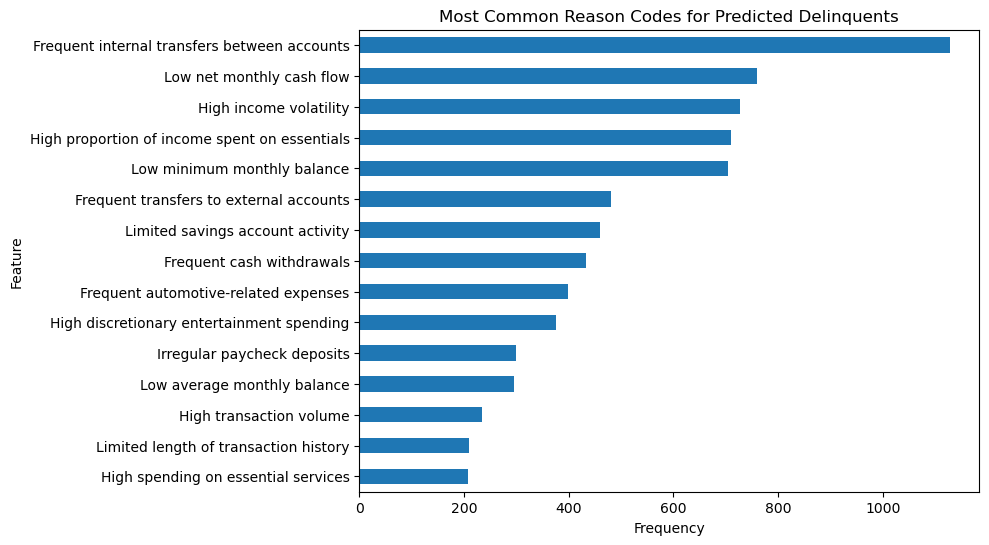

In [156]:
import matplotlib.pyplot as plt

top_n = 15

reason_counts.head(top_n).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Most Common Reason Codes for Predicted Delinquents")
plt.xlabel("Frequency")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.show()

In [157]:
# pick which X to explain
Xtr = X_train_50.copy() if "X_train_50" in globals() else X_train.copy()
Xte = X_test_50.copy()  if "X_test_50"  in globals() else X_test.copy()

# pull out steps
imputer = lgb_final.named_steps["imputer"]
clf = lgb_final.named_steps["clf"]

# transform data exactly the same way the model sees it
Xtr_imp = imputer.transform(Xtr)
Xte_imp = imputer.transform(Xte)

# keep feature names for plots
feature_names = list(Xtr.columns)

# (optional) speed: use a smaller background set for SHAP
bg_size = min(1000, Xtr_imp.shape[0])
rng = np.random.default_rng(42)
bg_idx = rng.choice(Xtr_imp.shape[0], size=bg_size, replace=False)
X_bg = Xtr_imp[bg_idx]

# Build explainer (TreeExplainer under the hood for LGBM)
explainer = shap.Explainer(clf, X_bg, feature_names=feature_names)

# Explain a subset of test rows for speed (optional)
explain_n = min(2000, Xte_imp.shape[0])
X_explain = Xte_imp[:explain_n]

shap_values = explainer(X_explain)

 98%|===================| 1885/1925 [00:21<00:00]        

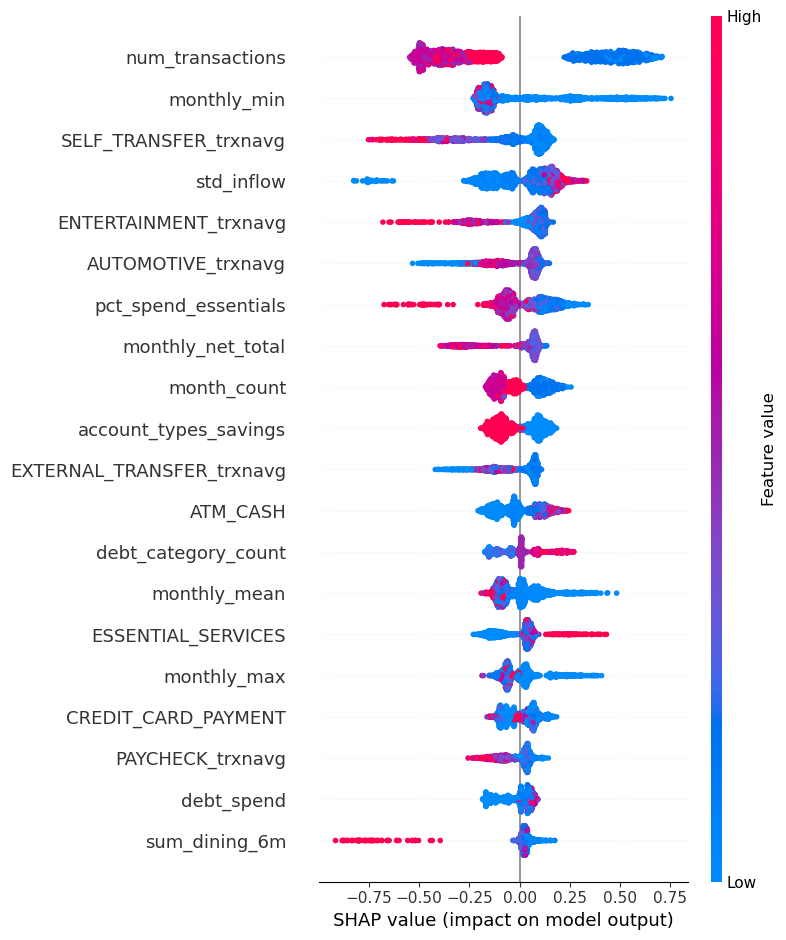

In [158]:
shap.summary_plot(shap_values, feature_names=feature_names)

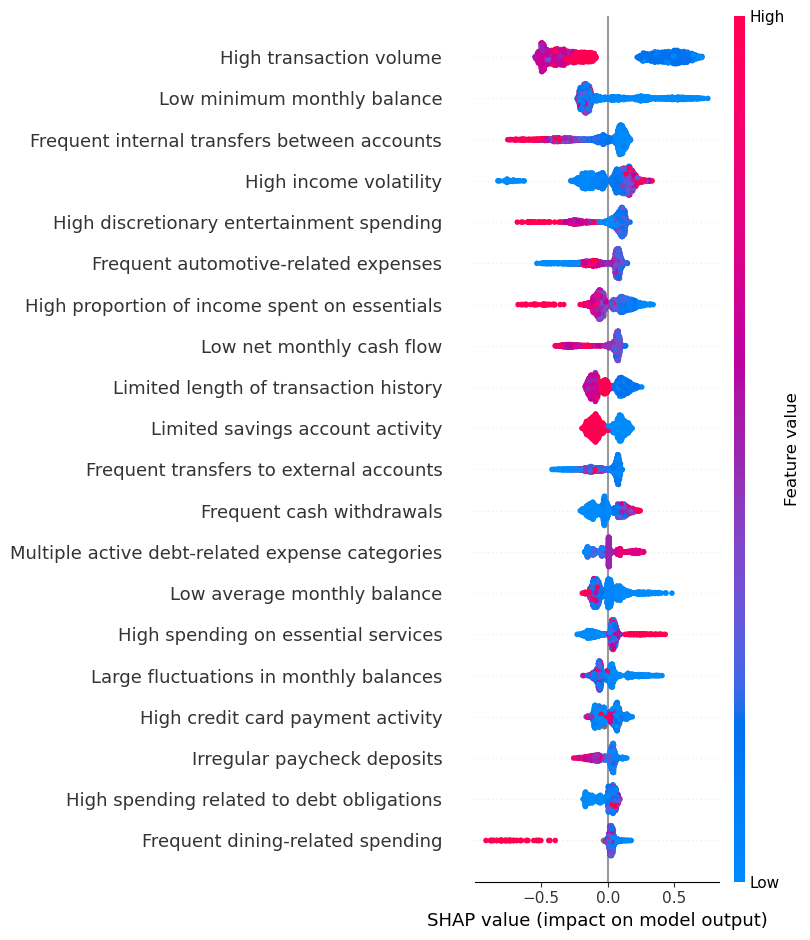

In [159]:
# 1) choose what you explained (same rows, same order)
explain_n = min(2000, X_test_50.shape[0])
X_explain_df = X_test_50.iloc[:explain_n].copy()   # <-- dataframe with feature names

# 2) build readable labels
feature_names = [reason_map.get(f, f) for f in X_explain_df.columns]

# 3) plot (rows match now)
shap.summary_plot(
    shap_values.values,          # computed on explain_n rows
    features=X_explain_df,       # SAME explain_n rows
    feature_names=feature_names
)

reminders for reading the SHAP plot: 
- X-axis: SHAP value
  - right side (positive SHAP) --> increases predicted delinquency risk
  - left side (negative SHAP) --> decreases predicted delinquency risk
- red = high value of that feature
- blue = low value of that feature
  - red points on the right --> high values increase delinquency risk
  - red points on the left --> high values reduce delinquency risk

1. high transaction volume
   - red points on the left, blue points on the right
   - high transaction activity --> lower delinquency risk
   - low transaction activity --> higher delinquency risk
   - financially active consumers are healthier, very low activity could signal limited financial engagement

## cash score vs credit score distribution

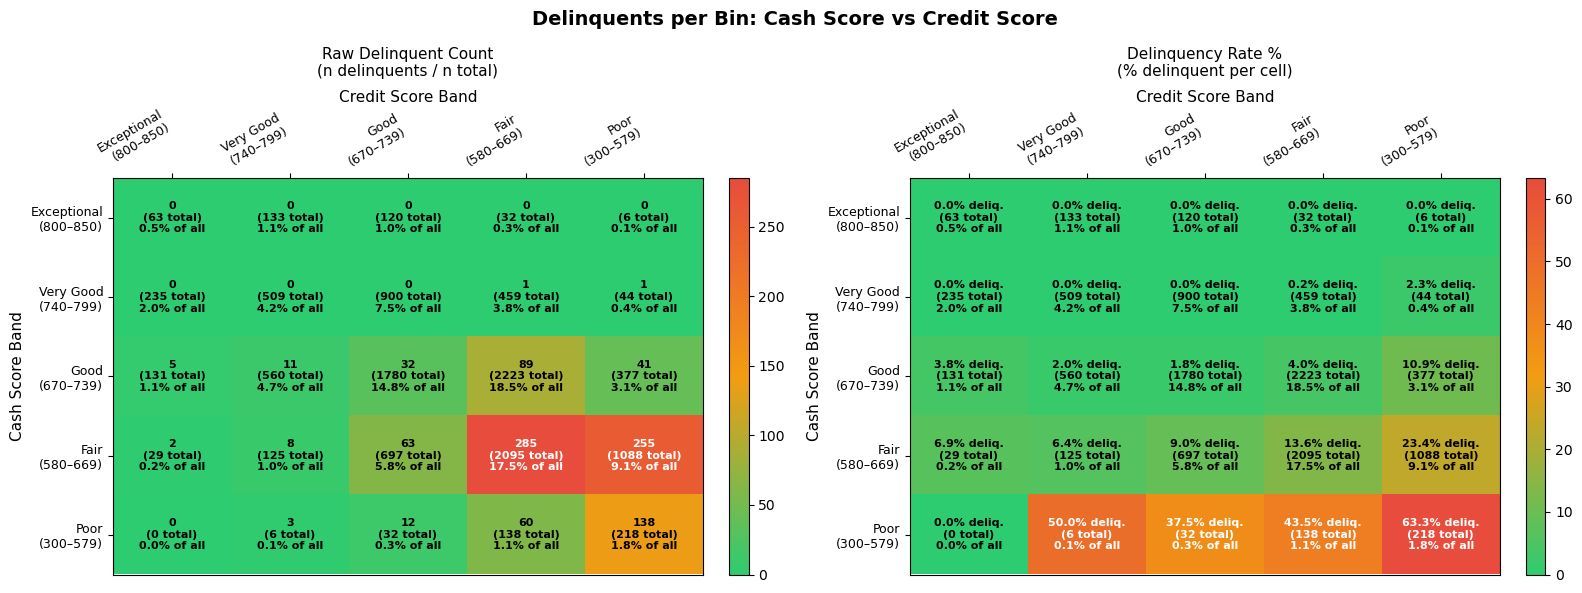

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# =========================
# 0) Build plot dataframe: final_output + credit_score (+ DQ_TARGET if needed)
# =========================
final_plot = final_output.merge(
    consdf[["prism_consumer_id", "credit_score"]],
    on="prism_consumer_id",
    how="left"
)

# Bring back label if final_output doesn't have it (needed for delinquency counts/rates)
if "DQ_TARGET" not in final_plot.columns and "df_eval_master" in globals():
    final_plot = final_plot.merge(
        df_eval_master[["prism_consumer_id", "DQ_TARGET"]],
        on="prism_consumer_id",
        how="left"
    )

# Sanity checks
if "cash_score" not in final_plot.columns:
    raise ValueError("final_output must contain 'cash_score'.")
if "credit_score" not in final_plot.columns:
    raise ValueError("Could not merge 'credit_score' from consdf (check consdf columns/IDs).")

# =========================
# 1) Define bins + reverse order (Exceptional -> Poor)
# =========================
score_bins = [300, 579, 669, 739, 799, 850]

bin_labels_poor_to_exc = [
    "Poor\n(300–579)",
    "Fair\n(580–669)",
    "Good\n(670–739)",
    "Very Good\n(740–799)",
    "Exceptional\n(800–850)",
]
bin_labels = list(reversed(bin_labels_poor_to_exc))  # Exceptional -> Poor

# Create bins (labels must align with score_bins order), then re-order categories
final_plot["cash_bin"] = pd.cut(
    final_plot["cash_score"],
    bins=score_bins,
    labels=bin_labels_poor_to_exc,
    include_lowest=True
)
final_plot["credit_bin"] = pd.cut(
    final_plot["credit_score"],
    bins=score_bins,
    labels=bin_labels_poor_to_exc,
    include_lowest=True
)

final_plot["cash_bin"] = pd.Categorical(final_plot["cash_bin"], categories=bin_labels, ordered=True)
final_plot["credit_bin"] = pd.Categorical(final_plot["credit_bin"], categories=bin_labels, ordered=True)

# =========================
# 2) Compute delinquency matrices (only labeled rows; holdout has no DQ_TARGET)
# =========================
if "DQ_TARGET" not in final_plot.columns:
    raise ValueError("Need DQ_TARGET to compute delinquency counts/rates. Merge it back first.")

labeled = final_plot[final_plot["DQ_TARGET"].notna()].copy()
labeled["true_label"] = labeled["DQ_TARGET"].astype(int)

delinquents = (
    labeled[labeled["true_label"] == 1]
    .groupby(["cash_bin", "credit_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)

totals = (
    labeled
    .groupby(["cash_bin", "credit_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Ensure full Exceptional->Poor grid
delinquents = delinquents.reindex(index=bin_labels, columns=bin_labels, fill_value=0)
totals      = totals.reindex(index=bin_labels, columns=bin_labels, fill_value=0)

rates = (delinquents / totals.replace(0, np.nan) * 100).fillna(0)

# =========================
# 3) Plot
# =========================
cmap = LinearSegmentedColormap.from_list("risk", ["#2ecc71", "#f39c12", "#e74c3c"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Delinquents per Bin: Cash Score vs Credit Score", fontsize=14, fontweight="bold")

grand_total = totals.values.sum()

for ax, matrix, anno_matrix, title, fmt in [
    (axes[0], delinquents, totals, "Raw Delinquent Count\n(n delinquents / n total)", "count"),
    (axes[1], rates,       totals, "Delinquency Rate %\n(% delinquent per cell)",     "rate"),
]:
    vmax = matrix.values.max()
    im = ax.imshow(matrix.values, cmap=cmap, aspect="auto", vmin=0, vmax=vmax if vmax > 0 else 1)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            total_val = int(anno_matrix.values[i, j])
            cell_val  = matrix.values[i, j]
            pct_of_total = (total_val / grand_total * 100) if grand_total > 0 else 0.0
            text_color = "white" if cell_val > (vmax * 0.5) else "black"

            if fmt == "count":
                label = f"{int(cell_val)}\n({total_val} total)\n{pct_of_total:.1f}% of all"
            else:
                label = f"{cell_val:.1f}% deliq.\n({total_val} total)\n{pct_of_total:.1f}% of all"

            ax.text(j, i, label, ha="center", va="center", fontsize=8, color=text_color, fontweight="bold")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, fontsize=9, rotation=30, ha="right")
    ax.set_yticklabels(matrix.index, fontsize=9)

    ax.set_xlabel("Credit Score Band", fontsize=11)
    ax.set_ylabel("Cash Score Band", fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)

    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.ax.invert_yaxis()  # keeps your prior styling convention

plt.tight_layout()
plt.show()

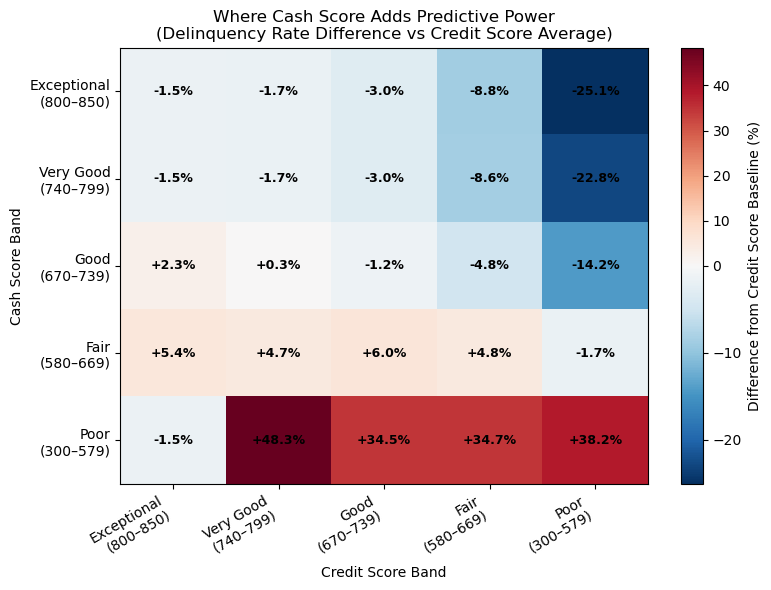

In [161]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# --- Average delinquency rate for each credit score band ---
credit_avg = (
    (rates * totals)
    .sum(axis=0) / totals.sum(axis=0)
)

# --- Compute difference vs credit-score average ---
diff = rates.copy()

for col in diff.columns:
    diff[col] = diff[col] - credit_avg[col]

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(8,6))

norm = TwoSlopeNorm(vmin=diff.values.min(),
                    vcenter=0,
                    vmax=diff.values.max())

im = ax.imshow(diff.values,
               cmap="RdBu_r",
               norm=norm,
               aspect="auto")

for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        val = diff.values[i,j]
        ax.text(j, i, f"{val:+.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold")

ax.set_xticks(range(len(diff.columns)))
ax.set_yticks(range(len(diff.index)))

ax.set_xticklabels(diff.columns, rotation=30, ha="right")
ax.set_yticklabels(diff.index)

ax.set_title("Where Cash Score Adds Predictive Power\n(Delinquency Rate Difference vs Credit Score Average)")
ax.set_xlabel("Credit Score Band")
ax.set_ylabel("Cash Score Band")

plt.colorbar(im, ax=ax, label="Difference from Credit Score Baseline (%)")

plt.tight_layout()
plt.show()

actual delinquency rate in that group vs average delinquency rate for that credit score band
- the cash score adds extra predictive power by identifying risk differences among people who have the same credit score.
- red: higher risk than what credit score suggests 
- blue: lower risk than what credit score suggests

pos + 34.5%: people in that group are 34.5% more likely to be delinquent than typical borrowers with that credit score

This heatmap shows how the cash score changes delinquency risk within each credit score band. Positive values mean borrowers are riskier than what their credit score alone would suggest, while negative values mean they are safer. The pattern shows that the cash score helps distinguish risk among people with the same credit score, identifying both hidden high-risk borrowers and unexpectedly safe ones.

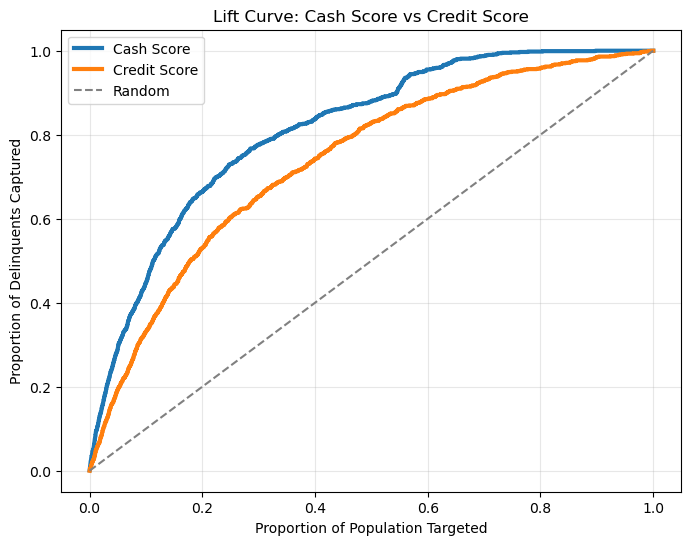

In [162]:
import numpy as np
import matplotlib.pyplot as plt

# Only use rows with known labels
df = final_plot[final_plot["DQ_TARGET"].notna()].copy()
df["label"] = df["DQ_TARGET"].astype(int)

# Sort by predicted risk
df_cash = df.sort_values("cash_score")       # lower score = riskier
df_credit = df.sort_values("credit_score")   # lower credit score = riskier

# cumulative delinquency capture
def lift_curve(df, label_col):
    total_delinq = df[label_col].sum()
    cum_delinq = df[label_col].cumsum()
    pct_population = np.arange(1, len(df)+1) / len(df)
    pct_captured = cum_delinq / total_delinq
    return pct_population, pct_captured

x_cash, y_cash = lift_curve(df_cash, "label")
x_credit, y_credit = lift_curve(df_credit, "label")

# Plot
plt.figure(figsize=(8,6))

plt.plot(x_cash, y_cash, label="Cash Score", linewidth=3)
plt.plot(x_credit, y_credit, label="Credit Score", linewidth=3)

# random baseline
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random")

plt.xlabel("Proportion of Population Targeted")
plt.ylabel("Proportion of Delinquents Captured")
plt.title("Lift Curve: Cash Score vs Credit Score")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

- A lift curve shows how quickly a model finds delinquent customers when we rank people from highest risk to lowest risk. The higher the curve, the better the model is at identifying risk early.
- If i target the riskiest X% of customers, how many delinqunets do i capture?
- The cash score curve stays above the credit score curve, meaning it captures more delinquent borrowers among the highest-risk customers.
- If you review the top 20% riskiest customers according to the cash score, you capture about 70% of all delinquents.
- Used probability score to determine their riskiness.

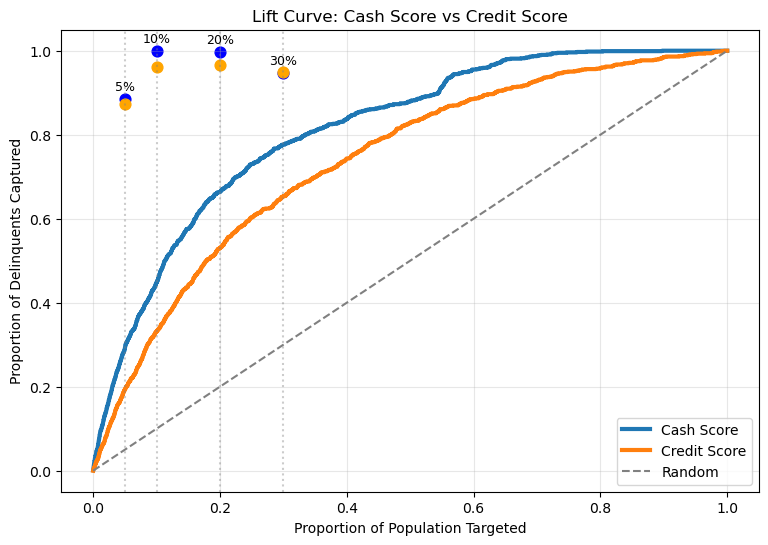

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# thresholds to highlight
thresholds = [0.05, 0.10, 0.20, 0.30]

plt.figure(figsize=(9,6))

plt.plot(x_cash, y_cash, label="Cash Score", linewidth=3)
plt.plot(x_credit, y_credit, label="Credit Score", linewidth=3)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random")

# highlight thresholds
for t in thresholds:
    idx_cash = np.searchsorted(x_cash, t)
    idx_credit = np.searchsorted(x_credit, t)

    plt.scatter(x_cash[idx_cash], y_cash[idx_cash], color="blue", s=60)
    plt.scatter(x_credit[idx_credit], y_credit[idx_credit], color="orange", s=60)

    plt.axvline(t, linestyle=":", color="gray", alpha=0.4)

    plt.text(
        t,
        y_cash[idx_cash] + 0.02,
        f"{int(t*100)}%",
        ha="center",
        fontsize=9
    )

plt.xlabel("Proportion of Population Targeted")
plt.ylabel("Proportion of Delinquents Captured")
plt.title("Lift Curve: Cash Score vs Credit Score")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

- If a lender targeted the riskiest 5% of customers using the cash score, they would capture roughly 85–90% of all delinquents, significantly outperforming credit score alone.
- The cash score identifies high-risk borrowers earlier than the credit score, meaning lenders could detect more delinquencies while reviewing fewer customers.
- This lift curve shows how well the cash score and credit score identify delinquent borrowers. The cash score captures a larger share of delinquents among the highest-risk customers, meaning it can detect risky borrowers more efficiently than credit score alone.
- The dots mark specific points on the lift curve showing how many delinquents are captured if we focus on the top 5%, 10%, 20%, or 30% riskiest customers.

In [107]:
import shap

In [110]:
import pandas as pd
import numpy as np

# feature names (top-50)
feat_names = X_train_50.columns

# --- XGBoost global importance (gain) ---
xgb_clf = xgb_final.named_steps["clf"]
xgb_gain = xgb_clf.get_booster().get_score(importance_type="gain")

xgb_imp = (
    pd.DataFrame({"feature": list(xgb_gain.keys()), "importance_gain": list(xgb_gain.values())})
      .sort_values("importance_gain", ascending=False)
)

print("\nXGBoost Top 10 (gain):")
display(xgb_imp.head(10))

# --- LightGBM global importance ---
lgb_clf = lgb_final.named_steps["clf"]
lgb_imp = (
    pd.DataFrame({"feature": feat_names, "importance_split": lgb_clf.feature_importances_})
      .sort_values("importance_split", ascending=False)
)

print("\nLightGBM Top 10 (split importance):")
display(lgb_imp.head(10))


XGBoost Top 10 (gain):


,feature,importance_gain
18,f18,67.179535
35,f35,65.225906
10,f10,15.486043
2,f2,13.534212
11,f11,13.499074
36,f36,11.238762
14,f14,11.186075
6,f6,10.831423
49,f49,10.750791
40,f40,10.628736



LightGBM Top 10 (split importance):


,feature,importance_split
15,std_inflow,293
34,AUTOMOTIVE_trxnavg,274
11,monthly_min,263
19,pct_spend_essentials,222
6,monthly_mean,220
48,ENTERTAINMENT_trxnavg,205
17,ESSENTIAL_SERVICES,188
12,monthly_net_total,177
28,monthly_net_max,167
0,SELF_TRANSFER_trxnavg,163


In [115]:
# Use the transformed data that the model actually sees after imputation
# (we'll just impute manually once for SHAP)
imputer = SimpleImputer(strategy="median")
X_train_50_imp = pd.DataFrame(imputer.fit_transform(X_train_50), columns=X_train_50.columns, index=X_train_50.index)
X_test_50_imp  = pd.DataFrame(imputer.transform(X_test_50),      columns=X_test_50.columns, index=X_test_50.index)

# Fit fresh "raw" estimators on imputed data for SHAP (simpler + reliable)
xgb_raw = XGBClassifier(
    random_state=42, eval_metric="auc", tree_method="hist",
    n_estimators=600, max_depth=4, learning_rate=0.01,
    subsample=0.85, colsample_bytree=0.7, min_child_weight=3,
    gamma=0, reg_alpha=0, reg_lambda=0.5
)
xgb_raw.fit(X_train_50_imp, y_train)

lgb_raw = LGBMClassifier(
    random_state=42, objective="binary", class_weight="balanced", verbosity=-1,
    n_estimators=900, max_depth=3, learning_rate=0.01,
    subsample=0.7, colsample_bytree=0.85, num_leaves=15,
    min_child_samples=80, reg_alpha=0.01, reg_lambda=2.0
)
lgb_raw.fit(X_train_50_imp, y_train)

# SHAP explainers
xgb_explainer = shap.TreeExplainer(xgb_raw)
lgb_explainer = shap.TreeExplainer(lgb_raw)

# SHAP values for test set
xgb_shap = xgb_explainer.shap_values(X_test_50_imp)
lgb_shap = lgb_explainer.shap_values(X_test_50_imp)

print("SHAP computed:")
print("xgb_shap shape:", np.array(xgb_shap).shape)
print("lgb_shap shape:", np.array(lgb_shap).shape)

SHAP computed:
xgb_shap shape: (1925, 50)
lgb_shap shape: (1925, 50)


/home/ekw002/.local/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [116]:
# Use the exact column order the model saw during training:
feat_names = list(X_train_50_imp.columns)  # or X_train_50.columns

xgb_gain = xgb_clf.get_booster().get_score(importance_type="gain")

def f_to_name(f):
    m = re.fullmatch(r"f(\d+)", str(f))
    if not m:
        return str(f)
    j = int(m.group(1))
    return feat_names[j] if 0 <= j < len(feat_names) else str(f)

xgb_imp_named = (
    pd.DataFrame({"feature": list(xgb_gain.keys()), "importance_gain": list(xgb_gain.values())})
      .assign(feature_name=lambda d: d["feature"].map(f_to_name))
      .sort_values("importance_gain", ascending=False)
      .loc[:, ["feature_name", "importance_gain"]]
      .rename(columns={"feature_name": "feature"})
      .reset_index(drop=True)
)

display(xgb_imp_named.head(10))

,feature,importance_gain
0,month_count,67.179535
1,num_transactions,65.225906
2,CREDIT_CARD_PAYMENT,15.486043
3,monthly_max,13.534212
4,monthly_min,13.499074
5,has_acct_fee_6m,11.238762
6,debt_category_count,11.186075
7,monthly_mean,10.831423
8,overdraft_count,10.750791
9,income_span_days,10.628736


In [117]:
# Pick one applicant from the test set
i = 0  # change this index as you like
x_row = X_test_50_imp.iloc[i]

# predicted risk (prob of DQ=1)
xgb_prob = xgb_raw.predict_proba(x_row.to_frame().T)[:, 1][0]
lgb_prob = lgb_raw.predict_proba(x_row.to_frame().T)[:, 1][0]

print("Applicant index:", X_test_50_imp.index[i])
print("XGB risk prob:", round(xgb_prob, 4))
print("LGB risk prob:", round(lgb_prob, 4))

# SHAP contributions for this applicant
xgb_row_shap = pd.Series(xgb_shap[i], index=X_test_50_imp.columns)
lgb_row_shap = pd.Series(lgb_shap[i], index=X_test_50_imp.columns)

# Positive SHAP = pushes risk UP (toward DQ=1)
xgb_top_reasons = xgb_row_shap.sort_values(ascending=False).head(5)
lgb_top_reasons = lgb_row_shap.sort_values(ascending=False).head(5)

print("\nXGBoost top risk-increasing features (reason codes):")
display(xgb_top_reasons)

print("\nLightGBM top risk-increasing features (reason codes):")
display(lgb_top_reasons)

Applicant index: 5299
XGB risk prob: 0.0454
LGB risk prob: 0.2864

XGBoost top risk-increasing features (reason codes):


std_inflow             0.278091
num_transactions       0.230810
month_count            0.115806
AUTOMOTIVE_trxnavg     0.092989
debt_category_count    0.092060
dtype: float32


LightGBM top risk-increasing features (reason codes):


num_transactions      0.362347
std_inflow            0.235468
month_count           0.136565
monthly_net_total     0.112351
AUTOMOTIVE_trxnavg    0.096171
dtype: float64

In [118]:
reason_map = {
    "overdraft_count": "Frequent overdrafts observed in recent history.",
    "overdraft_median": "Large overdraft amounts observed.",
    "has_overdraft_6m": "Overdraft activity in the last 6 months.",
    "account_fees_count": "Frequent account fees assessed.",
    "account_fees_median": "High typical account fee amounts.",
    "BNPL_std": "Highly variable BNPL usage.",
    "bnpl_usage_flag": "BNPL usage present in recent history.",
    "debt_spend_ratio": "High share of spending going to debt-related categories.",
    "debt_category_count": "Spending across multiple debt-related categories.",
    "essential_spend_volatility_6m": "Unstable essential spending patterns.",
    "atm_cash_ratio": "High share of spending as cash withdrawals.",
    "atm_cash_freq_6m": "Frequent cash withdrawals.",
    "refund_ratio_y": "Unusually high refund activity relative to spending.",
    "income_span_days": "Limited or inconsistent observed income history.",
    "trend": "Downward trend in net cash flow over time.",
    "monthly_std_avg": "High volatility in monthly net cash flow.",
}

def explain_reasons(top_shap_series, x_row, reason_map, k=3):
    out = []
    for feat, shap_val in top_shap_series.head(k).items():
        val = x_row.get(feat, np.nan)
        msg = reason_map.get(feat, f"Feature '{feat}' contributed to higher predicted risk.")
        out.append({
            "feature": feat,
            "value": val,
            "shap": float(shap_val),
            "reason": msg
        })
    return pd.DataFrame(out)

# Example: explain top 3 for XGB applicant i
xgb_reason_table = explain_reasons(xgb_top_reasons, x_row, reason_map, k=3)
lgb_reason_table = explain_reasons(lgb_top_reasons, x_row, reason_map, k=3)

print("XGB reason codes (top 3):")
display(xgb_reason_table)

print("LGB reason codes (top 3):")
display(lgb_reason_table)

XGB reason codes (top 3):


,feature,value,shap,reason
0,std_inflow,19861.31131,0.278091,Feature 'std_inflow' contributed to higher pre...
1,num_transactions,3.00000,0.230810,Feature 'num_transactions' contributed to high...
2,month_count,4.00000,0.115806,Feature 'month_count' contributed to higher pr...


LGB reason codes (top 3):


,feature,value,shap,reason
0,num_transactions,3.00000,0.362347,Feature 'num_transactions' contributed to high...
1,std_inflow,19861.31131,0.235468,Feature 'std_inflow' contributed to higher pre...
2,month_count,4.00000,0.136565,Feature 'month_count' contributed to higher pr...


In [119]:
THRESH = 0.5  # change later if you tune threshold

# choose one model for decisions (example: LightGBM)
probs = lgb_raw.predict_proba(X_test_50_imp)[:, 1]
rejected_mask = probs >= THRESH

rejected_idx = X_test_50_imp.index[rejected_mask]
print("Rejected count:", rejected_mask.sum())

# build reason codes for each rejected applicant (top 3)
rows = []
for j, idx in enumerate(rejected_idx):
    pos = np.where(X_test_50_imp.index == idx)[0][0]
    x_row = X_test_50_imp.iloc[pos]
    shap_row = pd.Series(lgb_shap[pos], index=X_test_50_imp.columns)
    top = shap_row.sort_values(ascending=False).head(3)

    reason_df = explain_reasons(top, x_row, reason_map, k=3)
    reason_df.insert(0, "prism_consumer_id", idx)
    reason_df.insert(1, "risk_prob", probs[pos])
    rows.append(reason_df)

reason_codes_all = pd.concat(rows, ignore_index=True)
display(reason_codes_all.head(15))

Rejected count: 549


,prism_consumer_id,risk_prob,feature,value,shap,reason
0,7077,0.751684,num_transactions,2.000000,0.478891,Feature 'num_transactions' contributed to high...
1,7077,0.751684,monthly_min,-30501.120000,0.426602,Feature 'monthly_min' contributed to higher pr...
2,7077,0.751684,monthly_mean,-22469.760000,0.237943,Feature 'monthly_mean' contributed to higher p...
3,6151,0.800976,num_transactions,3.000000,0.650822,Feature 'num_transactions' contributed to high...
4,6151,0.800976,monthly_min,-3292.910000,0.429342,Feature 'monthly_min' contributed to higher pr...
5,6151,0.800976,month_count,4.000000,0.289409,Feature 'month_count' contributed to higher pr...
6,4105,0.883223,num_transactions,3.000000,0.637859,Feature 'num_transactions' contributed to high...
7,4105,0.883223,monthly_mean,92.400000,0.513601,Feature 'monthly_mean' contributed to higher p...
8,4105,0.883223,monthly_min,25.200000,0.466327,Feature 'monthly_min' contributed to higher pr...
9,7779,0.728873,num_transactions,3.000000,0.540922,Feature 'num_transactions' contributed to high...


In [120]:
def prob_to_fico(risk_prob: float, min_score: int = 300, max_score: int = 850) -> int:
    """
    Convert a risk probability (0–1) to a FICO-like score (300–850).
    Higher risk probability → Lower score (mirrors real FICO behavior).
    
    Args:
        risk_prob: Model output probability of default/risk (0.0 to 1.0)
        min_score: Minimum score (default 300)
        max_score: Maximum score (default 850)
    
    Returns:
        Integer score between 300 and 850
    """
    risk_prob = max(0.0, min(1.0, risk_prob))  # clamp to [0, 1]
    score = max_score - (risk_prob * (max_score - min_score))
    return round(score)


# --- Apply to your dataframe ---
# Deduplicate to one row per consumer first, then map scores
import pandas as pd

# df is your existing dataframe with prism_consumer_id and risk_prob columns
consumer_scores = (
    reason_codes_all.drop_duplicates(subset="prism_consumer_id")[["prism_consumer_id", "risk_prob"]]
    .copy()
)

consumer_scores["cash_score"] = consumer_scores["risk_prob"].apply(prob_to_fico)

print(consumer_scores)

      prism_consumer_id  risk_prob  cash_score
0                  7077   0.751684         437
3                  6151   0.800976         409
6                  4105   0.883223         364
9                  7779   0.728873         449
12                 4881   0.511092         569
...                 ...        ...         ...
1632               7892   0.659472         487
1635               7159   0.839431         388
1638               4245   0.529762         559
1641               4421   0.611983         513
1644               5521   0.674788         479

[549 rows x 3 columns]


In [121]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt

# --- Base data ---
probs      = applicant_summary["risk_prob"].values
true_labels = applicant_summary["true_label"].values

# ── Helper: convert probs → scores with custom min/max ──
def make_scores(probs, min_score, max_score):
    probs_clamped = np.clip(probs, 0, 1)
    return max_score - (probs_clamped * (max_score - min_score))

# ── Objective: maximize AUC (minimize negative AUC) ──
def objective(params):
    min_score, max_score = params
    if max_score <= min_score:
        return 1.0  # invalid
    scores = make_scores(probs, min_score, max_score)
    return -roc_auc_score(true_labels, scores)  # negate because we minimize

# ==============================================================
# METHOD 1 — GRID SEARCH
# ==============================================================
min_range = range(200, 500, 10)
max_range = range(700, 900, 10)

results = []
for mn in min_range:
    for mx in max_range:
        if mx <= mn:
            continue
        scores = make_scores(probs, mn, mx)
        auc    = roc_auc_score(true_labels, scores)
        # Gini coefficient (common in credit scoring)
        gini   = 2 * auc - 1
        # KS statistic
        pos_scores = scores[true_labels == 1]
        neg_scores = scores[true_labels == 0]
        ks = abs(
            np.mean(pos_scores < np.median(scores)) -
            np.mean(neg_scores < np.median(scores))
        )
        results.append({"min_score": mn, "max_score": mx, "auc": auc, "gini": gini, "ks": ks})

grid_df = pd.DataFrame(results).sort_values("auc", ascending=False)
best_grid = grid_df.iloc[0]

print("── GRID SEARCH BEST ──")
print(f"  min_score : {int(best_grid.min_score)}")
print(f"  max_score : {int(best_grid.max_score)}")
print(f"  AUC       : {best_grid.auc:.4f}")
print(f"  Gini      : {best_grid.gini:.4f}")
print(f"  KS        : {best_grid.ks:.4f}")

# ==============================================================
# METHOD 2 — SCIPY OPTIMIZE
# ==============================================================
initial_params = [300, 850]
bounds = [(200, 500), (700, 900)]

opt_result = minimize(
    objective,
    x0=initial_params,
    bounds=bounds,
    method="L-BFGS-B",
    options={"ftol": 1e-9, "gtol": 1e-6}
)

opt_min, opt_max = opt_result.x
opt_scores = make_scores(probs, opt_min, opt_max)
opt_auc    = roc_auc_score(true_labels, opt_scores)
opt_gini   = 2 * opt_auc - 1

print("\n── SCIPY OPTIMIZE BEST ──")
print(f"  min_score : {opt_min:.1f}")
print(f"  max_score : {opt_max:.1f}")
print(f"  AUC       : {opt_auc:.4f}")
print(f"  Gini      : {opt_gini:.4f}")
print(f"  Converged : {opt_result.success}")

# ==============================================================
# COMPARISON PLOT
# ==============================================================
default_scores = make_scores(probs, 300, 850)
grid_scores    = make_scores(probs, int(best_grid.min_score), int(best_grid.max_score))
scipy_scores   = make_scores(probs, opt_min, opt_max)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Score Distribution by Method — Delinquents vs Non-Delinquents", fontsize=13, fontweight="bold")

configs = [
    (axes[0], default_scores, "Default (300–850)",
     f"AUC: {roc_auc_score(true_labels, default_scores):.4f}"),
    (axes[1], grid_scores,    f"Grid Search ({int(best_grid.min_score)}–{int(best_grid.max_score)})",
     f"AUC: {best_grid.auc:.4f}  Gini: {best_grid.gini:.4f}"),
    (axes[2], scipy_scores,   f"Scipy ({opt_min:.0f}–{opt_max:.0f})",
     f"AUC: {opt_auc:.4f}  Gini: {opt_gini:.4f}"),
]

bins = np.linspace(200, 900, 40)
for ax, scores, title, subtitle in configs:
    ax.hist(scores[true_labels == 0], bins=bins, alpha=0.65, color="#2ecc71",
            label=f"Non-delinquent ({(true_labels==0).sum()})", edgecolor="white")
    ax.hist(scores[true_labels == 1], bins=bins, alpha=0.65, color="#e74c3c",
            label=f"Delinquent ({(true_labels==1).sum()})", edgecolor="white")
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ==============================================================
# AUC HEATMAP — Grid Search surface
# ==============================================================
pivot = grid_df.pivot(index="min_score", columns="max_score", values="auc")

fig2, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
               vmin=pivot.values.min(), vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, fontsize=7)
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xlabel("max_score", fontsize=11)
ax.set_ylabel("min_score", fontsize=11)
ax.set_title("AUC Heatmap — Grid Search (min_score vs max_score)", fontsize=12)
plt.colorbar(im, ax=ax, label="AUC")

# Mark best cell
best_row = list(pivot.index).index(int(best_grid.min_score))
best_col = list(pivot.columns).index(int(best_grid.max_score))
ax.add_patch(plt.Rectangle((best_col - 0.5, best_row - 0.5), 1, 1,
             fill=False, edgecolor="blue", linewidth=2.5, label="Best"))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# --- Final recommended function ---
print("\n── RECOMMENDED prob_to_fico ──")
print(f"""
def prob_to_fico(risk_prob: float,
                 min_score: int = {int(best_grid.min_score)},
                 max_score: int = {int(best_grid.max_score)}) -> int:
    risk_prob = max(0.0, min(1.0, risk_prob))
    return round(max_score - (risk_prob * (max_score - min_score)))
""")

NameError: name 'applicant_summary' is not defined

Rejected count: 549 / 1925 total


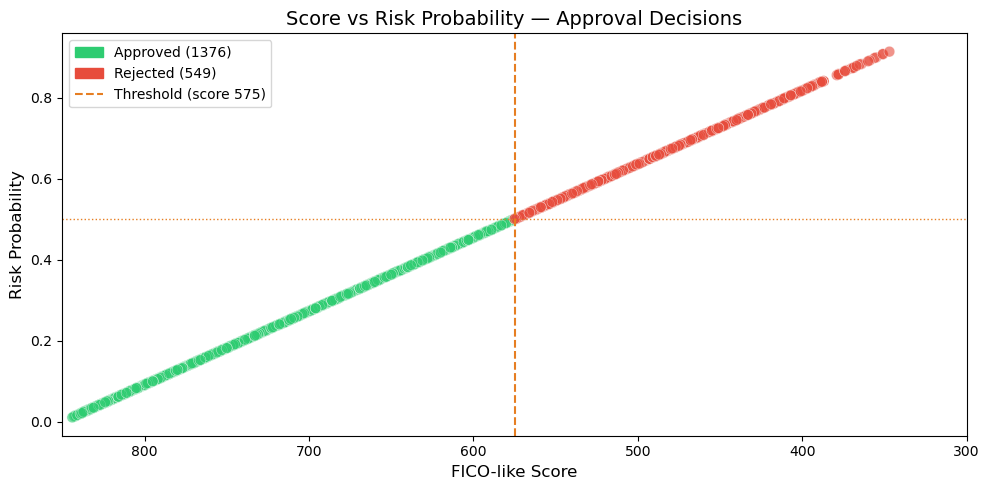

,prism_consumer_id,risk_prob,feature,value,shap,reason
0,5299,0.286429,num_transactions,3.00000,0.362347,Feature 'num_transactions' contributed to high...
1,5299,0.286429,std_inflow,19861.31131,0.235468,Feature 'std_inflow' contributed to higher pre...
2,5299,0.286429,month_count,4.00000,0.136565,Feature 'month_count' contributed to higher pr...
3,7077,0.751684,num_transactions,2.00000,0.478891,Feature 'num_transactions' contributed to high...
4,7077,0.751684,monthly_min,-30501.12000,0.426602,Feature 'monthly_min' contributed to higher pr...
5,7077,0.751684,monthly_mean,-22469.76000,0.237943,Feature 'monthly_mean' contributed to higher p...
6,9875,0.470660,debt_category_count,3.00000,0.214024,Spending across multiple debt-related categories.
7,9875,0.470660,income_span_days,58.00000,0.212305,Limited or inconsistent observed income history.
8,9875,0.470660,ATM_CASH,2651.30000,0.195765,Feature 'ATM_CASH' contributed to higher predi...
9,10943,0.459664,debt_category_count,4.00000,0.259136,Spending across multiple debt-related categories.


,prism_consumer_id,risk_prob,cash_score,decision
0,5299,0.286429,692,Approved
3,7077,0.751684,437,Rejected
6,9875,0.470660,591,Approved
9,10943,0.459664,597,Approved
12,6151,0.800976,409,Rejected
15,8617,0.190952,745,Approved
18,8822,0.341214,662,Approved
21,7752,0.330883,668,Approved
24,11424,0.144103,771,Approved
27,7343,0.374655,644,Approved


In [122]:
THRESH = 0.5  # change later if you tune threshold

# Score EVERYONE
probs = lgb_raw.predict_proba(X_test_50_imp)[:, 1]
rejected_mask = probs >= THRESH
print(f"Rejected count: {rejected_mask.sum()} / {len(probs)} total")

# --- Build reason codes for ALL applicants ---
rows = []
for j, idx in enumerate(X_test_50_imp.index):
    x_row = X_test_50_imp.iloc[j]
    shap_row = pd.Series(lgb_shap[j], index=X_test_50_imp.columns)
    top = shap_row.sort_values(ascending=False).head(3)
    reason_df = explain_reasons(top, x_row, reason_map, k=3)
    reason_df.insert(0, "prism_consumer_id", idx)
    reason_df.insert(1, "risk_prob", probs[j])
    rows.append(reason_df)

reason_codes_all = pd.concat(rows, ignore_index=True)

# --- Build one-row-per-applicant summary with FICO-like score ---
applicant_summary = (
    reason_codes_all
    .drop_duplicates(subset="prism_consumer_id")
    [["prism_consumer_id", "risk_prob"]]
    .copy()
)
applicant_summary["cash_score"] = applicant_summary["risk_prob"].apply(prob_to_fico)
applicant_summary["decision"] = np.where(
    applicant_summary["risk_prob"] >= THRESH, "Rejected", "Approved"
)

# --- Score vs Acceptance chart ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))

colors = applicant_summary["decision"].map({"Approved": "#2ecc71", "Rejected": "#e74c3c"})

ax.scatter(
    applicant_summary["cash_score"],
    applicant_summary["risk_prob"],
    c=colors,
    alpha=0.6,
    edgecolors="white",
    linewidths=0.4,
    s=60,
)

# Threshold line
thresh_score = prob_to_fico(THRESH)
ax.axvline(x=thresh_score, color="#e67e22", linestyle="--", linewidth=1.5, label=f"Threshold (score {thresh_score})")
ax.axhline(y=THRESH, color="#e67e22", linestyle=":", linewidth=1.0)

ax.set_xlabel("FICO-like Score", fontsize=12)
ax.set_ylabel("Risk Probability", fontsize=12)
ax.set_title("Score vs Risk Probability — Approval Decisions", fontsize=14)
ax.set_xlim(300, 850)
ax.invert_xaxis()  # higher score = lower risk, matches FICO convention

approved_patch = mpatches.Patch(color="#2ecc71", label=f"Approved ({(applicant_summary['decision']=='Approved').sum()})")
rejected_patch = mpatches.Patch(color="#e74c3c", label=f"Rejected ({(applicant_summary['decision']=='Rejected').sum()})")
ax.legend(handles=[approved_patch, rejected_patch, ax.get_lines()[0]], fontsize=10)

plt.tight_layout()
plt.show()

display(reason_codes_all.head(15))
display(applicant_summary.head(15))

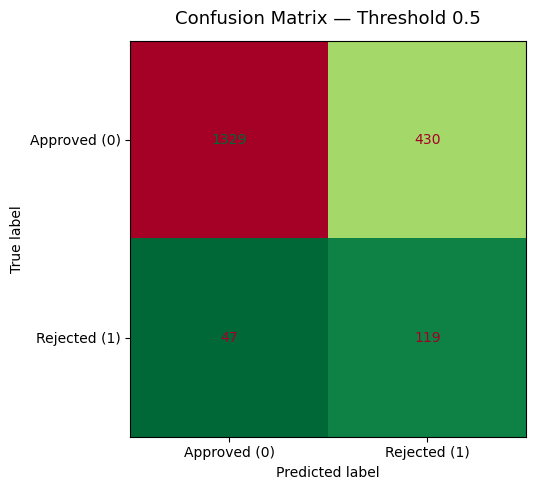

              precision    recall  f1-score   support

    Approved       0.97      0.76      0.85      1759
    Rejected       0.22      0.72      0.33       166

    accuracy                           0.75      1925
   macro avg       0.59      0.74      0.59      1925
weighted avg       0.90      0.75      0.80      1925



In [123]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Predictions vs true labels ---
y_true = y_test
y_pred = (probs >= THRESH).astype(int)

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Approved (0)", "Rejected (1)"]
)
disp.plot(
    ax=ax,
    colorbar=False,
    cmap="RdYlGn_r"
)

ax.set_title(f"Confusion Matrix — Threshold {THRESH}", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# --- Full classification report ---
print(classification_report(y_true, y_pred, target_names=["Approved", "Rejected"]))

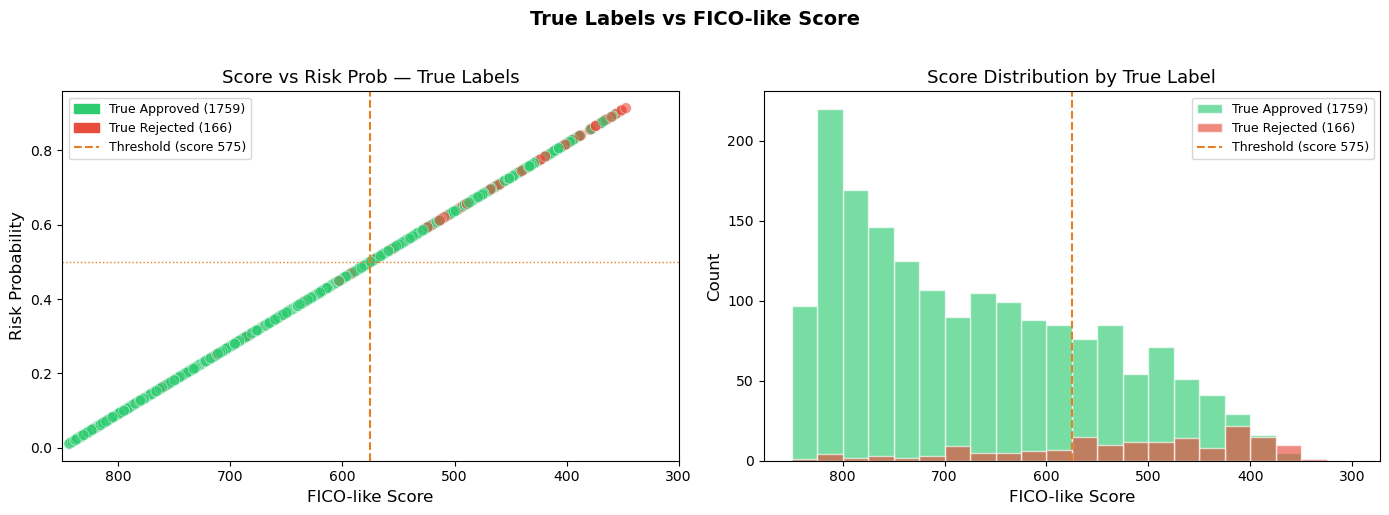

In [124]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Merge true labels into applicant_summary ---
# y_test_50_imp index should align with X_test_50_imp
applicant_summary["true_label"] = y_test.values

applicant_summary["true_label_name"] = applicant_summary["true_label"].map({
    0: "Approved (True)", 
    1: "Rejected (True)"
})

# --- Score distribution by true label ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Plot 1: Scatter — FICO score vs risk prob, colored by TRUE label --
colors = applicant_summary["true_label"].map({0: "#2ecc71", 1: "#e74c3c"})

axes[0].scatter(
    applicant_summary["cash_score"],
    applicant_summary["risk_prob"],
    c=colors,
    alpha=0.6,
    edgecolors="white",
    linewidths=0.4,
    s=60,
)

thresh_score = prob_to_fico(THRESH)
axes[0].axvline(x=thresh_score, color="#e67e22", linestyle="--", linewidth=1.5, label=f"Threshold (score {thresh_score})")
axes[0].axhline(y=THRESH, color="#e67e22", linestyle=":", linewidth=1.0)
axes[0].invert_xaxis()
axes[0].set_xlabel("FICO-like Score", fontsize=12)
axes[0].set_ylabel("Risk Probability", fontsize=12)
axes[0].set_title("Score vs Risk Prob — True Labels", fontsize=13)
axes[0].set_xlim(850, 300)

approved_patch = mpatches.Patch(color="#2ecc71", label=f"True Approved ({(applicant_summary['true_label']==0).sum()})")
rejected_patch = mpatches.Patch(color="#e74c3c", label=f"True Rejected ({(applicant_summary['true_label']==1).sum()})")
thresh_line = plt.Line2D([0], [0], color="#e67e22", linestyle="--", label=f"Threshold (score {thresh_score})")
axes[0].legend(handles=[approved_patch, rejected_patch, thresh_line], fontsize=9)

# -- Plot 2: Histogram — score distribution by true label --
approved = applicant_summary[applicant_summary["true_label"] == 0]["cash_score"]
rejected = applicant_summary[applicant_summary["true_label"] == 1]["cash_score"]

bins = np.arange(300, 860, 25)
axes[1].hist(approved, bins=bins, color="#2ecc71", alpha=0.65, label=f"True Approved ({len(approved)})", edgecolor="white")
axes[1].hist(rejected, bins=bins, color="#e74c3c", alpha=0.65, label=f"True Rejected ({len(rejected)})", edgecolor="white")
axes[1].axvline(x=thresh_score, color="#e67e22", linestyle="--", linewidth=1.5, label=f"Threshold (score {thresh_score})")
axes[1].invert_xaxis()
axes[1].set_xlabel("FICO-like Score", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Score Distribution by True Label", fontsize=13)
axes[1].legend(fontsize=9)

plt.suptitle("True Labels vs FICO-like Score", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [125]:
fixed_consdf = consdf[['prism_consumer_id','credit_score']].copy()
fixed_consdf['prism_consumer_id'] = fixed_consdf['prism_consumer_id'].astype(int)

In [126]:
applicant_summary

,prism_consumer_id,risk_prob,cash_score,decision,true_label,true_label_name
0,5299,0.286429,692,Approved,0,Approved (True)
3,7077,0.751684,437,Rejected,0,Approved (True)
6,9875,0.470660,591,Approved,1,Rejected (True)
9,10943,0.459664,597,Approved,0,Approved (True)
12,6151,0.800976,409,Rejected,1,Rejected (True)
...,...,...,...,...,...,...
5760,619,0.253421,711,Approved,0,Approved (True)
5763,4245,0.529762,559,Rejected,0,Approved (True)
5766,4421,0.611983,513,Rejected,1,Rejected (True)
5769,5521,0.674788,479,Rejected,0,Approved (True)


In [127]:
consdf[consdf['prism_consumer_id'] == 4421]

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET,Evaluation Month


In [128]:
applicant_summary = applicant_summary.merge(fixed_consdf)

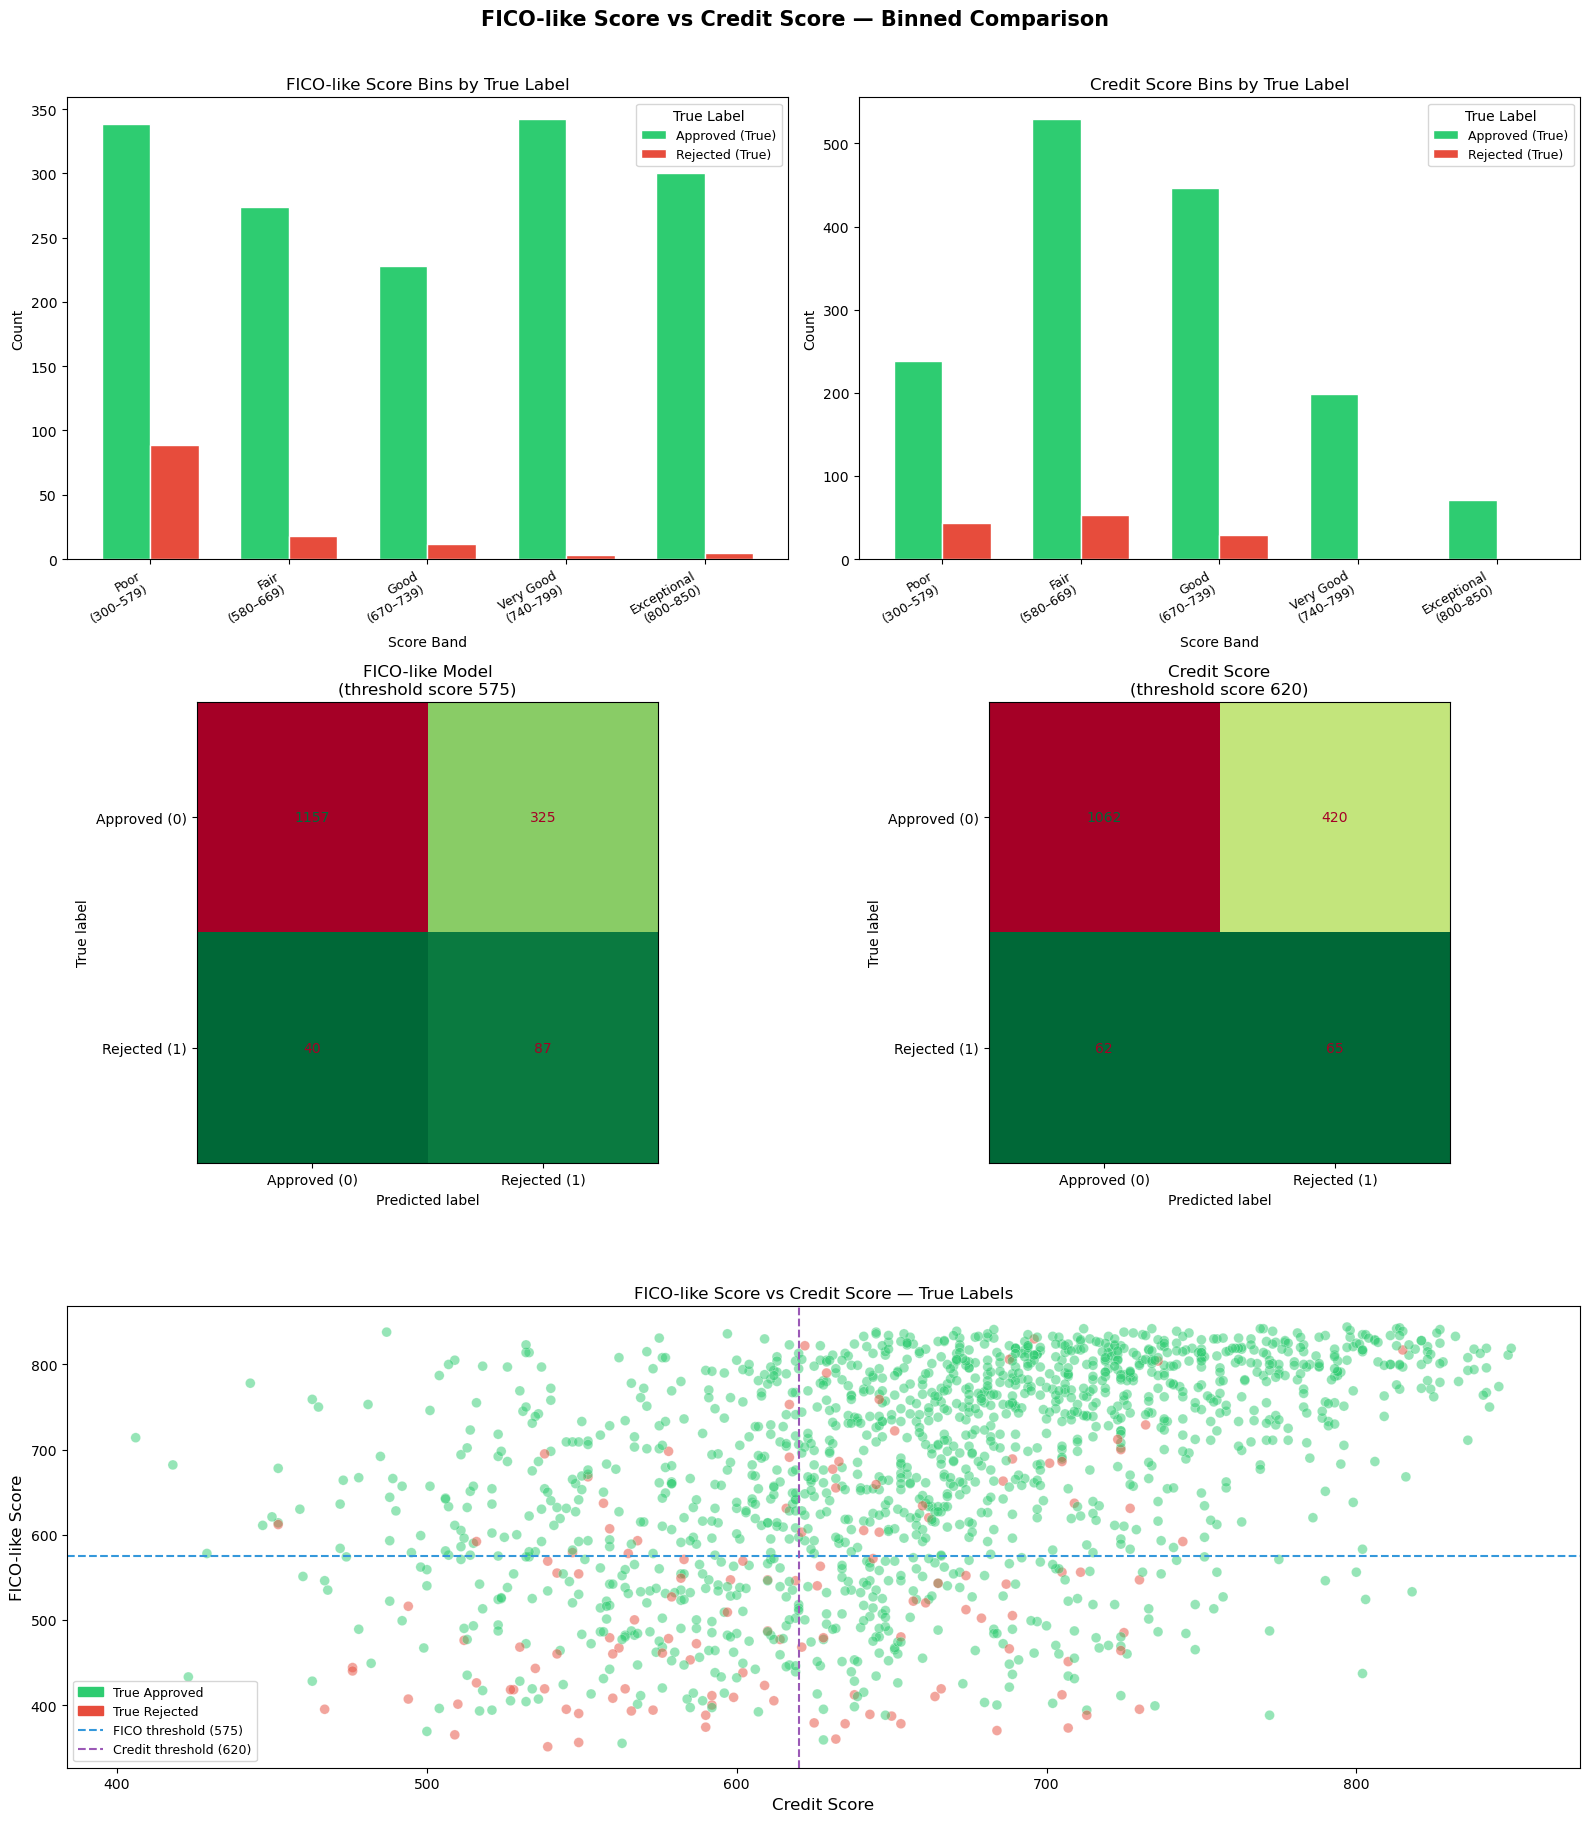


── FICO-like Score bin default rates ──
                        defaults  total  default_rate
fico_bin                                             
Poor\n(300–579)               89    427      0.208431
Fair\n(580–669)               18    292      0.061644
Good\n(670–739)               12    240      0.050000
Very Good\n(740–799)           3    345      0.008696
Exceptional\n(800–850)         5    305      0.016393

── Credit Score bin default rates ──
                        defaults  total  default_rate
credit_bin                                           
Poor\n(300–579)               43    281      0.153025
Fair\n(580–669)               53    582      0.091065
Good\n(670–739)               29    475      0.061053
Very Good\n(740–799)           1    199      0.005025
Exceptional\n(800–850)         1     72      0.013889


In [129]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Define bins matching FICO score bands ---
score_bins = [300, 579, 669, 739, 799, 850]
bin_labels = ["Poor\n(300–579)", "Fair\n(580–669)", "Good\n(670–739)", "Very Good\n(740–799)", "Exceptional\n(800–850)"]

applicant_summary["fico_bin"] = pd.cut(
    applicant_summary["cash_score"],
    bins=score_bins,
    labels=bin_labels,
    include_lowest=True
)

applicant_summary["credit_bin"] = pd.cut(
    applicant_summary["credit_score"],
    bins=score_bins,
    labels=bin_labels,
    include_lowest=True
)

# --- Figure: 3 rows ---
fig = plt.figure(figsize=(16, 18))
fig.suptitle("FICO-like Score vs Credit Score — Binned Comparison", fontsize=15, fontweight="bold", y=1.01)

# ── Row 1: Side-by-side bar charts of bin distributions by true label ──
ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)

for ax, col, title in [
    (ax1, "fico_bin",   "FICO-like Score Bins by True Label"),
    (ax2, "credit_bin", "Credit Score Bins by True Label"),
]:
    counts = applicant_summary.groupby([col, "true_label_name"], observed=True).size().unstack(fill_value=0)
    counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Score Band", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.legend(title="True Label", fontsize=9)

# ── Row 2: Confusion matrices — model decision vs true label ──
ax3 = fig.add_subplot(3, 2, 3)
ax4 = fig.add_subplot(3, 2, 4)

# Bin-based "decision": score below threshold bin → Approved, above → Rejected
FICO_THRESH_SCORE = prob_to_fico(THRESH)   # e.g. 575 for THRESH=0.5
CREDIT_THRESH_SCORE = 620                  # common industry cutoff — adjust as needed

applicant_summary["fico_bin_decision"]   = (applicant_summary["cash_score"]   < FICO_THRESH_SCORE).astype(int)   # 1=Rejected
applicant_summary["credit_bin_decision"] = (applicant_summary["credit_score"]       < CREDIT_THRESH_SCORE).astype(int)

for ax, pred_col, title in [
    (ax3, "fico_bin_decision",   f"FICO-like Model\n(threshold score {FICO_THRESH_SCORE})"),
    (ax4, "credit_bin_decision", f"Credit Score\n(threshold score {CREDIT_THRESH_SCORE})"),
]:
    cm = confusion_matrix(applicant_summary["true_label"], applicant_summary[pred_col])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Approved (0)", "Rejected (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="RdYlGn_r")
    ax.set_title(title, fontsize=12)

# ── Row 3: Scatter — FICO-like score vs Credit score, colored by true label ──
ax5 = fig.add_subplot(3, 1, 3)

colors = applicant_summary["true_label"].map({0: "#2ecc71", 1: "#e74c3c"})
ax5.scatter(
    applicant_summary["credit_score"],
    applicant_summary["cash_score"],
    c=colors, alpha=0.5, edgecolors="white", linewidths=0.3, s=50
)

ax5.axhline(y=FICO_THRESH_SCORE,   color="#3498db", linestyle="--", linewidth=1.5, label=f"FICO threshold ({FICO_THRESH_SCORE})")
ax5.axvline(x=CREDIT_THRESH_SCORE, color="#9b59b6", linestyle="--", linewidth=1.5, label=f"Credit threshold ({CREDIT_THRESH_SCORE})")
ax5.set_xlabel("Credit Score", fontsize=12)
ax5.set_ylabel("FICO-like Score", fontsize=12)
ax5.set_title("FICO-like Score vs Credit Score — True Labels", fontsize=12)

approved_patch = mpatches.Patch(color="#2ecc71", label="True Approved")
rejected_patch = mpatches.Patch(color="#e74c3c", label="True Rejected")
ax5.legend(handles=[approved_patch, rejected_patch,
                    plt.Line2D([0],[0], color="#3498db", linestyle="--"),
                    plt.Line2D([0],[0], color="#9b59b6", linestyle="--")],
           labels=["True Approved", "True Rejected",
                   f"FICO threshold ({FICO_THRESH_SCORE})", f"Credit threshold ({CREDIT_THRESH_SCORE})"],
           fontsize=9)

plt.tight_layout()
plt.show()

# --- Print summary stats per bin ---
print("\n── FICO-like Score bin default rates ──")
print(applicant_summary.groupby("fico_bin", observed=True)["true_label"].agg(["sum","count","mean"]).rename(columns={"sum":"defaults","count":"total","mean":"default_rate"}))

print("\n── Credit Score bin default rates ──")
print(applicant_summary.groupby("credit_bin", observed=True)["true_label"].agg(["sum","count","mean"]).rename(columns={"sum":"defaults","count":"total","mean":"default_rate"}))

/tmp/ipykernel_1675/3839320063.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.iloc[:, 0].astype(str), rotation=30, ha="right", fontsize=9)
/tmp/ipykernel_1675/3839320063.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.iloc[:, 0].astype(str), rotation=30, ha="right", fontsize=9)


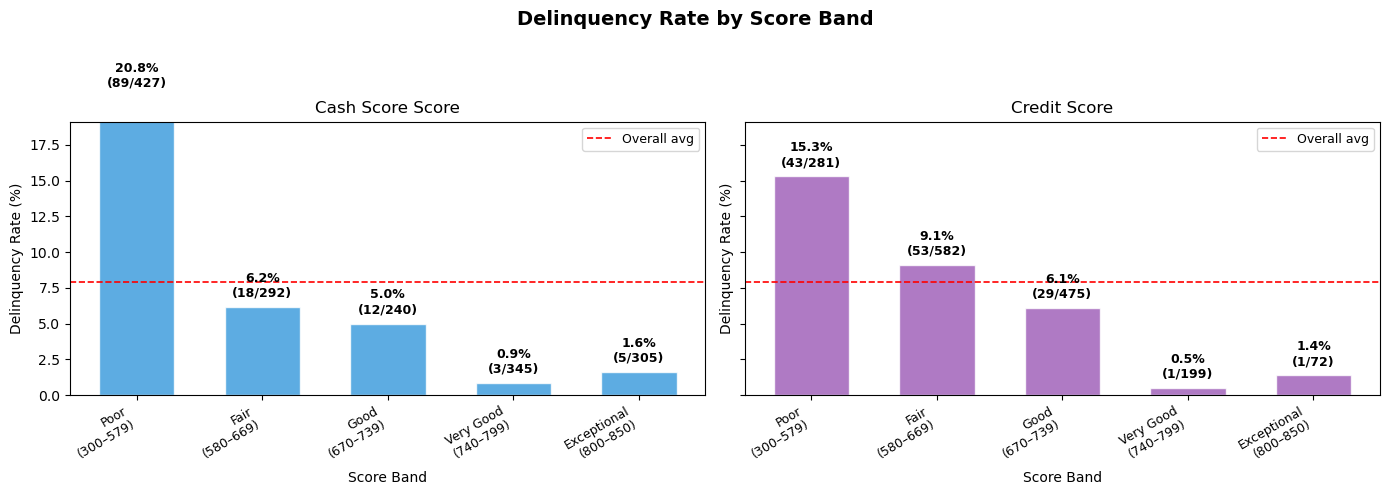


── Cash Score Delinquency by Bin ──
              fico_bin  defaults  total  default_rate
       Poor\n(300–579)        89    427     20.843091
       Fair\n(580–669)        18    292      6.164384
       Good\n(670–739)        12    240      5.000000
  Very Good\n(740–799)         3    345      0.869565
Exceptional\n(800–850)         5    305      1.639344

── Credit Score Delinquency by Bin ──
            credit_bin  defaults  total  default_rate
       Poor\n(300–579)        43    281     15.302491
       Fair\n(580–669)        53    582      9.106529
       Good\n(670–739)        29    475      6.105263
  Very Good\n(740–799)         1    199      0.502513
Exceptional\n(800–850)         1     72      1.388889


In [130]:
import matplotlib.pyplot as plt
import numpy as np

# --- Default rate per bin for both scores ---
fico_default = (
    applicant_summary.groupby("fico_bin", observed=True)["true_label"]
    .agg(defaults="sum", total="count")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
    .reset_index()
)

credit_default = (
    applicant_summary.groupby("credit_bin", observed=True)["true_label"]
    .agg(defaults="sum", total="count")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
    .reset_index()
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Delinquency Rate by Score Band", fontsize=14, fontweight="bold")

for ax, df, title, color in [
    (axes[0], fico_default,   "Cash Score Score",  "#3498db"),
    (axes[1], credit_default, "Credit Score",     "#9b59b6"),
]:
    bars = ax.bar(
        df.iloc[:, 0].astype(str),
        df["default_rate"],
        color=color,
        alpha=0.8,
        edgecolor="white",
        width=0.6
    )

    # Annotate each bar: % rate + raw counts
    for bar, (_, row) in zip(bars, df.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{row['default_rate']:.1f}%\n({int(row['defaults'])}/{int(row['total'])})",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Score Band", fontsize=10)
    ax.set_ylabel("Delinquency Rate (%)", fontsize=10)
    ax.set_xticklabels(df.iloc[:, 0].astype(str), rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, df["default_rate"].max() * 1.25)
    ax.axhline(y=applicant_summary["true_label"].mean() * 100,
               color="red", linestyle="--", linewidth=1.2, label="Overall avg")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n── Cash Score Delinquency by Bin ──")
print(fico_default.to_string(index=False))
print("\n── Credit Score Delinquency by Bin ──")
print(credit_default.to_string(index=False))

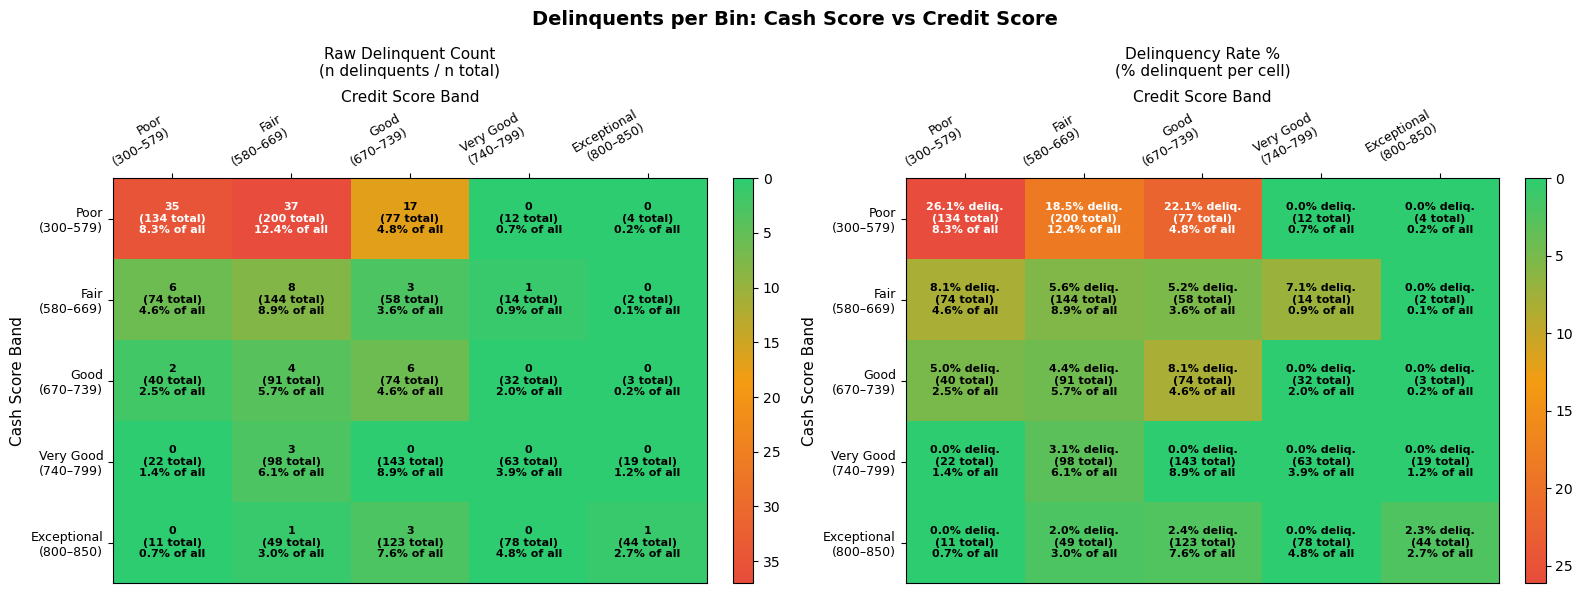

In [131]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Build bin columns if not already present ---
score_bins  = [300, 579, 669, 739, 799, 850]
bin_labels  = ["Poor\n(300–579)", "Fair\n(580–669)", "Good\n(670–739)",
               "Very Good\n(740–799)", "Exceptional\n(800–850)"]

applicant_summary["fico_bin"] = pd.cut(
    applicant_summary["cash_score"], bins=score_bins,
    labels=bin_labels, include_lowest=True
)
applicant_summary["credit_bin"] = pd.cut(
    applicant_summary["credit_score"], bins=score_bins,
    labels=bin_labels, include_lowest=True
)

# --- Build cross-tab matrix: FICO bin (rows) vs Credit bin (cols) ---
# Count of delinquents (true_label == 1) in each cell
delinquents = (
    applicant_summary[applicant_summary["true_label"] == 1]
    .groupby(["fico_bin", "credit_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Total applicants per cell (for rate annotation)
totals = (
    applicant_summary
    .groupby(["fico_bin", "credit_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Delinquency rate per cell
rates = (delinquents / totals.replace(0, np.nan) * 100).fillna(0)

# --- Custom colormap: green (low) → red (high) ---
cmap = LinearSegmentedColormap.from_list("risk", ["#2ecc71", "#f39c12", "#e74c3c"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Delinquents per Bin: Cash Score vs Credit Score", fontsize=14, fontweight="bold")

grand_total = totals.values.sum()

for ax, matrix, anno_matrix, title, fmt in [
    (axes[0], delinquents, totals, "Raw Delinquent Count\n(n delinquents / n total)", "count"),
    (axes[1], rates,       totals, "Delinquency Rate %\n(% delinquent per cell)",     "rate"),
]:
    im = ax.imshow(matrix.values, cmap=cmap, aspect="auto",
                   vmin=0, vmax=matrix.values.max())

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            total_val = anno_matrix.values[i, j]
            cell_val  = matrix.values[i, j]
            pct_of_total = (total_val / grand_total * 100)
            text_color = "white" if cell_val > matrix.values.max() * 0.5 else "black"

            if fmt == "count":
                label = f"{int(cell_val)}\n({int(total_val)} total)\n{pct_of_total:.1f}% of all"
            else:
                label = f"{cell_val:.1f}% deliq.\n({int(total_val)} total)\n{pct_of_total:.1f}% of all"

            ax.text(j, i, label, ha="center", va="center",
                    fontsize=8, color=text_color, fontweight="bold")

    ax.set_xticks(range(len(delinquents.columns)))
    ax.set_yticks(range(len(delinquents.index)))
    ax.set_xticklabels(delinquents.columns, fontsize=9, rotation=30, ha="right")
    ax.set_yticklabels(delinquents.index, fontsize=9)
    ax.set_xlabel("Credit Score Band", fontsize=11)
    ax.set_ylabel("Cash Score Band", fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    # ax.invert_yaxis()  # ← Exceptional at top
    # ax.invert_xaxis()  # ← Exceptional at left
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.invert_yaxis()

plt.tight_layout()
plt.show()

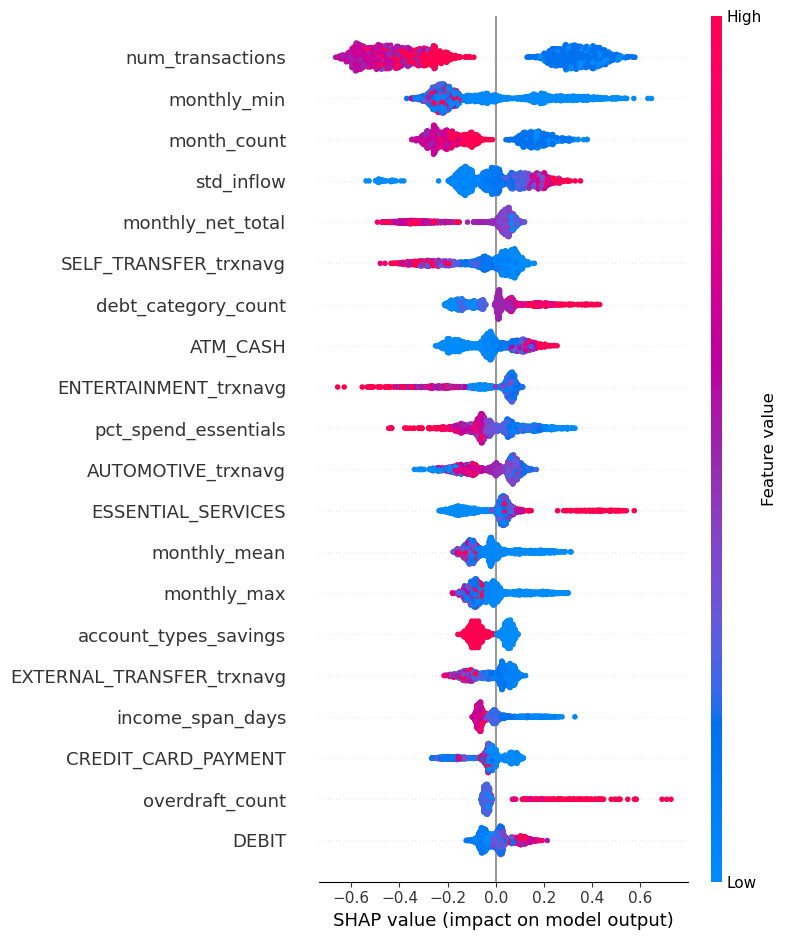

In [132]:
import shap

# If you already computed xgb_shap / lgb_shap earlier, you can reuse them.
# Otherwise compute here:

xgb_explainer = shap.TreeExplainer(xgb_raw)
xgb_shap = xgb_explainer.shap_values(X_test_50_imp)

# Beeswarm summary plot (global)
shap.summary_plot(xgb_shap, X_test_50_imp, max_display=20)

/home/ekw002/.local/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


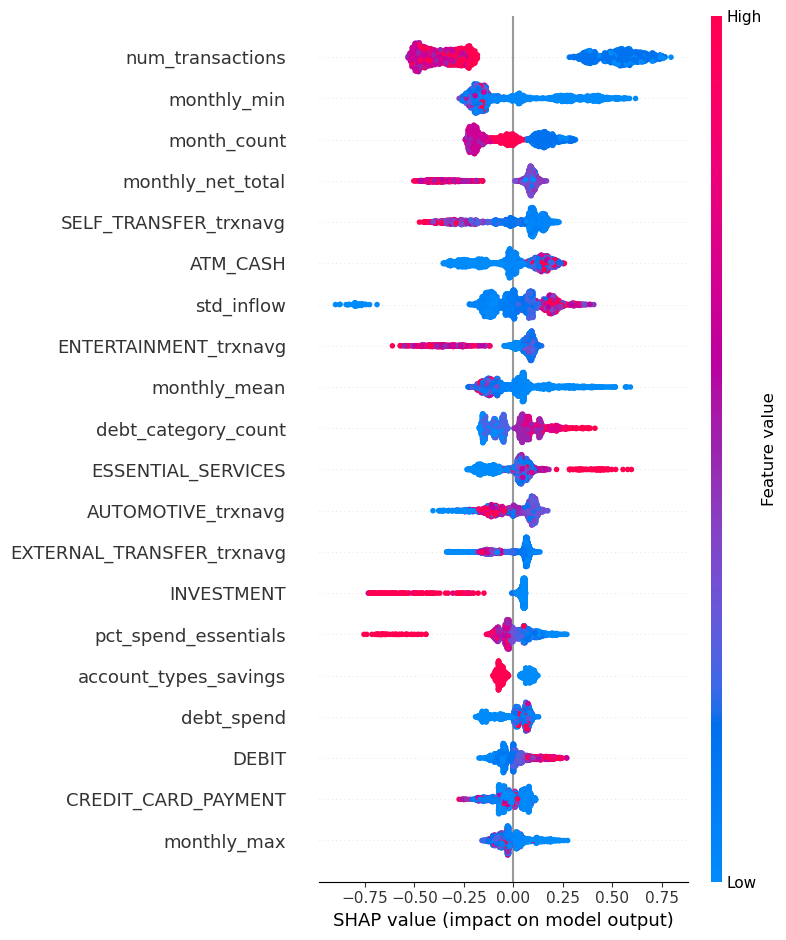

In [133]:
lgb_explainer = shap.TreeExplainer(lgb_raw)
lgb_shap = lgb_explainer.shap_values(X_test_50_imp)

shap.summary_plot(lgb_shap, X_test_50_imp, max_display=20)

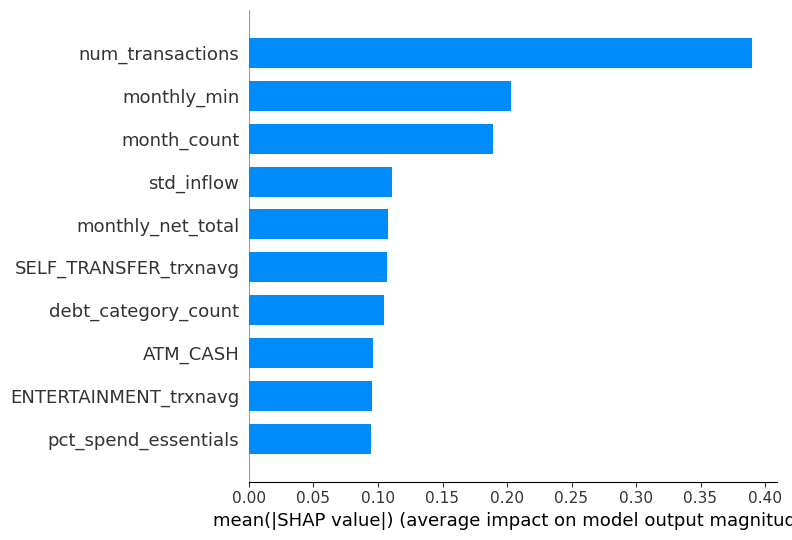

In [134]:
shap.summary_plot(xgb_shap, X_test_50_imp, plot_type="bar", max_display=10)

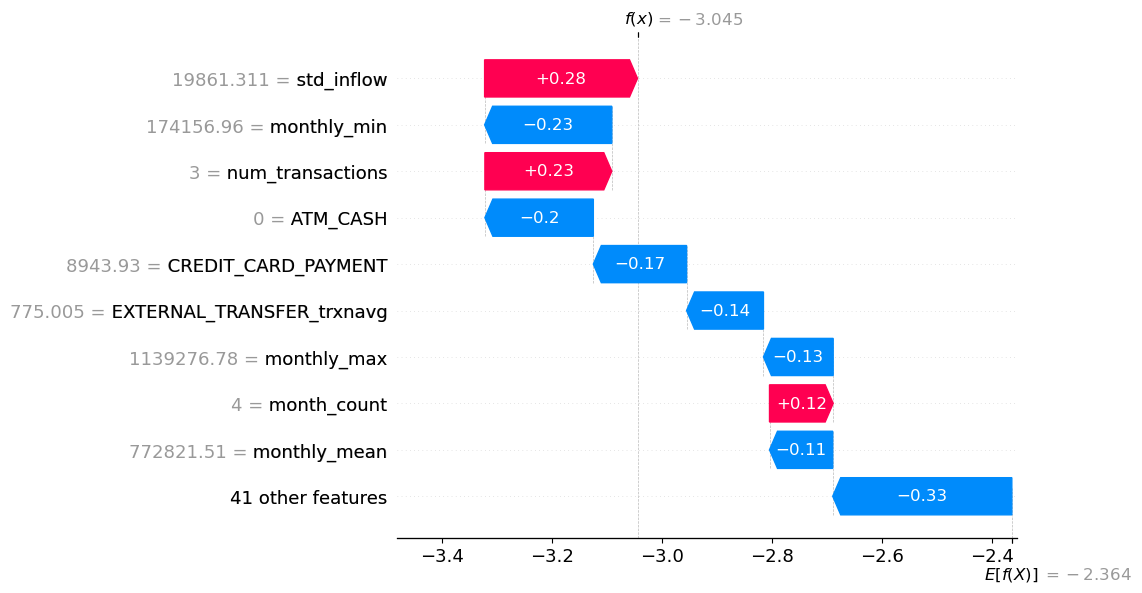

In [135]:
i = 0  # pick a test row
sv = xgb_explainer(X_test_50_imp)          # modern SHAP object
shap.plots.waterfall(sv[i], max_display=10)

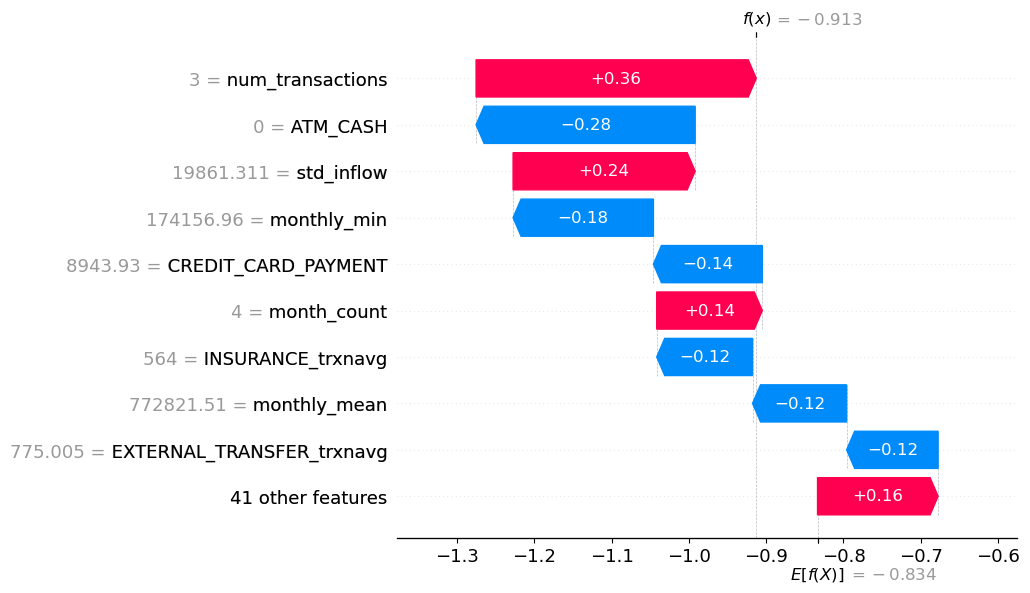

In [136]:
sv_lgb = lgb_explainer(X_test_50_imp)
shap.plots.waterfall(sv_lgb[i], max_display=10)

## filling the validation set

In [137]:
"""
Boosting Pipeline: XGBoost + LightGBM + CatBoost
Modified to work with pre-split train/test data
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    roc_curve, precision_recall_curve, classification_report
)
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier


# ─────────────────────────────────────────────────────────────
# 1. CLASSIFIERS
# ─────────────────────────────────────────────────────────────

def get_classifiers(scale_pos_weight: float = 1.0):
    """
    Returns dict of boosting classifiers.
    scale_pos_weight = n_negative / n_positive (for XGB & LGB)
    """
    return {
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            use_label_encoder=False,
            random_state=42,
            verbosity=0,
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbose=-1,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=0,
        ),
    }


# ─────────────────────────────────────────────────────────────
# 2. SAMPLING STRATEGIES
# ─────────────────────────────────────────────────────────────

SAMPLERS = {
    "No Sampling":      None,
    "SMOTE":            SMOTE(random_state=42),
    "BorderlineSMOTE":  BorderlineSMOTE(random_state=42),
    "ADASYN":           ADASYN(random_state=42),
    "SMOTETomek":       SMOTETomek(random_state=42),
}


# ─────────────────────────────────────────────────────────────
# 3. PREPROCESSING (ADAPTED FOR PRE-SPLIT DATA)
# ─────────────────────────────────────────────────────────────

def preprocess_presplit(X_train, X_test, y_train, y_test):
    """
    Preprocess pre-split train/test data.
    Assumes X_train and X_test are already numeric arrays/DataFrames.
    """
    # Convert to numpy arrays if DataFrames
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.values
    if isinstance(X_test, pd.DataFrame):
        X_test = X_test.values
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    if isinstance(y_test, pd.Series):
        y_test = y_test.values
    
    # Calculate scale_pos_weight for binary classification
    unique_classes = np.unique(y_train)
    if len(unique_classes) == 2:
        counts = np.bincount(y_train.astype(int))
        spw = counts[0] / counts[1]  # majority / minority
    else:
        spw = 1.0  # multi-class, don't use scale_pos_weight
    
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
    print(f"Features: {X_train.shape[1]}")
    print(f"Train class distribution: {np.bincount(y_train.astype(int))}")
    print(f"Test class distribution: {np.bincount(y_test.astype(int))}")
    print(f"scale_pos_weight = {spw:.2f}\n")
    
    return X_train, X_test, y_train, y_test, spw


# ─────────────────────────────────────────────────────────────
# 4. CROSS-VALIDATED EVALUATION ON TRAIN SET
# ─────────────────────────────────────────────────────────────

def cv_evaluate(X_train, y_train, clf, sampler, sampler_name, clf_name, n_splits=5):
    """
    Stratified K-Fold CV on TRAINING SET ONLY.
    Resampling is applied INSIDE each fold to prevent leakage.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        # Scale
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
        
        # Resample train fold only
        if sampler is not None:
            import copy
            s = copy.deepcopy(sampler)
            try:
                X_tr, y_tr = s.fit_resample(X_tr, y_tr)
            except Exception as e:
                print(f"    Sampler failed fold {fold}: {e}")
        
        # Train
        import copy
        model = copy.deepcopy(clf)
        model.fit(X_tr, y_tr)
        
        # Predict
        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)
        
        fold_metrics.append({
            "roc_auc":        roc_auc_score(y_val, y_prob),
            "pr_auc":         average_precision_score(y_val, y_prob),
            "balanced_acc":   balanced_accuracy_score(y_val, y_pred),
            "f1_minority":    f1_score(y_val, y_pred, pos_label=1, zero_division=0),
            "y_val":          y_val,
            "y_prob":         y_prob,
            "y_pred":         y_pred,
        })
    
    # Aggregate
    agg = {
        "Classifier":    clf_name,
        "Sampler":       sampler_name,
        "ROC-AUC":       np.mean([m["roc_auc"]      for m in fold_metrics]),
        "PR-AUC":        np.mean([m["pr_auc"]        for m in fold_metrics]),
        "Balanced Acc":  np.mean([m["balanced_acc"]  for m in fold_metrics]),
        "F1 (minority)": np.mean([m["f1_minority"]   for m in fold_metrics]),
        "ROC-AUC std":   np.std([m["roc_auc"]        for m in fold_metrics]),
        "PR-AUC std":    np.std([m["pr_auc"]          for m in fold_metrics]),
        "_fpr_tpr":      (fold_metrics[-1]["y_val"], fold_metrics[-1]["y_prob"]),
    }
    return agg


# ─────────────────────────────────────────────────────────────
# 5. FINAL TEST EVALUATION
# ─────────────────────────────────────────────────────────────

def test_evaluate(X_train, X_test, y_train, y_test, clf, sampler, clf_name, sampler_name):
    """
    Train on full training set and evaluate on test set.
    """
    import copy
    
    # Scale
    scaler = StandardScaler()
    X_tr_scaled  = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Resample training data if sampler provided
    if sampler is not None:
        s = copy.deepcopy(sampler)
        try:
            X_tr_scaled, y_train_resampled = s.fit_resample(X_tr_scaled, y_train)
        except Exception as e:
            print(f"    Sampler failed on full train: {e}")
            y_train_resampled = y_train
    else:
        y_train_resampled = y_train
    
    # Train on full training set
    model = copy.deepcopy(clf)
    model.fit(X_tr_scaled, y_train_resampled)
    
    # Predict on test set
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)
    
    return {
        "Classifier":    clf_name,
        "Sampler":       sampler_name,
        "Test ROC-AUC":       roc_auc_score(y_test, y_prob),
        "Test PR-AUC":        average_precision_score(y_test, y_prob),
        "Test Balanced Acc":  balanced_accuracy_score(y_test, y_pred),
        "Test F1 (minority)": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "y_test":        y_test,
        "y_prob":        y_prob,
        "y_pred":        y_pred,
        "model":         model,
    }


# ─────────────────────────────────────────────────────────────
# 6. MAIN PIPELINE (MODIFIED FOR PRE-SPLIT DATA)
# ─────────────────────────────────────────────────────────────

def run_boosting_pipeline(
    X_train, X_test, y_train, y_test,
    samplers: dict = None,
    n_splits: int = 5,
    plot: bool = True,
):
    """
    Run boosting pipeline with pre-split train/test data.
    
    Steps:
    1. Cross-validate on training set to find best sampler per classifier
    2. Train on full training set with best config
    3. Evaluate on test set
    """
    # Preprocess
    X_train, X_test, y_train, y_test, spw = preprocess_presplit(
        X_train, X_test, y_train, y_test
    )
    
    classifiers = get_classifiers(scale_pos_weight=spw)
    
    if samplers is None:
        samplers = SAMPLERS
    
    # ═══════════════════════════════════════════════════════════
    # STEP 1: Cross-validation on training set
    # ═══════════════════════════════════════════════════════════
    
    print("\n" + "="*70)
    print("STEP 1: CROSS-VALIDATION ON TRAINING SET")
    print("="*70)
    
    cv_results = []
    
    for clf_name, clf in classifiers.items():
        print(f"\n{'='*55}")
        print(f"  {clf_name}")
        print(f"{'='*55}")
        for sampler_name, sampler in samplers.items():
            print(f"  ↳ {sampler_name} ...", end=" ", flush=True)
            result = cv_evaluate(X_train, y_train, clf, sampler, sampler_name, clf_name, n_splits)
            cv_results.append(result)
            print(f"CV ROC-AUC={result['ROC-AUC']:.4f}  PR-AUC={result['PR-AUC']:.4f}  "
                  f"F1-min={result['F1 (minority)']:.4f}")
    
    # CV Summary
    cv_summary = pd.DataFrame([
        {k: v for k, v in r.items() if not k.startswith("_")}
        for r in cv_results
    ])
    for col in ["ROC-AUC", "PR-AUC", "Balanced Acc", "F1 (minority)"]:
        cv_summary[col] = cv_summary[col].round(4)
    
    print("\n\n" + "="*70)
    print("CV RESULTS TABLE")
    print("="*70)
    print(cv_summary.drop(columns=["ROC-AUC std", "PR-AUC std"]).to_string(index=False))
    
    # Best config per classifier
    print("\n\nBEST CONFIG PER CLASSIFIER (by CV ROC-AUC)")
    print("-"*50)
    best_cv = cv_summary.loc[cv_summary.groupby("Classifier")["ROC-AUC"].idxmax()]
    print(best_cv[["Classifier", "Sampler", "ROC-AUC", "PR-AUC", "F1 (minority)"]].to_string(index=False))
    
    # ═══════════════════════════════════════════════════════════
    # STEP 2: Train on full training set and evaluate on test set
    # ═══════════════════════════════════════════════════════════
    
    print("\n\n" + "="*70)
    print("STEP 2: FINAL TEST SET EVALUATION")
    print("="*70)
    
    test_results = []
    
    for clf_name, clf in classifiers.items():
        print(f"\n{'='*55}")
        print(f"  {clf_name}")
        print(f"{'='*55}")
        for sampler_name, sampler in samplers.items():
            print(f"  ↳ Training with {sampler_name} ...", end=" ", flush=True)
            result = test_evaluate(X_train, X_test, y_train, y_test, clf, sampler, clf_name, sampler_name)
            test_results.append(result)
            print(f"Test ROC-AUC={result['Test ROC-AUC']:.4f}  PR-AUC={result['Test PR-AUC']:.4f}  "
                  f"F1-min={result['Test F1 (minority)']:.4f}")
    
    # Test Summary
    test_summary = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ["y_test", "y_prob", "y_pred", "model"]}
        for r in test_results
    ])
    for col in ["Test ROC-AUC", "Test PR-AUC", "Test Balanced Acc", "Test F1 (minority)"]:
        test_summary[col] = test_summary[col].round(4)
    
    print("\n\n" + "="*70)
    print("TEST SET RESULTS TABLE")
    print("="*70)
    print(test_summary.to_string(index=False))
    
    # Best config on test set
    print("\n\nBEST CONFIG PER CLASSIFIER (by Test ROC-AUC)")
    print("-"*50)
    best_test = test_summary.loc[test_summary.groupby("Classifier")["Test ROC-AUC"].idxmax()]
    print(best_test[["Classifier", "Sampler", "Test ROC-AUC", "Test PR-AUC", "Test F1 (minority)"]].to_string(index=False))
    
    # ═══════════════════════════════════════════════════════════
    # STEP 3: Classification Report for Best Models
    # ═══════════════════════════════════════════════════════════
    
    print("\n\n" + "="*70)
    print("DETAILED CLASSIFICATION REPORTS (Best Config per Classifier)")
    print("="*70)
    
    for _, row in best_test.iterrows():
        clf_name = row["Classifier"]
        sampler_name = row["Sampler"]
        
        # Find the corresponding result
        result = [r for r in test_results if r["Classifier"] == clf_name and r["Sampler"] == sampler_name][0]
        
        print(f"\n{clf_name} + {sampler_name}")
        print("-"*50)
        print(classification_report(result["y_test"], result["y_pred"], 
                                   target_names=["Class 0 (Negative)", "Class 1 (Positive)"],
                                   digits=4))
    
    # Plot
    if plot:
        _plot(cv_results, cv_summary, test_results, test_summary)
    
    return cv_summary, test_summary, cv_results, test_results


# ─────────────────────────────────────────────────────────────
# 7. PLOTS
# ─────────────────────────────────────────────────────────────

def _plot(cv_results, cv_summary, test_results, test_summary):
    classifiers = cv_summary["Classifier"].unique()
    samplers    = cv_summary["Sampler"].unique()
    
    # ══════════════════════════════════════════════════════════
    # PLOT 1: CV vs Test Comparison
    # ══════════════════════════════════════════════════════════
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("CV vs Test Set Performance Comparison", fontsize=14, fontweight="bold")
    
    metrics = ["ROC-AUC", "PR-AUC", "F1 (minority)"]
    test_metric_names = ["Test ROC-AUC", "Test PR-AUC", "Test F1 (minority)"]
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(samplers)))
    
    for ax_idx, (metric, test_metric) in enumerate(zip(metrics, test_metric_names)):
        ax = axes[ax_idx]
        x = np.arange(len(classifiers))
        w = 0.15
        offset = -(len(samplers) - 1) / 2 * w
        
        for i, (sampler, color) in enumerate(zip(samplers, colors)):
            # CV scores
            cv_vals = [
                cv_summary.loc[(cv_summary["Classifier"] == c) & (cv_summary["Sampler"] == sampler), metric].values[0]
                for c in classifiers
            ]
            # Test scores
            test_vals = [
                test_summary.loc[(test_summary["Classifier"] == c) & (test_summary["Sampler"] == sampler), test_metric].values[0]
                for c in classifiers
            ]
            
            # Plot CV as bars
            ax.bar(x + offset + i * w, cv_vals, w, 
                   label=f"{sampler} (CV)", color=color, alpha=0.6)
            # Plot Test as points
            ax.scatter(x + offset + i * w, test_vals, 
                      color=color, s=80, marker='D', edgecolors='black', linewidths=1.5,
                      zorder=3)
        
        ax.set_xticks(x)
        ax.set_xticklabels(classifiers, fontsize=10)
        ax.set_title(f"{metric.replace('F1 (minority)', 'F1-Score')}", fontsize=11, fontweight="bold")
        ax.set_ylim(0.5, 1.02)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        ax.grid(axis="y", alpha=0.3)
    
    # Add legend explanation
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='gray', alpha=0.6, label='CV Score (bars)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', 
               markersize=8, markeredgecolor='black', label='Test Score (diamonds)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
               ncol=2, fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.savefig("boosting_cv_vs_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # ══════════════════════════════════════════════════════════
    # PLOT 2: ROC Curves (Test Set)
    # ══════════════════════════════════════════════════════════
    
    fig2, axes2 = plt.subplots(1, len(classifiers), figsize=(6 * len(classifiers), 5))
    if len(classifiers) == 1:
        axes2 = [axes2]
    
    for ax, clf_name in zip(axes2, classifiers):
        subset = [r for r in test_results if r["Classifier"] == clf_name]
        for r in subset:
            y_test = r["y_test"]
            y_prob = r["y_prob"]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            ax.plot(fpr, tpr, label=f"{r['Sampler']} (AUC={r['Test ROC-AUC']:.3f})", linewidth=2)
        ax.plot([0, 1], [0, 1], "k--", linewidth=1)
        ax.set_title(f"ROC Curve — {clf_name} (Test Set)", fontweight="bold")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("boosting_test_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # ══════════════════════════════════════════════════════════
    # PLOT 3: PR Curves (Test Set)
    # ══════════════════════════════════════════════════════════
    
    fig3, axes3 = plt.subplots(1, len(classifiers), figsize=(6 * len(classifiers), 5))
    if len(classifiers) == 1:
        axes3 = [axes3]
    
    for ax, clf_name in zip(axes3, classifiers):
        subset = [r for r in test_results if r["Classifier"] == clf_name]
        for r in subset:
            y_test = r["y_test"]
            y_prob = r["y_prob"]
            prec, rec, _ = precision_recall_curve(y_test, y_prob)
            ax.plot(rec, prec, label=f"{r['Sampler']} (AUC={r['Test PR-AUC']:.3f})", linewidth=2)
        ax.set_title(f"Precision-Recall Curve — {clf_name} (Test Set)", fontweight="bold")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("boosting_test_pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("\nPlots saved:")
    print("  - boosting_cv_vs_test.png")
    print("  - boosting_test_roc_curves.png")
    print("  - boosting_test_pr_curves.png")


# ─────────────────────────────────────────────────────────────
# 8. USAGE
# ─────────────────────────────────────────────────────────────

# Run the pipeline with your data:
cv_summary, test_summary, cv_results, test_results = run_boosting_pipeline(
    X_train=X_train_50_imp,
    X_test=X_test_50_imp,
    y_train=y_train,
    y_test=y_test,
    n_splits=5,
    plot=True,
)

ImportError: cannot import name 'intp' from 'numpy._core' (/home/ekw002/.local/lib/python3.11/site-packages/numpy/_core/__init__.py)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, make_scorer
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# -------------------------
# Calculate class imbalance ratio
# -------------------------
def calculate_class_ratio(y):
    """Calculate the ratio of majority to minority class"""
    unique, counts = np.unique(y, return_counts=True)
    class_counts = dict(zip(unique, counts))
    
    # Assuming binary classification: 0 (majority), 1 (minority)
    n_negative = class_counts[0]
    n_positive = class_counts[1]
    
    ratio = n_negative / n_positive
    
    print(f"Class 0 (Negative): {n_negative} samples ({n_negative/(n_negative+n_positive)*100:.1f}%)")
    print(f"Class 1 (Positive): {n_positive} samples ({n_positive/(n_negative+n_positive)*100:.1f}%)")
    print(f"Imbalance Ratio: {ratio:.2f}:1")
    print(f"Suggested scale_pos_weight: {ratio:.2f}")
    
    return ratio

# Calculate from your training data
default_weight = calculate_class_ratio(y_train)

# -------------------------
# Grid Search Function
# -------------------------
def grid_search_scale_pos_weight(X_train, y_train, model_type='xgboost', 
                                  weight_range=None, cv_folds=5):
    """
    Find optimal scale_pos_weight through grid search
    
    Parameters:
    -----------
    X_train : array-like or DataFrame
        Training features
    y_train : array-like or Series
        Training labels
    model_type : str
        'xgboost', 'lightgbm', or 'catboost'
    weight_range : list
        Range of weights to test. If None, uses sensible defaults around class ratio
    cv_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results_df : DataFrame
        Results for each weight tested
    best_weight : float
        Optimal scale_pos_weight
    """
    
    # ⭐ FIX: Convert to NumPy arrays to avoid indexing issues
    if hasattr(X_train, 'values'):  # If DataFrame
        X_train_np = X_train.values
    else:
        X_train_np = np.array(X_train)
    
    if hasattr(y_train, 'values'):  # If Series
        y_train_np = y_train.values
    else:
        y_train_np = np.array(y_train)
    
    # Default weight range: test around the class imbalance ratio
    if weight_range is None:
        class_ratio = np.sum(y_train_np == 0) / np.sum(y_train_np == 1)
        weight_range = np.linspace(
            class_ratio * 0.5,  # 50% of ratio
            class_ratio * 1.5,  # 150% of ratio
            20  # 20 points to test
        )
    
    results = []
    
    print(f"\n{'='*60}")
    print(f"Testing {len(weight_range)} different scale_pos_weight values")
    print(f"{'='*60}\n")
    
    # Stratified K-Fold for imbalanced data
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    for weight in weight_range:
        print(f"Testing scale_pos_weight = {weight:.2f}...", end=" ")
        
        # Initialize model based on type
        if model_type == 'xgboost':
            model = xgb.XGBClassifier(
                scale_pos_weight=weight,
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                eval_metric='logloss'
            )
        elif model_type == 'lightgbm':
            model = lgb.LGBMClassifier(
                scale_pos_weight=weight,
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=-1
            )
        elif model_type == 'catboost':
            model = CatBoostClassifier(
                scale_pos_weight=weight,
                iterations=100,
                depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=False
            )
        else:
            raise ValueError("model_type must be 'xgboost', 'lightgbm', or 'catboost'")
        
        # Calculate multiple metrics via cross-validation
        roc_auc_scores = []
        f1_scores = []
        
        # ⭐ FIX: Use NumPy arrays for indexing
        for train_idx, val_idx in cv.split(X_train_np, y_train_np):
            X_tr, X_val = X_train_np[train_idx], X_train_np[val_idx]
            y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]
            
            # Train model
            model.fit(X_tr, y_tr)
            
            # Predict probabilities and classes
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            y_pred = model.predict(X_val)
            
            # Calculate metrics
            roc_auc = roc_auc_score(y_val, y_pred_proba)
            f1 = f1_score(y_val, y_pred)
            
            roc_auc_scores.append(roc_auc)
            f1_scores.append(f1)
        
        # Average across folds
        avg_roc_auc = np.mean(roc_auc_scores)
        avg_f1 = np.mean(f1_scores)
        
        print(f"ROC-AUC: {avg_roc_auc:.4f}, F1: {avg_f1:.4f}")
        
        results.append({
            'scale_pos_weight': weight,
            'roc_auc_mean': avg_roc_auc,
            'roc_auc_std': np.std(roc_auc_scores),
            'f1_mean': avg_f1,
            'f1_std': np.std(f1_scores)
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best weight by ROC-AUC
    best_idx = results_df['roc_auc_mean'].idxmax()
    best_weight = results_df.loc[best_idx, 'scale_pos_weight']
    best_roc_auc = results_df.loc[best_idx, 'roc_auc_mean']
    best_f1 = results_df.loc[best_idx, 'f1_mean']
    
    print(f"\n{'='*60}")
    print(f"BEST SCALE_POS_WEIGHT: {best_weight:.2f}")
    print(f"  → ROC-AUC: {best_roc_auc:.4f}")
    print(f"  → F1-Score: {best_f1:.4f}")
    print(f"{'='*60}\n")
    
    return results_df, best_weight

# -------------------------
# Visualization Function
# -------------------------
def plot_weight_search_results(results_df, default_weight=None):
    """Plot the results of scale_pos_weight search"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: ROC-AUC vs scale_pos_weight
    axes[0].plot(results_df['scale_pos_weight'], results_df['roc_auc_mean'], 
                 marker='o', linewidth=2, markersize=6, label='ROC-AUC')
    axes[0].fill_between(
        results_df['scale_pos_weight'],
        results_df['roc_auc_mean'] - results_df['roc_auc_std'],
        results_df['roc_auc_mean'] + results_df['roc_auc_std'],
        alpha=0.2
    )
    
    # Mark best ROC-AUC
    best_idx = results_df['roc_auc_mean'].idxmax()
    best_weight = results_df.loc[best_idx, 'scale_pos_weight']
    best_roc = results_df.loc[best_idx, 'roc_auc_mean']
    axes[0].scatter(best_weight, best_roc, color='red', s=200, 
                    zorder=5, label=f'Best: {best_weight:.2f}')
    
    # Mark default weight if provided
    if default_weight is not None:
        axes[0].axvline(default_weight, color='green', linestyle='--', 
                       label=f'Default: {default_weight:.2f}', linewidth=2)
    
    axes[0].set_xlabel('scale_pos_weight', fontsize=12)
    axes[0].set_ylabel('ROC-AUC Score', fontsize=12)
    axes[0].set_title('ROC-AUC vs scale_pos_weight', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: F1-Score vs scale_pos_weight
    axes[1].plot(results_df['scale_pos_weight'], results_df['f1_mean'], 
                 marker='s', linewidth=2, markersize=6, color='orange', label='F1-Score')
    axes[1].fill_between(
        results_df['scale_pos_weight'],
        results_df['f1_mean'] - results_df['f1_std'],
        results_df['f1_mean'] + results_df['f1_std'],
        alpha=0.2, color='orange'
    )
    
    # Mark best F1
    best_f1_idx = results_df['f1_mean'].idxmax()
    best_f1_weight = results_df.loc[best_f1_idx, 'scale_pos_weight']
    best_f1 = results_df.loc[best_f1_idx, 'f1_mean']
    axes[1].scatter(best_f1_weight, best_f1, color='red', s=200, 
                    zorder=5, label=f'Best: {best_f1_weight:.2f}')
    
    # Mark default weight if provided
    if default_weight is not None:
        axes[1].axvline(default_weight, color='green', linestyle='--', 
                       label=f'Default: {default_weight:.2f}', linewidth=2)
    
    axes[1].set_xlabel('scale_pos_weight', fontsize=12)
    axes[1].set_ylabel('F1-Score', fontsize=12)
    axes[1].set_title('F1-Score vs scale_pos_weight', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig


# -------------------------
# USAGE EXAMPLE
# -------------------------

# Run grid search for XGBoost
results_xgb, best_weight_xgb = grid_search_scale_pos_weight(
    X_train, y_train, 
    model_type='xgboost',
    weight_range=None,  # Auto-generate range around class ratio
    cv_folds=5
)

# Plot results
plot_weight_search_results(results_xgb, default_weight=default_weight)

# Display top 5 configurations
print("\nTop 5 Configurations by ROC-AUC:")
print(results_xgb.nlargest(5, 'roc_auc_mean')[['scale_pos_weight', 'roc_auc_mean', 'f1_mean']])

In [ ]:
def fine_tune_scale_pos_weight(X_train, y_train, initial_weight, 
                                model_type='xgboost', search_range=0.2, 
                                n_points=50):
    """
    Fine-tune around an initial weight estimate
    
    Parameters:
    -----------
    initial_weight : float
        Starting point (e.g., class ratio or result from coarse search)
    search_range : float
        How far to search around initial_weight (as fraction)
    n_points : int
        Number of points to test
    """
    
    # Create fine-grained range
    lower = initial_weight * (1 - search_range)
    upper = initial_weight * (1 + search_range)
    weight_range = np.linspace(lower, upper, n_points)
    
    print(f"Fine-tuning around {initial_weight:.2f}")
    print(f"Testing range: [{lower:.2f}, {upper:.2f}]")
    
    results_df, best_weight = grid_search_scale_pos_weight(
        X_train, y_train,
        model_type=model_type,
        weight_range=weight_range,
        cv_folds=5
    )
    
    return results_df, best_weight


# Example: Fine-tune around class ratio
results_fine, best_weight_fine = fine_tune_scale_pos_weight(
    X_train, y_train,
    initial_weight=10.63,  # Your calculated ratio
    model_type='xgboost',
    search_range=0.3,  # Search ±30% around 10.63
    n_points=50
)

plot_weight_search_results(results_fine, default_weight=10.63)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# -------------------------
# Helper Function
# -------------------------
def ensure_numpy(data):
    """Convert DataFrame/Series to NumPy array"""
    if hasattr(data, 'values'):
        return data.values
    return np.array(data)


# -------------------------
# Calculate Class Ratio
# -------------------------
def calculate_class_ratio(y):
    """Calculate the ratio of majority to minority class"""
    y_np = ensure_numpy(y)
    unique, counts = np.unique(y_np, return_counts=True)
    class_counts = dict(zip(unique, counts))
    
    n_negative = class_counts[0]
    n_positive = class_counts[1]
    ratio = n_negative / n_positive
    
    print(f"Class 0 (Negative): {n_negative} samples ({n_negative/(n_negative+n_positive)*100:.1f}%)")
    print(f"Class 1 (Positive): {n_positive} samples ({n_positive/(n_negative+n_positive)*100:.1f}%)")
    print(f"Imbalance Ratio: {ratio:.2f}:1")
    print(f"Suggested scale_pos_weight: {ratio:.2f}")
    
    return ratio


# -------------------------
# Grid Search with Pipeline
# -------------------------
def grid_search_scale_pos_weight_pipeline(X_train, y_train, 
                                          base_pipeline=None,
                                          weight_range=None, 
                                          cv_folds=5,
                                          metric='roc_auc'):
    """
    Find optimal scale_pos_weight for LightGBM Pipeline
    
    Parameters:
    -----------
    X_train : array-like or DataFrame
        Training features
    y_train : array-like or Series
        Training labels
    base_pipeline : Pipeline (optional)
        Your existing pipeline. If None, creates default.
    weight_range : list
        Range of weights to test. If None, auto-generates.
    cv_folds : int
        Number of cross-validation folds
    metric : str
        'roc_auc' or 'pr_auc' (precision-recall AUC)
    
    Returns:
    --------
    results_df : DataFrame
        Results for each weight tested
    best_weight : float
        Optimal scale_pos_weight
    """
    
    # Convert to NumPy arrays
    X_train_np = ensure_numpy(X_train)
    y_train_np = ensure_numpy(y_train)
    
    # Default weight range
    if weight_range is None:
        class_ratio = np.sum(y_train_np == 0) / np.sum(y_train_np == 1)
        weight_range = np.linspace(
            class_ratio * 0.5,
            class_ratio * 1.5,
            20
        )
    
    results = []
    
    print(f"\n{'='*70}")
    print(f"Testing {len(weight_range)} different scale_pos_weight values")
    print(f"Using {cv_folds}-fold Cross-Validation")
    print(f"{'='*70}\n")
    
    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    for weight in weight_range:
        print(f"Testing scale_pos_weight = {weight:.2f}...", end=" ")
        
        # Create pipeline with current weight
        if base_pipeline is not None:
            # Clone your pipeline structure
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("clf", LGBMClassifier(
                    random_state=42,
                    objective="binary",
                    class_weight="balanced",
                    scale_pos_weight=weight,  # ⭐ Add scale_pos_weight
                    verbosity=-1,
                    n_estimators=900,
                    max_depth=3,
                    learning_rate=0.01,
                    subsample=0.7,
                    colsample_bytree=0.85,
                    num_leaves=15,
                    min_child_samples=80,
                    reg_alpha=0.01,
                    reg_lambda=2.0
                ))
            ])
        else:
            # Simple default pipeline
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("clf", LGBMClassifier(
                    scale_pos_weight=weight,
                    random_state=42,
                    verbosity=-1
                ))
            ])
        
        # Cross-validation metrics
        roc_auc_scores = []
        pr_auc_scores = []
        f1_scores = []
        
        for train_idx, val_idx in cv.split(X_train_np, y_train_np):
            X_tr, X_val = X_train_np[train_idx], X_train_np[val_idx]
            y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]
            
            # Train pipeline
            pipeline.fit(X_tr, y_tr)
            
            # Predict
            y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
            y_pred = pipeline.predict(X_val)
            
            # Calculate metrics
            roc_auc = roc_auc_score(y_val, y_pred_proba)
            
            # PR-AUC (better for imbalanced data)
            precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
            pr_auc = auc(recall, precision)
            
            f1 = f1_score(y_val, y_pred)
            
            roc_auc_scores.append(roc_auc)
            pr_auc_scores.append(pr_auc)
            f1_scores.append(f1)
        
        # Average across folds
        avg_roc_auc = np.mean(roc_auc_scores)
        avg_pr_auc = np.mean(pr_auc_scores)
        avg_f1 = np.mean(f1_scores)
        
        print(f"ROC-AUC: {avg_roc_auc:.4f}, PR-AUC: {avg_pr_auc:.4f}, F1: {avg_f1:.4f}")
        
        results.append({
            'scale_pos_weight': weight,
            'roc_auc_mean': avg_roc_auc,
            'roc_auc_std': np.std(roc_auc_scores),
            'pr_auc_mean': avg_pr_auc,
            'pr_auc_std': np.std(pr_auc_scores),
            'f1_mean': avg_f1,
            'f1_std': np.std(f1_scores)
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best weight
    if metric == 'roc_auc':
        best_idx = results_df['roc_auc_mean'].idxmax()
        metric_col = 'roc_auc_mean'
    elif metric == 'pr_auc':
        best_idx = results_df['pr_auc_mean'].idxmax()
        metric_col = 'pr_auc_mean'
    else:
        raise ValueError("metric must be 'roc_auc' or 'pr_auc'")
    
    best_weight = results_df.loc[best_idx, 'scale_pos_weight']
    best_score = results_df.loc[best_idx, metric_col]
    best_f1 = results_df.loc[best_idx, 'f1_mean']
    
    print(f"\n{'='*70}")
    print(f"BEST SCALE_POS_WEIGHT: {best_weight:.2f}")
    print(f"  → ROC-AUC: {results_df.loc[best_idx, 'roc_auc_mean']:.4f}")
    print(f"  → PR-AUC: {results_df.loc[best_idx, 'pr_auc_mean']:.4f}")
    print(f"  → F1-Score: {best_f1:.4f}")
    print(f"{'='*70}\n")
    
    return results_df, best_weight


# -------------------------
# Visualization
# -------------------------
def plot_weight_search_results(results_df, default_weight=None):
    """Plot the results of scale_pos_weight search"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: ROC-AUC
    axes[0, 0].plot(results_df['scale_pos_weight'], results_df['roc_auc_mean'], 
                    marker='o', linewidth=2, markersize=6, color='blue')
    axes[0, 0].fill_between(
        results_df['scale_pos_weight'],
        results_df['roc_auc_mean'] - results_df['roc_auc_std'],
        results_df['roc_auc_mean'] + results_df['roc_auc_std'],
        alpha=0.2, color='blue'
    )
    
    best_idx = results_df['roc_auc_mean'].idxmax()
    best_weight = results_df.loc[best_idx, 'scale_pos_weight']
    best_roc = results_df.loc[best_idx, 'roc_auc_mean']
    axes[0, 0].scatter(best_weight, best_roc, color='red', s=200, 
                       zorder=5, marker='*', label=f'Best: {best_weight:.2f}')
    
    if default_weight:
        axes[0, 0].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Default: {default_weight:.2f}', linewidth=2)
    
    axes[0, 0].set_xlabel('scale_pos_weight', fontsize=11)
    axes[0, 0].set_ylabel('ROC-AUC', fontsize=11)
    axes[0, 0].set_title('ROC-AUC vs scale_pos_weight', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: PR-AUC
    axes[0, 1].plot(results_df['scale_pos_weight'], results_df['pr_auc_mean'], 
                    marker='s', linewidth=2, markersize=6, color='orange')
    axes[0, 1].fill_between(
        results_df['scale_pos_weight'],
        results_df['pr_auc_mean'] - results_df['pr_auc_std'],
        results_df['pr_auc_mean'] + results_df['pr_auc_std'],
        alpha=0.2, color='orange'
    )
    
    best_pr_idx = results_df['pr_auc_mean'].idxmax()
    best_pr_weight = results_df.loc[best_pr_idx, 'scale_pos_weight']
    best_pr = results_df.loc[best_pr_idx, 'pr_auc_mean']
    axes[0, 1].scatter(best_pr_weight, best_pr, color='red', s=200, 
                       zorder=5, marker='*', label=f'Best: {best_pr_weight:.2f}')
    
    if default_weight:
        axes[0, 1].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Default: {default_weight:.2f}', linewidth=2)
    
    axes[0, 1].set_xlabel('scale_pos_weight', fontsize=11)
    axes[0, 1].set_ylabel('PR-AUC', fontsize=11)
    axes[0, 1].set_title('PR-AUC vs scale_pos_weight', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: F1-Score
    axes[1, 0].plot(results_df['scale_pos_weight'], results_df['f1_mean'], 
                    marker='D', linewidth=2, markersize=6, color='green')
    axes[1, 0].fill_between(
        results_df['scale_pos_weight'],
        results_df['f1_mean'] - results_df['f1_std'],
        results_df['f1_mean'] + results_df['f1_std'],
        alpha=0.2, color='green'
    )
    
    best_f1_idx = results_df['f1_mean'].idxmax()
    best_f1_weight = results_df.loc[best_f1_idx, 'scale_pos_weight']
    best_f1 = results_df.loc[best_f1_idx, 'f1_mean']
    axes[1, 0].scatter(best_f1_weight, best_f1, color='red', s=200, 
                       zorder=5, marker='*', label=f'Best: {best_f1_weight:.2f}')
    
    if default_weight:
        axes[1, 0].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Default: {default_weight:.2f}', linewidth=2)
    
    axes[1, 0].set_xlabel('scale_pos_weight', fontsize=11)
    axes[1, 0].set_ylabel('F1-Score', fontsize=11)
    axes[1, 0].set_title('F1-Score vs scale_pos_weight', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: All Metrics Together (Normalized)
    from sklearn.preprocessing import MinMaxScaler
    
    scaler = MinMaxScaler()
    normalized_metrics = pd.DataFrame({
        'scale_pos_weight': results_df['scale_pos_weight'],
        'ROC-AUC': scaler.fit_transform(results_df[['roc_auc_mean']]).flatten(),
        'PR-AUC': scaler.fit_transform(results_df[['pr_auc_mean']]).flatten(),
        'F1': scaler.fit_transform(results_df[['f1_mean']]).flatten()
    })
    
    axes[1, 1].plot(normalized_metrics['scale_pos_weight'], normalized_metrics['ROC-AUC'], 
                    marker='o', label='ROC-AUC', linewidth=2)
    axes[1, 1].plot(normalized_metrics['scale_pos_weight'], normalized_metrics['PR-AUC'], 
                    marker='s', label='PR-AUC', linewidth=2)
    axes[1, 1].plot(normalized_metrics['scale_pos_weight'], normalized_metrics['F1'], 
                    marker='D', label='F1', linewidth=2)
    
    if default_weight:
        axes[1, 1].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Default: {default_weight:.2f}', linewidth=2, alpha=0.7)
    
    axes[1, 1].set_xlabel('scale_pos_weight', fontsize=11)
    axes[1, 1].set_ylabel('Normalized Score', fontsize=11)
    axes[1, 1].set_title('All Metrics (Normalized)', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig


# -------------------------
# USAGE EXAMPLE
# -------------------------

# Step 1: Calculate class ratio
print("Step 1: Analyzing class distribution...")
class_ratio = calculate_class_ratio(y_train)

# Step 2: Define your pipeline (or pass None to use it as base)
lgb_pipeline_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LGBMClassifier(
        random_state=42,
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        n_estimators=900,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.85,
        num_leaves=15,
        min_child_samples=80,
        reg_alpha=0.01,
        reg_lambda=2.0
    ))
])

# Step 3: Run grid search
print("\nStep 2: Grid search for optimal scale_pos_weight...")
results, best_weight = grid_search_scale_pos_weight_pipeline(
    X_train, y_train,
    base_pipeline=lgb_pipeline_base,
    weight_range=None,  # Auto-generate around class ratio
    cv_folds=5,
    metric='pr_auc'  # Use PR-AUC for imbalanced data
)

# Step 4: Visualize results
plot_weight_search_results(results, default_weight=class_ratio)

# Step 5: Display top configurations
print("\n" + "="*70)
print("Top 5 Configurations:")
print("="*70)
print(results.nlargest(5, 'pr_auc_mean')[['scale_pos_weight', 'roc_auc_mean', 'pr_auc_mean', 'f1_mean']])

# Step 6: Create final model with optimal weight
print(f"\n{'='*70}")
print("FINAL MODEL WITH OPTIMAL WEIGHT")
print(f"{'='*70}")

lgb_final_optimized = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LGBMClassifier(
        random_state=42,
        objective="binary",
        class_weight="balanced",
        scale_pos_weight=best_weight,  # ⭐ OPTIMAL WEIGHT
        verbosity=-1,
        n_estimators=900,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.85,
        num_leaves=15,
        min_child_samples=80,
        reg_alpha=0.01,
        reg_lambda=2.0
    ))
])

print(f"Optimal scale_pos_weight: {best_weight:.2f}")
print(f"Expected PR-AUC: {results.loc[results['scale_pos_weight'] == best_weight, 'pr_auc_mean'].values[0]:.4f}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# -------------------------
# Helper Function
# -------------------------
def ensure_numpy(data):
    """Convert DataFrame/Series to NumPy array"""
    if hasattr(data, 'values'):
        return data.values
    return np.array(data)


# -------------------------
# Calculate Class Ratio
# -------------------------
def calculate_class_ratio(y):
    """Calculate the ratio of majority to minority class"""
    y_np = ensure_numpy(y)
    unique, counts = np.unique(y_np, return_counts=True)
    class_counts = dict(zip(unique, counts))
    
    n_negative = class_counts[0]
    n_positive = class_counts[1]
    ratio = n_negative / n_positive
    
    print(f"Class 0 (Negative): {n_negative} samples ({n_negative/(n_negative+n_positive)*100:.1f}%)")
    print(f"Class 1 (Positive): {n_positive} samples ({n_positive/(n_negative+n_positive)*100:.1f}%)")
    print(f"Imbalance Ratio: {ratio:.2f}:1")
    print(f"Suggested scale_pos_weight: {ratio:.2f}")
    
    return ratio


# -------------------------
# Grid Search for XGBoost Pipeline
# -------------------------
def grid_search_xgboost_scale_pos_weight(X_train, y_train, 
                                         weight_range=None, 
                                         cv_folds=5,
                                         metric='pr_auc'):
    """
    Find optimal scale_pos_weight for XGBoost Pipeline
    
    Parameters:
    -----------
    X_train : array-like or DataFrame
        Training features
    y_train : array-like or Series
        Training labels
    weight_range : list
        Range of weights to test. If None, auto-generates.
    cv_folds : int
        Number of cross-validation folds
    metric : str
        'roc_auc' or 'pr_auc' (precision-recall AUC)
    
    Returns:
    --------
    results_df : DataFrame
        Results for each weight tested
    best_weight : float
        Optimal scale_pos_weight
    """
    
    # Convert to NumPy arrays
    X_train_np = ensure_numpy(X_train)
    y_train_np = ensure_numpy(y_train)
    
    # Default weight range
    if weight_range is None:
        class_ratio = np.sum(y_train_np == 0) / np.sum(y_train_np == 1)
        weight_range = np.linspace(
            class_ratio * 0.5,
            class_ratio * 1.5,
            20
        )
    
    results = []
    
    print(f"\n{'='*70}")
    print(f"Testing {len(weight_range)} different scale_pos_weight values")
    print(f"Using {cv_folds}-fold Cross-Validation")
    print(f"{'='*70}\n")
    
    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    for weight in weight_range:
        print(f"Testing scale_pos_weight = {weight:.2f}...", end=" ")
        
        # Create XGBoost pipeline with current weight
        xgb_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                random_state=42,
                eval_metric="auc",
                tree_method="hist",
                scale_pos_weight=weight,  # ⭐ Test this weight
                n_estimators=600,
                max_depth=4,
                learning_rate=0.01,
                subsample=0.85,
                colsample_bytree=0.7,
                min_child_weight=3,
                gamma=0,
                reg_alpha=0,
                reg_lambda=0.5
            ))
        ])
        
        # Cross-validation metrics
        roc_auc_scores = []
        pr_auc_scores = []
        f1_scores = []
        
        for train_idx, val_idx in cv.split(X_train_np, y_train_np):
            X_tr, X_val = X_train_np[train_idx], X_train_np[val_idx]
            y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]
            
            # Train pipeline
            xgb_pipeline.fit(X_tr, y_tr)
            
            # Predict
            y_pred_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
            y_pred = xgb_pipeline.predict(X_val)
            
            # Calculate metrics
            roc_auc = roc_auc_score(y_val, y_pred_proba)
            
            # PR-AUC (better for imbalanced data)
            precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
            pr_auc = auc(recall, precision)
            
            f1 = f1_score(y_val, y_pred)
            
            roc_auc_scores.append(roc_auc)
            pr_auc_scores.append(pr_auc)
            f1_scores.append(f1)
        
        # Average across folds
        avg_roc_auc = np.mean(roc_auc_scores)
        avg_pr_auc = np.mean(pr_auc_scores)
        avg_f1 = np.mean(f1_scores)
        
        print(f"ROC-AUC: {avg_roc_auc:.4f}, PR-AUC: {avg_pr_auc:.4f}, F1: {avg_f1:.4f}")
        
        results.append({
            'scale_pos_weight': weight,
            'roc_auc_mean': avg_roc_auc,
            'roc_auc_std': np.std(roc_auc_scores),
            'pr_auc_mean': avg_pr_auc,
            'pr_auc_std': np.std(pr_auc_scores),
            'f1_mean': avg_f1,
            'f1_std': np.std(f1_scores)
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best weight
    if metric == 'roc_auc':
        best_idx = results_df['roc_auc_mean'].idxmax()
        metric_col = 'roc_auc_mean'
    elif metric == 'pr_auc':
        best_idx = results_df['pr_auc_mean'].idxmax()
        metric_col = 'pr_auc_mean'
    else:
        raise ValueError("metric must be 'roc_auc' or 'pr_auc'")
    
    best_weight = results_df.loc[best_idx, 'scale_pos_weight']
    
    print(f"\n{'='*70}")
    print(f"BEST SCALE_POS_WEIGHT: {best_weight:.2f}")
    print(f"  → ROC-AUC: {results_df.loc[best_idx, 'roc_auc_mean']:.4f}")
    print(f"  → PR-AUC: {results_df.loc[best_idx, 'pr_auc_mean']:.4f}")
    print(f"  → F1-Score: {results_df.loc[best_idx, 'f1_mean']:.4f}")
    print(f"{'='*70}\n")
    
    return results_df, best_weight


# -------------------------
# Visualization
# -------------------------
def plot_xgboost_weight_search(results_df, default_weight=None):
    """Plot the results of scale_pos_weight search"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: ROC-AUC
    axes[0, 0].plot(results_df['scale_pos_weight'], results_df['roc_auc_mean'], 
                    marker='o', linewidth=2, markersize=6, color='blue')
    axes[0, 0].fill_between(
        results_df['scale_pos_weight'],
        results_df['roc_auc_mean'] - results_df['roc_auc_std'],
        results_df['roc_auc_mean'] + results_df['roc_auc_std'],
        alpha=0.2, color='blue'
    )
    
    best_idx = results_df['roc_auc_mean'].idxmax()
    best_weight = results_df.loc[best_idx, 'scale_pos_weight']
    best_roc = results_df.loc[best_idx, 'roc_auc_mean']
    axes[0, 0].scatter(best_weight, best_roc, color='red', s=200, 
                       zorder=5, marker='*', label=f'Best: {best_weight:.2f}')
    
    if default_weight:
        axes[0, 0].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Class Ratio: {default_weight:.2f}', linewidth=2)
    
    axes[0, 0].set_xlabel('scale_pos_weight', fontsize=11)
    axes[0, 0].set_ylabel('ROC-AUC', fontsize=11)
    axes[0, 0].set_title('ROC-AUC vs scale_pos_weight', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: PR-AUC
    axes[0, 1].plot(results_df['scale_pos_weight'], results_df['pr_auc_mean'], 
                    marker='s', linewidth=2, markersize=6, color='orange')
    axes[0, 1].fill_between(
        results_df['scale_pos_weight'],
        results_df['pr_auc_mean'] - results_df['pr_auc_std'],
        results_df['pr_auc_mean'] + results_df['pr_auc_std'],
        alpha=0.2, color='orange'
    )
    
    best_pr_idx = results_df['pr_auc_mean'].idxmax()
    best_pr_weight = results_df.loc[best_pr_idx, 'scale_pos_weight']
    best_pr = results_df.loc[best_pr_idx, 'pr_auc_mean']
    axes[0, 1].scatter(best_pr_weight, best_pr, color='red', s=200, 
                       zorder=5, marker='*', label=f'Best: {best_pr_weight:.2f}')
    
    if default_weight:
        axes[0, 1].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Class Ratio: {default_weight:.2f}', linewidth=2)
    
    axes[0, 1].set_xlabel('scale_pos_weight', fontsize=11)
    axes[0, 1].set_ylabel('PR-AUC', fontsize=11)
    axes[0, 1].set_title('PR-AUC vs scale_pos_weight (Key for Imbalanced Data)', 
                        fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: F1-Score
    axes[1, 0].plot(results_df['scale_pos_weight'], results_df['f1_mean'], 
                    marker='D', linewidth=2, markersize=6, color='green')
    axes[1, 0].fill_between(
        results_df['scale_pos_weight'],
        results_df['f1_mean'] - results_df['f1_std'],
        results_df['f1_mean'] + results_df['f1_std'],
        alpha=0.2, color='green'
    )
    
    best_f1_idx = results_df['f1_mean'].idxmax()
    best_f1_weight = results_df.loc[best_f1_idx, 'scale_pos_weight']
    best_f1 = results_df.loc[best_f1_idx, 'f1_mean']
    axes[1, 0].scatter(best_f1_weight, best_f1, color='red', s=200, 
                       zorder=5, marker='*', label=f'Best: {best_f1_weight:.2f}')
    
    if default_weight:
        axes[1, 0].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Class Ratio: {default_weight:.2f}', linewidth=2)
    
    axes[1, 0].set_xlabel('scale_pos_weight', fontsize=11)
    axes[1, 0].set_ylabel('F1-Score (Minority Class)', fontsize=11)
    axes[1, 0].set_title('F1-Score vs scale_pos_weight', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: All Metrics Together (Normalized)
    from sklearn.preprocessing import MinMaxScaler
    
    scaler = MinMaxScaler()
    normalized_metrics = pd.DataFrame({
        'scale_pos_weight': results_df['scale_pos_weight'],
        'ROC-AUC': scaler.fit_transform(results_df[['roc_auc_mean']]).flatten(),
        'PR-AUC': scaler.fit_transform(results_df[['pr_auc_mean']]).flatten(),
        'F1': scaler.fit_transform(results_df[['f1_mean']]).flatten()
    })
    
    axes[1, 1].plot(normalized_metrics['scale_pos_weight'], normalized_metrics['ROC-AUC'], 
                    marker='o', label='ROC-AUC', linewidth=2)
    axes[1, 1].plot(normalized_metrics['scale_pos_weight'], normalized_metrics['PR-AUC'], 
                    marker='s', label='PR-AUC', linewidth=2)
    axes[1, 1].plot(normalized_metrics['scale_pos_weight'], normalized_metrics['F1'], 
                    marker='D', label='F1', linewidth=2)
    
    if default_weight:
        axes[1, 1].axvline(default_weight, color='green', linestyle='--', 
                          label=f'Class Ratio: {default_weight:.2f}', linewidth=2, alpha=0.7)
    
    axes[1, 1].set_xlabel('scale_pos_weight', fontsize=11)
    axes[1, 1].set_ylabel('Normalized Score (0-1)', fontsize=11)
    axes[1, 1].set_title('All Metrics Normalized', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig


# -------------------------
# COMPLETE WORKFLOW
# -------------------------

print("="*70)
print("XGBoost scale_pos_weight Optimization")
print("="*70)

# Step 1: Calculate class ratio
print("\n📊 Step 1: Analyzing class distribution...")
class_ratio = calculate_class_ratio(y_train)

# Step 2: Run grid search
print("\n🔍 Step 2: Grid search for optimal scale_pos_weight...")
results, best_weight = grid_search_xgboost_scale_pos_weight(
    X_train, y_train,
    weight_range=None,  # Auto-generate around class ratio
    cv_folds=5,
    metric='pr_auc'  # Use PR-AUC for imbalanced data (recommended)
)

# Step 3: Visualize results
print("\n📈 Step 3: Visualizing results...")
plot_xgboost_weight_search(results, default_weight=class_ratio)

# Step 4: Display top configurations
print("\n" + "="*70)
print("📋 Top 5 Configurations by PR-AUC:")
print("="*70)
top_5 = results.nlargest(5, 'pr_auc_mean')[['scale_pos_weight', 'roc_auc_mean', 'pr_auc_mean', 'f1_mean']]
print(top_5.to_string(index=False))

# Step 5: Show comparison with class ratio
print("\n" + "="*70)
print("📊 Comparison: Optimal vs Class Ratio")
print("="*70)

# Find metrics for class ratio
closest_to_ratio_idx = results['scale_pos_weight'].sub(class_ratio).abs().idxmin()
ratio_metrics = results.loc[closest_to_ratio_idx]

# Find best metrics
best_metrics = results.loc[results['pr_auc_mean'].idxmax()]

comparison = pd.DataFrame({
    'Configuration': ['Class Ratio (Default)', 'Optimized'],
    'scale_pos_weight': [ratio_metrics['scale_pos_weight'], best_metrics['scale_pos_weight']],
    'ROC-AUC': [ratio_metrics['roc_auc_mean'], best_metrics['roc_auc_mean']],
    'PR-AUC': [ratio_metrics['pr_auc_mean'], best_metrics['pr_auc_mean']],
    'F1-Score': [ratio_metrics['f1_mean'], best_metrics['f1_mean']]
})
print(comparison.to_string(index=False))

# Calculate improvement
roc_improvement = ((best_metrics['roc_auc_mean'] - ratio_metrics['roc_auc_mean']) / 
                   ratio_metrics['roc_auc_mean'] * 100)
pr_improvement = ((best_metrics['pr_auc_mean'] - ratio_metrics['pr_auc_mean']) / 
                  ratio_metrics['pr_auc_mean'] * 100)
f1_improvement = ((best_metrics['f1_mean'] - ratio_metrics['f1_mean']) / 
                  ratio_metrics['f1_mean'] * 100)

print(f"\n💡 Improvements with optimized weight:")
print(f"   ROC-AUC: {roc_improvement:+.2f}%")
print(f"   PR-AUC:  {pr_improvement:+.2f}%")
print(f"   F1:      {f1_improvement:+.2f}%")

# Step 6: Create final optimized model
print(f"\n{'='*70}")
print("🎯 FINAL OPTIMIZED MODEL")
print(f"{'='*70}")

xgb_final_optimized = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        random_state=42,
        eval_metric="auc",
        tree_method="hist",
        scale_pos_weight=best_weight,  # ⭐ OPTIMAL WEIGHT
        n_estimators=600,
        max_depth=4,
        learning_rate=0.01,
        subsample=0.85,
        colsample_bytree=0.7,
        min_child_weight=3,
        gamma=0,
        reg_alpha=0,
        reg_lambda=0.5
    ))
])

print(f"✅ Optimal scale_pos_weight: {best_weight:.2f}")
print(f"✅ Expected PR-AUC: {best_metrics['pr_auc_mean']:.4f}")
print(f"✅ Expected ROC-AUC: {best_metrics['roc_auc_mean']:.4f}")
print(f"✅ Expected F1-Score: {best_metrics['f1_mean']:.4f}")

print("\n" + "="*70)
print("💾 Model ready to use as: xgb_final_optimized")
print("="*70)